**Explainable Medical (EM)-LLM: Large Language Model Instruction Fine-Tuning (PEFT/QLoRA)**   
**Presented by: Reza Saadatyar (2026-2027)**  
*E-mail: Reza.Saadatyar92@gmail.com*  

**Objective: PEFT/QLoRA Fine-Tuning for Explainable Medical Instruction Following**

The objective of this notebook is to fine-tune a foundation biomedical language model on the instruction datasets generated in Notebook 04 using a parameter-efficient QLoRA strategy. The notebook prepares official train and validation splits, loads the selected base model in 4-bit precision, applies LoRA adapters, formats clinical instruction records into autoregressive training sequences, and runs supervised fine-tuning for medical instruction-following tasks.

This notebook focuses on adapting the language model to clinical reasoning-style instructions while keeping the base model weights frozen. The trained knowledge is stored in lightweight LoRA adapter weights, making the process more memory-efficient, reproducible, and suitable for local GPU-based experimentation.

**Technical and Clinical Significance**  

This step creates the first fine-tuned LLM artifact in the project. QLoRA reduces GPU memory requirements by loading the base model in 4-bit precision, while LoRA updates only a small number of trainable adapter parameters. This makes clinical instruction tuning feasible without requiring full model fine-tuning.

Clinically, the model is exposed to structured prompts derived from ED presentation data, mortality labels, radiology-derived text, and multimodal metadata prepared in earlier notebooks. This supports the development of a model that can generate clinically structured responses, follow task-specific instructions, and provide outputs suitable for later evaluation of reasoning quality, label prediction, and explanation alignment.

**Expected Main Outputs**  
The main outputs of this notebook include:

`medical_llm_adapters_v1/`  
The saved LoRA adapter directory containing the fine-tuned trainable weights and tokenizer files.

`training_metrics.csv`  
A structured record of training loss, validation loss, learning rate, epoch progress, and runtime metrics.

`validation_predictions_05.csv`  
Model predictions generated on the official validation split from Notebook 04.

`finetuning_audit_05.json`  
A consolidated audit file describing dataset paths, model configuration, LoRA settings, training parameters, saved artifacts, validation outputs, and readiness-board results.

Additional audit-first outputs are also generated for Llama3-Med readiness, CLIP alignment, CPLLM vocabulary expansion, MedTVT-R1 readiness, PointDetectCount multi-task readiness, xHAIM evaluation readiness, MedBLIP caption fine-tuning readiness, and MedTok split governance.  


**Preliminary Setup: Environment Configuration, Hardware Check, and Shared Utilities**

This setup prepares the fine-tuning environment before dataset loading and model initialization. It configures paths, verifies hardware availability, defines output folders, registers shared artifact paths, and creates reusable helper functions for JSON/JSONL export, audit logging, split handling, and validation reporting.

In [ ]:
# =====================================================================
# Imported Libraries (Categorized)
# =====================================================================

# --- 0. Windows Unicode Patch (MUST BE FIRST) ---
import pathlib

_orig_read = pathlib.Path.read_text

def _utf8_read_text(self, *args, **kwargs):
    kwargs.setdefault("encoding", "utf-8")
    return _orig_read(self, *args, **kwargs)

pathlib.Path.read_text = _utf8_read_text

# 1. Standard Library Utilities
import os
# Force UTF-8 encoding for Windows compatibility (Fixes UnicodeDecodeError in TRL templates)
# os.environ["PYTHONUTF8"] = "1"

#  Imported Libraries (Categorized) 

# 1. Standard Library Utilities
import sys
import gc
import re
import json
import math
import time
import zipfile
import hashlib
import contextlib
from datetime import datetime, timezone
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, asdict, field
from typing import Any, Dict, List, Tuple

# ---- Project Path Management ------------------------------------------------
# Add project root to sys.path to resolve 'src' imports
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 2. Data Science & Visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

# 3. Machine Learning & NLP Core
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from rank_bm25 import BM25Okapi

# 4. Hugging Face & LLM Finetuning (PEFT/QLoRA)
from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM, 
    AutoTokenizer, 
    BitsAndBytesConfig,
    TrainingArguments
)
from peft import (
    LoraConfig, 
    get_peft_model, 
    prepare_model_for_kbit_training,
    TaskType
)
from trl import SFTTrainer, SFTConfig

# 5. Internal Project Utilities
from src.utils.hardware_verification import verify_hardware

# ---- Global Configurations ---------------------------------------------------

# Academic Plot Style for Medical Reporting
mpl.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   12.5,
    "axes.titleweight": "normal",
    "axes.labelsize":   11.5,
    "axes.labelweight": "normal",
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
    "figure.dpi":       100,
})

print("Libraries imported and academic plotting style successfully applied.")

# Global Device Configuration for PyTorch
device = verify_hardware()
print(f"Global Computation Device Set To: {device}")


Libraries imported and academic plotting style successfully applied.
⏳ Initializing hardware verification protocol...

🖥️ OS: Windows 11 | CPU: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel | RAM: 31.7 GB

✅ GPU Accelerator detected successfully.
🎮 Hardware Device: NVIDIA GeForce RTX 3090
💾 Total VRAM Allocated: 24.00 GB
🚀 System is fully optimized and ready for heavy tensor operations.

🔧 PyTorch Version: 2.6.0+cu124
✅ PyTorch CUDA is available.
   Device Name : NVIDIA GeForce RTX 3090
   CUDA Version: 12.4
   cuDNN Version: 90100
   VRAM (PyTorch): 24.00 GB
   Selected Device: cuda
Global Computation Device Set To: cuda


In [3]:
# Environment & Path Setup

BASE_DIR    = Path.home() / "OneDrive - hull.ac.uk" / "Explainable Medical LLM Dataset" / "datasets"
QUALITY_DIR = BASE_DIR / "quality_reports"
OUTPUTS_DIR = BASE_DIR / "outputs"
ADAPTER_DIR = OUTPUTS_DIR / "medical_llm_adapters"

QUALITY_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Dataset Field Constants
# ---------------------------------------------------------------------

FIELD_INSTRUCTION = "instruction"
FIELD_INPUT       = "input"
FIELD_OUTPUT      = "output"
FIELD_LABEL       = "label_class"
FIELD_TEXT        = "text"

VALID_LABELS   = ("SURVIVED", "EXPIRED")
NEGATIVE_LABEL = "SURVIVED"
POSITIVE_LABEL = "EXPIRED"

# ---------------------------------------------------------------------
# Reproducibility, Model, and Task Configuration
# ---------------------------------------------------------------------

SEED = 42
model_id = "BioMistral/BioMistral-7B"

# Valid options expected from Notebook 04:
#   - "early_ed"
#   - "retrospective"
TASK_VARIANT = "retrospective"

# This notebook run is now classification-focused.
# Explanation generation should be evaluated in a separate experiment.
TRAINING_RESPONSE_MODE = "classification_only"

# Use a new adapter version to avoid overwriting the previous v1 result.
EXPERIMENT_NAME = f"{TASK_VARIANT}_{TRAINING_RESPONSE_MODE}_balanced"
ADAPTER_VERSION = "v1"

# ---------------------------------------------------------------------
# Official Notebook 04 Split Files
# ---------------------------------------------------------------------

TRAIN_PATH = OUTPUTS_DIR / f"instruction_dataset_{TASK_VARIANT}_04_train.jsonl"
VAL_PATH   = OUTPUTS_DIR / f"instruction_dataset_{TASK_VARIANT}_04_val.jsonl"

# Backward-compatible alias used by older cells.
PATH_JSONL = TRAIN_PATH

# Legacy audit filename retained for compatibility with existing reports/notebooks.
PATH_LABEL_AUDIT = QUALITY_DIR / "instruction_dataset_label_audit.json"

# Adapter output path for this corrected experiment.
ADAPTER_OUTPUT_DIR = ADAPTER_DIR / ADAPTER_VERSION

# ---------------------------------------------------------------------
# Class-Imbalance and Training Controls
# ---------------------------------------------------------------------

BALANCE_TRAINING_DATA = True

# Ratio is relative to SURVIVED count.
# 0.33 gives approximately SURVIVED:EXPIRED = 3:1.
# If EXPIRED recall remains low, test 0.50 later.
EXPIRED_OVERSAMPLING_RATIO = 0.33

# Training length control.
# Use at least 1 full approximate epoch after balancing.
NUM_TRAIN_EPOCHS_APPROX = 1.0

PER_DEVICE_TRAIN_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4
EFFECTIVE_BATCH_SIZE = PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS

MAX_LENGTH = 512
LEARNING_RATE = 2e-5

LOGGING_STEPS = 10
EVAL_STEPS = 100
SAVE_STEPS = 500

# ---------------------------------------------------------------------
# Evaluation Controls
# ---------------------------------------------------------------------

PRIMARY_METRICS = [
    "recall_EXPIRED",
    "f1_EXPIRED",
    "macro_f1",
    "balanced_accuracy",
    "AUPRC",
]

# This can later be replaced by the best validation threshold from Step 8.
DEFAULT_EXPIRED_THRESHOLD = 0.50

# ---------------------------------------------------------------------
# Audit Object
# ---------------------------------------------------------------------

finetuning_audit: dict = {
    "notebook": "05_llm_instruction_finetuning",
    "experiment_name": EXPERIMENT_NAME,
    "model_id": model_id,
    "task_variant": TASK_VARIANT,
    "training_response_mode": TRAINING_RESPONSE_MODE,
    "train_path": str(TRAIN_PATH),
    "val_path": str(VAL_PATH),
    "adapter_path": str(ADAPTER_OUTPUT_DIR),
    "adapter_version": ADAPTER_VERSION,
    "seed": SEED,
    "valid_labels": list(VALID_LABELS),
    "positive_label": POSITIVE_LABEL,
    "negative_label": NEGATIVE_LABEL,
    "balance_training_data": BALANCE_TRAINING_DATA,
    "expired_oversampling_ratio": EXPIRED_OVERSAMPLING_RATIO,
    "num_train_epochs_approx": NUM_TRAIN_EPOCHS_APPROX,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "max_length": MAX_LENGTH,
    "learning_rate": LEARNING_RATE,
    "primary_metrics": PRIMARY_METRICS,
    "accuracy_warning": (
        "Accuracy is not reliable as the primary metric because the mortality "
        "dataset is dominated by SURVIVED cases."
    ),
    "timestamp_start": datetime.now(timezone.utc).isoformat(),
    "steps": {},
}

print("Environment configured.")
print(f"  BASE_DIR                    : {BASE_DIR}")
print(f"  QUALITY_DIR                 : {QUALITY_DIR}")
print(f"  OUTPUTS_DIR                 : {OUTPUTS_DIR}")
print(f"  ADAPTER_DIR                 : {ADAPTER_DIR}")
print(f"  TASK_VARIANT                : {TASK_VARIANT}")
print(f"  TRAINING_RESPONSE_MODE      : {TRAINING_RESPONSE_MODE}")
print(f"  EXPERIMENT_NAME             : {EXPERIMENT_NAME}")
print(f"  TRAIN_PATH                  : {TRAIN_PATH}")
print(f"  VAL_PATH                    : {VAL_PATH}")
print(f"  ADAPTER_OUTPUT_DIR          : {ADAPTER_OUTPUT_DIR}")
print(f"  SEED                        : {SEED}")
print(f"  model_id                    : {model_id}")
print(f"  BALANCE_TRAINING_DATA       : {BALANCE_TRAINING_DATA}")
print(f"  EXPIRED_OVERSAMPLING_RATIO  : {EXPIRED_OVERSAMPLING_RATIO}")
print(f"  EFFECTIVE_BATCH_SIZE        : {EFFECTIVE_BATCH_SIZE}")
print(f"  NUM_TRAIN_EPOCHS_APPROX     : {NUM_TRAIN_EPOCHS_APPROX}")
print(f"  PRIMARY_METRICS             : {PRIMARY_METRICS}")
print("finetuning_audit initialised.")


Environment configured.
  BASE_DIR                    : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets
  QUALITY_DIR                 : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports
  OUTPUTS_DIR                 : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs
  ADAPTER_DIR                 : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medical_llm_adapters
  TASK_VARIANT                : retrospective
  TRAINING_RESPONSE_MODE      : classification_only
  EXPERIMENT_NAME             : retrospective_classification_only_balanced
  TRAIN_PATH                  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset_retrospective_04_train.jsonl
  VAL_PATH                    : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset

**Step 1: Pipeline Helper Functions: Audit Tracking, Prompt Formatting, Inference, and Evaluation Utilities**

This section defines reusable helper functions used throughout the fine-tuning notebook. These functions support safe artifact export, step-level audit tracking, dataframe resolution, reproducibility control, prompt formatting, label extraction, text-based evaluation metrics, inference execution, and probability scoring for mortality-label prediction.

**Main Operations**  
◽ Save JSON artifacts with consistent encoding and automatic folder creation  
◽ Track each pipeline step with status, timestamp, duration, and failure checkpoints  
◽ Resolve the active dataframe from in-memory objects or fallback artifact paths  
◽ Select valid text columns from candidate column names  
◽ Set global random seeds for Python, NumPy, PyTorch, and CUDA  
◽ Normalize text and extract valid mortality labels: `SURVIVED` or `EXPIRED`  
◽ Build Alpaca-style prompts for supervised fine-tuning and validation inference  
◽ Compute text-level metrics such as exact match, token F1, BLEU-1 precision, and ROUGE-L F1  
◽ Run controlled model generation for formatted prompts  
◽ Estimate relative label probabilities using continuation log-likelihood scores  

**Technical and Clinical Significance**  
These helper functions make the fine-tuning workflow more reproducible, auditable, and easier to evaluate. Step-level audit tracking ensures that failures are captured with checkpoint files, while seed control improves experimental consistency. Prompt-formatting utilities keep training and inference inputs aligned, and label-probability functions provide a structured way to compare the two supervised clinical outcomes.

Clinically, the label and evaluation utilities help standardize how mortality-related outputs are parsed and assessed. This is important because generated clinical responses may contain extra text, but downstream evaluation requires consistent extraction of valid outcome labels and transparent comparison against reference outputs.

**Expected Outcome**  
After this section, the notebook has a complete utility layer for artifact saving, audit logging, reproducible execution, prompt construction, validation inference, text-metric calculation, and mortality-label probability estimation.

In [4]:
# Step 1: Pipeline Helper Functions: Audit Tracking, Prompt Formatting, Inference, and Evaluation Utilities

# ---------------------------------------------------------------------------
# Pipeline Helper Functions
# ---------------------------------------------------------------------------

def save_json(payload: dict, path) -> None:
    from pathlib import Path

    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

    print(f"Saved JSON : {path}")


@contextlib.contextmanager
def audit_step(step_key: str, extra: dict = None):
    """
    Records step status, timestamp, and duration into finetuning_audit.
    On success -> status: ok.
    On failure -> status: failed + error, then re-raises.
    """
    _t0 = datetime.now(timezone.utc)
    entry = {"timestamp": _t0.isoformat()}

    if extra:
        entry.update(extra)

    try:
        yield entry
        entry["status"] = "ok"
        entry["duration_s"] = round(
            (datetime.now(timezone.utc) - _t0).total_seconds(),
            2,
        )

    except Exception as exc:
        entry["status"] = "failed"
        entry["error"] = str(exc)
        entry["duration_s"] = round(
            (datetime.now(timezone.utc) - _t0).total_seconds(),
            2,
        )

        _ckpt = QUALITY_DIR / "finetuning_pipeline_audit_05.json"
        try:
            save_json(
                {
                    **finetuning_audit,
                    "steps": {
                        **finetuning_audit.get("steps", {}),
                        step_key: entry,
                    },
                    "checkpoint": True,
                },
                _ckpt,
            )
        except Exception:
            pass

        raise

    finally:
        if "finetuning_audit" in globals():
            finetuning_audit.setdefault("steps", {})[step_key] = entry


def resolve_pipeline_dataframe(candidates: list, fallback_paths: list = None):
    import pandas as pd

    for name in candidates:
        obj = globals().get(name)
        if obj is not None and hasattr(obj, "__len__") and len(obj) > 0:
            df = obj.to_pandas() if hasattr(obj, "to_pandas") else obj.copy()
            print(f"resolve_pipeline_dataframe: using '{name}' ({len(df):,} rows)")
            return df

    if fallback_paths:
        for fp in (Path(p) for p in fallback_paths):
            if fp.exists():
                df = pd.read_json(fp, lines=True) if fp.suffix == ".jsonl" else pd.read_csv(fp)
                print(f"resolve_pipeline_dataframe: loaded '{fp.name}' ({len(df):,} rows)")
                return df

    raise RuntimeError(f"No valid DataFrame found. Tried: {candidates}, {fallback_paths}")


def resolve_text_column(df, candidates: list) -> str:
    for col in candidates:
        if col in df.columns:
            return col

    raise KeyError(f"None of {candidates} found in columns: {list(df.columns)}")


def set_global_seed(seed: int = SEED) -> None:
    """Set reproducibility seed for torch, CUDA, numpy, and Python random."""
    import random
    import numpy as np
    import torch

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    print(f"Global seed set: {seed}")


def safe_pct(series: "pd.Series") -> float:
    """Return mean*100 of a boolean/int series; returns 0.0 if series is empty."""
    return round(float(series.mean() * 100.0), 4) if len(series) > 0 else 0.0


# ---------------------------------------------------------------------------
# Prompt, label, and text-metric helpers
# ---------------------------------------------------------------------------

VALID_LABELS = tuple(globals().get("VALID_LABELS", ("SURVIVED", "EXPIRED")))
NEGATIVE_LABEL = globals().get("NEGATIVE_LABEL", "SURVIVED")
POSITIVE_LABEL = globals().get("POSITIVE_LABEL", "EXPIRED")


def normalize_text(x: str) -> str:
    """Normalize free text for exact-match and lexical metrics."""
    x = str(x).lower().strip()
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def normalize_label_text(text: str) -> str:
    """Normalize generated/reference text before mortality-label extraction."""
    text = str(text).upper()
    text = text.replace("</S>", " ")
    text = text.replace("<EOS>", " ")
    text = text.replace("### RESPONSE:", " ")
    text = text.replace("RESPONSE:", " ")
    text = text.replace("OUTCOME:", " ")
    text = text.replace("LABEL:", " ")
    text = re.sub(r"[^A-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def extract_label(text: str) -> str:
    """
    Extract the first valid mortality label from generated or reference text.

    Returns one of:
      - SURVIVED
      - EXPIRED
      - INVALID
    """
    text_norm = normalize_label_text(text)

    matches = []
    for label in VALID_LABELS:
        match = re.search(rf"\b{re.escape(label)}\b", text_norm)
        if match:
            matches.append((match.start(), label))

    if not matches:
        return "INVALID"

    matches.sort(key=lambda x: x[0])
    return matches[0][1]


def postprocess_generation_to_label(text: str) -> str:
    """
    Convert generated text into a single mortality label when possible.
    This is used for classification evaluation.
    """
    label = extract_label(text)
    return label if label in VALID_LABELS else "INVALID"


def mortality_classification_instruction() -> str:
    return (
        "Predict the hospital mortality outcome using only the available emergency "
        "department presentation data. Return exactly one label: SURVIVED or EXPIRED."
    )


def format_alpaca_prompt(
    instruction: str,
    input_text: str,
    output_text: str = None,
    eos_token: str = "",
) -> str:
    """
    Build the Alpaca-style prompt used for SFT and validation inference.
    If output_text is None, returns an inference prompt ending at Response.
    """
    prompt = (
        f"### Instruction:\n{str(instruction).strip()}\n\n"
        f"### Input:\n{str(input_text).strip()}\n\n"
        f"### Response:\n"
    )

    if output_text is not None:
        prompt += f"{str(output_text).strip()}{eos_token}"

    return prompt


def format_classification_prompt(
    input_text: str,
    label: str = None,
    eos_token: str = "",
) -> str:
    """
    Build the classification-only SFT/inference prompt.

    Training form:
      ### Response:
      SURVIVED<EOS>

    Inference form:
      ### Response:
    """
    output_text = None
    if label is not None:
        clean_label = extract_label(label)
        if clean_label not in VALID_LABELS:
            raise ValueError(f"Invalid classification label: {label}")
        output_text = clean_label

    return format_alpaca_prompt(
        instruction=mortality_classification_instruction(),
        input_text=input_text,
        output_text=output_text,
        eos_token=eos_token,
    )


def strip_response_from_formatted_text(text: str) -> str:
    """Return prompt text up to the response marker."""
    marker = "### Response:\n"
    text = str(text)

    if marker in text:
        return text.split(marker)[0] + marker

    return text


def text_exact_match(pred: str, ref: str) -> float:
    return float(normalize_text(pred) == normalize_text(ref))


def text_token_f1(pred: str, ref: str) -> float:
    pred_tokens = normalize_text(pred).split()
    ref_tokens = normalize_text(ref).split()

    if not pred_tokens and not ref_tokens:
        return 1.0
    if not pred_tokens or not ref_tokens:
        return 0.0

    pred_counts = Counter(pred_tokens)
    ref_counts = Counter(ref_tokens)

    overlap = sum(min(pred_counts[t], ref_counts.get(t, 0)) for t in pred_counts)
    if overlap == 0:
        return 0.0

    precision = overlap / max(len(pred_tokens), 1)
    recall = overlap / max(len(ref_tokens), 1)

    return 2 * precision * recall / max(precision + recall, 1e-9)


def bleu1_precision(pred: str, ref: str) -> float:
    pred_tokens = normalize_text(pred).split()
    ref_tokens = set(normalize_text(ref).split())

    if not pred_tokens:
        return 0.0

    hits = sum(1 for token in pred_tokens if token in ref_tokens)
    return hits / len(pred_tokens)


def rouge_l_f1(pred: str, ref: str) -> float:
    pred_tokens = normalize_text(pred).split()
    ref_tokens = normalize_text(ref).split()

    if not pred_tokens and not ref_tokens:
        return 1.0
    if not pred_tokens or not ref_tokens:
        return 0.0

    m, n = len(pred_tokens), len(ref_tokens)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if pred_tokens[i] == ref_tokens[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])

    lcs = dp[m][n]
    precision = lcs / max(m, 1)
    recall = lcs / max(n, 1)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)


# ---------------------------------------------------------------------------
# Inference and probability helpers
# ---------------------------------------------------------------------------

_INFER_DEFAULTS = dict(
    max_new_tokens=8,
    do_sample=False,
    repetition_penalty=1.0,
)


def _model_device():
    """Resolve the active model device without hardcoding CUDA."""
    if "model" not in globals():
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

    try:
        return next(model.parameters()).device
    except StopIteration:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def run_generation(prompt: str, **override) -> str:
    """Generate raw decoded model output for an Alpaca-style prompt."""
    assert "model" in globals() and "tokenizer" in globals(), \
        "Run Step 3 (model init) before calling run_generation()."

    model.eval()

    gen_cfg = {**_INFER_DEFAULTS, **override}
    gen_cfg["pad_token_id"] = tokenizer.pad_token_id or tokenizer.eos_token_id

    # Avoid invalid generation warnings when deterministic decoding is used.
    if not gen_cfg.get("do_sample", False):
        gen_cfg.pop("temperature", None)
        gen_cfg.pop("top_p", None)
        gen_cfg.pop("top_k", None)

    inputs = tokenizer(prompt, return_tensors="pt").to(_model_device())

    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_cfg)

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


def run_inference(prompt: str, outcome_marker: str = None, **override) -> str:
    """
    Generate text and return the generated response segment.
    Does not assume that the prompt contains 'Outcome:'.
    """
    prediction = run_generation(prompt, **override)

    if outcome_marker and outcome_marker in prediction:
        return prediction.split(outcome_marker, 1)[1].replace(":", "").strip()

    if "### Response:" in prediction:
        return prediction.split("### Response:", 1)[1].strip()

    if prediction.startswith(prompt):
        return prediction[len(prompt):].strip()

    return prediction.strip()


def _label_continuation_for_prompt(prompt: str, label: str) -> str:
    """
    Match continuation spacing to the active prompt.

    If prompt ends with whitespace/newline, use 'EXPIRED'.
    If prompt ends with a non-whitespace marker such as 'Outcome:', use ' EXPIRED'.
    """
    label = extract_label(label)
    if label not in VALID_LABELS:
        raise ValueError(f"Invalid label continuation: {label}")

    return label if str(prompt).endswith((" ", "\n", "\t")) else f" {label}"


def continuation_log_likelihood(
    prompt: str,
    continuation: str,
    normalize_by_tokens: bool = False,
) -> dict:
    """
    Compute token-level log likelihood of a continuation given a prompt.

    Returns both total and mean log-likelihood to support threshold-based
    classification under labels that may tokenize into different lengths.
    """
    assert "model" in globals() and "tokenizer" in globals(), \
        "Run Step 3 (model init) before probability scoring."

    model.eval()
    device = _model_device()

    prompt_ids = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=False,
    ).input_ids.to(device)

    full_ids = tokenizer(
        prompt + continuation,
        return_tensors="pt",
        add_special_tokens=False,
    ).input_ids.to(device)

    continuation_start = prompt_ids.shape[1]
    if full_ids.shape[1] <= continuation_start:
        return {
            "total_log_likelihood": float("-inf"),
            "mean_log_likelihood": float("-inf"),
            "token_count": 0,
        }

    with torch.no_grad():
        outputs = model(full_ids)
        logits = outputs.logits

    log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)
    target_ids = full_ids[:, 1:]

    total_log_likelihood = 0.0
    token_count = 0

    for pos in range(continuation_start - 1, full_ids.shape[1] - 1):
        token_id = target_ids[0, pos]
        total_log_likelihood += float(log_probs[0, pos, token_id].detach().cpu())
        token_count += 1

    if token_count == 0:
        mean_log_likelihood = float("-inf")
    else:
        mean_log_likelihood = total_log_likelihood / token_count

    score = mean_log_likelihood if normalize_by_tokens else total_log_likelihood

    return {
        "total_log_likelihood": total_log_likelihood,
        "mean_log_likelihood": mean_log_likelihood,
        "score": score,
        "token_count": token_count,
    }


def _softmax_from_scores(label_to_score: dict) -> dict:
    finite_scores = {
        label: score
        for label, score in label_to_score.items()
        if math.isfinite(score)
    }

    if not finite_scores:
        return {label: 1.0 / len(label_to_score) for label in label_to_score}

    max_score = max(finite_scores.values())
    exp_scores = {
        label: math.exp(score - max_score) if math.isfinite(score) else 0.0
        for label, score in label_to_score.items()
    }
    denom = sum(exp_scores.values())

    if denom <= 0:
        return {label: 1.0 / len(label_to_score) for label in label_to_score}

    return {label: value / denom for label, value in exp_scores.items()}


def label_probabilities(prompt: str, normalize_by_tokens: bool = True) -> dict:
    """
    Estimate normalized probabilities for mortality labels using continuation
    likelihood.

    The probability score uses mean log-likelihood by default to reduce bias
    from possible token-count differences between SURVIVED and EXPIRED.
    Raw total and mean log-likelihoods are both returned for auditing.
    """
    label_payload = {}

    for label in VALID_LABELS:
        continuation = _label_continuation_for_prompt(prompt, label)
        ll_payload = continuation_log_likelihood(
            prompt=prompt,
            continuation=continuation,
            normalize_by_tokens=normalize_by_tokens,
        )
        label_payload[label] = {
            "continuation": continuation,
            **ll_payload,
        }

    label_to_score = {
        label: payload["score"]
        for label, payload in label_payload.items()
    }
    probabilities = _softmax_from_scores(label_to_score)

    expired_probability = float(probabilities.get(POSITIVE_LABEL, 0.0))
    survived_probability = float(probabilities.get(NEGATIVE_LABEL, 0.0))

    predicted_label_by_probability = (
        POSITIVE_LABEL
        if expired_probability >= survived_probability
        else NEGATIVE_LABEL
    )

    return {
        "expired_probability": expired_probability,
        "survived_probability": survived_probability,
        "predicted_label_by_probability": predicted_label_by_probability,

        "expired_log_likelihood": label_payload[POSITIVE_LABEL]["total_log_likelihood"],
        "survived_log_likelihood": label_payload[NEGATIVE_LABEL]["total_log_likelihood"],
        "expired_mean_log_likelihood": label_payload[POSITIVE_LABEL]["mean_log_likelihood"],
        "survived_mean_log_likelihood": label_payload[NEGATIVE_LABEL]["mean_log_likelihood"],
        "expired_token_count": label_payload[POSITIVE_LABEL]["token_count"],
        "survived_token_count": label_payload[NEGATIVE_LABEL]["token_count"],

        "score_normalized_by_tokens": bool(normalize_by_tokens),
        "label_payload": label_payload,
    }


print(
    "Helper functions registered: "
    "save_json | audit_step | resolve_pipeline_dataframe | resolve_text_column | "
    "set_global_seed | extract_label | postprocess_generation_to_label | "
    "format_classification_prompt | text metrics | run_inference | label_probabilities"
)


Helper functions registered: save_json | audit_step | resolve_pipeline_dataframe | resolve_text_column | set_global_seed | extract_label | postprocess_generation_to_label | format_classification_prompt | text metrics | run_inference | label_probabilities


**Step 2: Official Instruction Dataset Loading and Validation**

This step loads the official instruction datasets generated in Notebook 04. The train and validation splits are read from the exported JSONL files, checked for required fields, cleaned, and converted into Hugging Face dataset objects for supervised fine-tuning.

**Main Operations**  
◽ Load the official training and validation JSONL splits from Notebook 04  
◽ Validate the required `instruction`, `input`, and `output` fields  
◽ Remove incomplete or malformed instruction records  
◽ Extract supervised label classes from output text when possible  
◽ Create raw Hugging Face datasets for training and validation  
◽ Summarize dataset size, label distribution, and split composition  
◽ Store dataset-ingestion statistics in the audit report  

**Technical and Clinical Significance**  
This step ensures that fine-tuning uses the governed dataset splits produced upstream rather than ad-hoc random partitions. Validating the instruction structure before training prevents corrupted prompts or empty outputs from entering the model optimization process.

**Expected Outcome**  
Validated `train_dataset_raw` and `val_dataset_raw` objects are available for prompt formatting and supervised fine-tuning.

In [5]:
# Step 2: Official Instruction Dataset Loading and Validation

with audit_step("step_02_dataset") as _s:
    print("Initializing dataset ingestion from official Notebook 04 splits...")

    required_fields = [FIELD_INSTRUCTION, FIELD_INPUT, FIELD_OUTPUT]

    def sanitize_and_label(example):
        instruction = str(example.get(FIELD_INSTRUCTION, "")).strip()
        input_text = str(example.get(FIELD_INPUT, "")).strip()
        output_text = str(example.get(FIELD_OUTPUT, "")).strip()

        label_class = extract_label(output_text)

        return {
            FIELD_INSTRUCTION: instruction,
            FIELD_INPUT: input_text,
            FIELD_OUTPUT: output_text,
            FIELD_LABEL: label_class,
        }

    def summarize_label_distribution(split_ds, split_name: str) -> dict:
        label_counter = Counter(split_ds[FIELD_LABEL])
        total = int(len(split_ds))

        distribution_pct = {
            label: round(float(count / max(total, 1)), 6)
            for label, count in label_counter.items()
        }

        survived_count = int(label_counter.get(NEGATIVE_LABEL, 0))
        expired_count = int(label_counter.get(POSITIVE_LABEL, 0))

        survived_pct = round(float(survived_count / max(total, 1)), 6)
        expired_pct = round(float(expired_count / max(total, 1)), 6)

        majority_label = None
        majority_count = 0
        majority_pct = 0.0

        if label_counter:
            majority_label, majority_count = label_counter.most_common(1)[0]
            majority_pct = round(float(majority_count / max(total, 1)), 6)

        imbalance_ratio = None
        if expired_count > 0:
            imbalance_ratio = round(float(survived_count / expired_count), 6)

        print(f"\n{split_name.capitalize()} label distribution:")
        print(f"  Counts                 : {dict(label_counter)}")
        print(f"  Percentages            : {distribution_pct}")
        print(f"  {NEGATIVE_LABEL} prevalence : {survived_pct:.6f}")
        print(f"  {POSITIVE_LABEL} prevalence  : {expired_pct:.6f}")
        print(f"  Majority label         : {majority_label}")
        print(f"  Majority baseline acc. : {majority_pct:.6f}")

        if imbalance_ratio is not None:
            print(f"  {NEGATIVE_LABEL}:{POSITIVE_LABEL} ratio : {imbalance_ratio:.2f}:1")

        if expired_pct < 0.10:
            print(
                f"  Warning: severe class imbalance detected. "
                f"{POSITIVE_LABEL} prevalence is below 10%; accuracy is not reliable "
                "as the primary metric."
            )

        return {
            "total": total,
            "counts": dict(label_counter),
            "percentages": distribution_pct,
            "survived_count": survived_count,
            "expired_count": expired_count,
            "survived_prevalence": survived_pct,
            "expired_prevalence": expired_pct,
            "majority_label": majority_label,
            "majority_count": int(majority_count),
            "majority_baseline_accuracy": majority_pct,
            "survived_to_expired_ratio": imbalance_ratio,
            "severe_imbalance": bool(expired_pct < 0.10),
        }

    def load_and_validate_split(path: Path, split_name: str):
        if not path.exists():
            raise FileNotFoundError(
                f"Missing {split_name} split file: {path}. "
                "Ensure Notebook 04 completed successfully and exported official train/val splits."
            )

        print(f"\nLoading {split_name} split: {path.name}")
        split_ds = load_dataset("json", data_files=str(path), split="train")
        raw_row_count = len(split_ds)

        if raw_row_count == 0:
            raise RuntimeError(f"{split_name} split is empty: {path}")

        missing_fields = [c for c in required_fields if c not in split_ds.column_names]
        if missing_fields:
            raise KeyError(
                f"{split_name} split is missing required instruction fields: {missing_fields}"
            )

        split_ds = split_ds.map(
            sanitize_and_label,
            desc=f"Sanitizing {split_name} split",
        )

        split_ds = split_ds.filter(
            lambda x: (
                len(str(x[FIELD_INSTRUCTION]).strip()) > 0
                and len(str(x[FIELD_INPUT]).strip()) > 0
                and len(str(x[FIELD_OUTPUT]).strip()) > 0
            ),
            desc=f"Filtering empty {split_name} rows",
        )

        rows_removed_empty = raw_row_count - len(split_ds)

        label_counter = Counter(split_ds[FIELD_LABEL])
        invalid_count = int(label_counter.get("INVALID", 0))

        if invalid_count > 0:
            raise ValueError(
                f"{split_name} split contains {invalid_count} rows with invalid output labels. "
                f"Expected only {VALID_LABELS}."
            )

        missing_required_labels = [
            label for label in VALID_LABELS
            if int(label_counter.get(label, 0)) == 0
        ]
        if missing_required_labels:
            raise ValueError(
                f"{split_name} split is missing required labels: {missing_required_labels}. "
                "Both classes are required for mortality classification evaluation."
            )

        if len(split_ds) == 0:
            raise RuntimeError(f"{split_name} split became empty after filtering.")

        label_summary = summarize_label_distribution(split_ds, split_name)

        print(f"\n{split_name} split validated.")
        print(f"  Rows loaded               : {raw_row_count:,}")
        print(f"  Rows after empty filtering: {len(split_ds):,}")
        print(f"  Rows removed empty        : {rows_removed_empty:,}")

        return split_ds, {
            "path": str(path),
            "raw_rows": int(raw_row_count),
            "rows": int(len(split_ds)),
            "rows_removed_empty": int(rows_removed_empty),
            "class_distribution": dict(label_counter),
            "label_summary": label_summary,
        }

    train_dataset_raw, train_audit = load_and_validate_split(TRAIN_PATH, "train")
    val_dataset_raw, val_audit = load_and_validate_split(VAL_PATH, "validation")

    # Backward-compatible aliases for older cells.
    # IMPORTANT: dataset now means the official train split, not the legacy all-data file.
    dataset = train_dataset_raw

    train_label_summary = train_audit["label_summary"]
    val_label_summary = val_audit["label_summary"]

    majority_baseline = {
        "label": val_label_summary["majority_label"],
        "accuracy": val_label_summary["majority_baseline_accuracy"],
        "balanced_accuracy": 0.5,
        "expired_recall": 0.0
        if val_label_summary["majority_label"] != POSITIVE_LABEL
        else 1.0,
        "note": (
            "Majority baseline predicts the most frequent validation label for every row. "
            "For severe imbalance, model accuracy must be compared against this baseline."
        ),
    }

    print("\nDataset ingestion completed successfully.")
    print(f"Task variant             : {TASK_VARIANT}")
    print(f"Train samples            : {len(train_dataset_raw):,}")
    print(f"Validation samples       : {len(val_dataset_raw):,}")
    print(f"Train columns            : {train_dataset_raw.column_names}")
    print(f"Validation columns       : {val_dataset_raw.column_names}")
    print(f"Majority baseline label  : {majority_baseline['label']}")
    print(f"Majority baseline acc.   : {majority_baseline['accuracy']:.6f}")
    print(
        "Primary metric warning   : accuracy is misleading under this class imbalance; "
        f"prioritize {POSITIVE_LABEL} recall/F1, macro F1, balanced accuracy, and AUPRC."
    )

    if PATH_LABEL_AUDIT.exists():
        with open(PATH_LABEL_AUDIT, "r", encoding="utf-8") as f:
            label_audit = json.load(f)

        expected_rows = int(label_audit.get("rows_exported_instruction_set", -1))
        if expected_rows >= 0:
            print("\nLegacy upstream label-audit found.")
            print(f"  Legacy expected rows : {expected_rows:,}")
            print(f"  Current train rows   : {len(train_dataset_raw):,}")
            print(f"  Current val rows     : {len(val_dataset_raw):,}")
            print(
                "  Note: row-count equality is not enforced because Notebook 05 now "
                "uses official task-specific train/val splits instead of the legacy all-data JSONL."
            )

    finetuning_audit["train_label_summary"] = train_label_summary
    finetuning_audit["validation_label_summary"] = val_label_summary
    finetuning_audit["majority_baseline"] = majority_baseline
    finetuning_audit["class_imbalance_warning"] = bool(
        train_label_summary["severe_imbalance"] or val_label_summary["severe_imbalance"]
    )

    _s["task_variant"] = TASK_VARIANT
    _s["train"] = train_audit
    _s["validation"] = val_audit
    _s["total_rows"] = int(len(train_dataset_raw))
    _s["validation_rows"] = int(len(val_dataset_raw))
    _s["rows_removed_empty"] = int(train_audit["rows_removed_empty"])
    _s["class_distribution"] = train_audit["class_distribution"]
    _s["train_label_summary"] = train_label_summary
    _s["validation_label_summary"] = val_label_summary
    _s["majority_baseline"] = majority_baseline
    _s["class_imbalance_warning"] = finetuning_audit["class_imbalance_warning"]


Initializing dataset ingestion from official Notebook 04 splits...

Loading train split: instruction_dataset_retrospective_04_train.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

Sanitizing train split:   0%|          | 0/44910 [00:00<?, ? examples/s]

Filtering empty train rows:   0%|          | 0/44910 [00:00<?, ? examples/s]


Train label distribution:
  Counts                 : {'SURVIVED': 43896, 'EXPIRED': 1014}
  Percentages            : {'SURVIVED': 0.977422, 'EXPIRED': 0.022578}
  SURVIVED prevalence : 0.977422
  EXPIRED prevalence  : 0.022578
  Majority label         : SURVIVED
  Majority baseline acc. : 0.977422
  SURVIVED:EXPIRED ratio : 43.29:1

train split validated.
  Rows loaded               : 44,910
  Rows after empty filtering: 44,910
  Rows removed empty        : 0

Loading validation split: instruction_dataset_retrospective_04_val.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

Sanitizing validation split:   0%|          | 0/5613 [00:00<?, ? examples/s]

Filtering empty validation rows:   0%|          | 0/5613 [00:00<?, ? examples/s]


Validation label distribution:
  Counts                 : {'SURVIVED': 5470, 'EXPIRED': 143}
  Percentages            : {'SURVIVED': 0.974523, 'EXPIRED': 0.025477}
  SURVIVED prevalence : 0.974523
  EXPIRED prevalence  : 0.025477
  Majority label         : SURVIVED
  Majority baseline acc. : 0.974523
  SURVIVED:EXPIRED ratio : 38.25:1

validation split validated.
  Rows loaded               : 5,613
  Rows after empty filtering: 5,613
  Rows removed empty        : 0

Dataset ingestion completed successfully.
Task variant             : retrospective
Train samples            : 44,910
Validation samples       : 5,613
Train columns            : ['instruction', 'input', 'output', 'task_variant', 'subject_id', 'stay_id', 'hadm_id', 'study_id', 'dicom_id', 'split', 'label_mortality_observed', 'label_outcome_missing', 'has_clinical_text', 'uses_clinical_text', 'cxr_datetime', 'intime', 'outtime', 'expected_image_path', 'image_path', 'ViewPosition', 'cohort_strategy', 'label_class']
Validation 

**Step 3: Foundation Model Initialization and QLoRA Configuration**

This step loads the selected biomedical foundation model and tokenizer with 4-bit quantization. QLoRA settings are configured to reduce GPU memory usage while keeping the model suitable for parameter-efficient clinical instruction tuning.

**Main Operations**  
◽ Define the selected base model for fine-tuning  
◽ Configure 4-bit quantization using NF4 and double quantization  
◽ Load the tokenizer and assign a valid padding token  
◽ Load the foundation model in quantized precision  
◽ Configure device mapping and memory-efficient model loading  
◽ Record model, tokenizer, and quantization settings in the audit report  

**Technical and Clinical Significance**  
Loading the model in 4-bit precision makes fine-tuning feasible on limited GPU resources. The base model remains largely frozen, while later LoRA adapters learn the clinical instruction-following behavior from the project dataset.

**Expected Outcome**  
A quantized foundation model and tokenizer are loaded successfully and ready for LoRA adapter integration.

In [6]:
# Step 3.1: Foundation Model Initialization and QLoRA Configuration

with audit_step("step_03_model_init") as _s:
    print("Configuring QLoRA precision parameters...")

    if "model_id" not in globals() or not model_id:
        raise RuntimeError("model_id is not configured. Run Environment Setup first.")

    if not torch.cuda.is_available():
        print(
            "Warning: CUDA is not available. 4-bit QLoRA loading may be slow or unsupported "
            "depending on the local environment."
        )

    compute_dtype = (
        torch.bfloat16
        if torch.cuda.is_available() and torch.cuda.is_bf16_supported()
        else torch.float16
    )

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
    )

    print(f"Loading tokenizer for: {model_id}")

    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        trust_remote_code=True,
        use_fast=True,
    )

    if tokenizer.eos_token is None:
        raise ValueError(
            "Tokenizer has no eos_token. Define an EOS token before SFT formatting/training."
        )

    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    print("Loading the 4-bit quantized model into VRAM...")
    print("This may take several minutes depending on local cache availability.")

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        use_safetensors=False,
    )

    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.eos_token_id
    model.config.bos_token_id = tokenizer.bos_token_id

    if hasattr(model, "generation_config") and model.generation_config is not None:
        model.generation_config.pad_token_id = tokenizer.pad_token_id
        model.generation_config.eos_token_id = tokenizer.eos_token_id
        model.generation_config.bos_token_id = tokenizer.bos_token_id

    print("\nModel and tokenizer successfully initialized.")
    print(f"Model architecture : {model.config.model_type}")
    print("VRAM configuration : 4-bit quantized QLoRA")
    print(f"Compute dtype      : {compute_dtype}")

    _s["model_id"] = model_id
    _s["model_type"] = str(model.config.model_type)
    _s["quant_type"] = "4bit-nf4"
    _s["compute_dtype"] = str(compute_dtype).replace("torch.", "")
    _s["pad_token_id"] = int(tokenizer.pad_token_id)
    _s["eos_token_id"] = int(tokenizer.eos_token_id)
    _s["bos_token_id"] = (
        int(tokenizer.bos_token_id)
        if tokenizer.bos_token_id is not None
        else None
    )
    _s["padding_side"] = tokenizer.padding_side
    _s["use_safetensors"] = False


Configuring QLoRA precision parameters...
Loading tokenizer for: BioMistral/BioMistral-7B


config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

C:\Users\927997\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\927997\.cache\huggingface\hub\models--BioMistral--BioMistral-7B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/14.5G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] Error during conversion: ReadTimeout('The read operation timed out')
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "c:\Program Files\Python313\Lib\threading.py", line 1041, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Program Files\Python313\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\Program Files\Python313\Lib\threading.py", line 992, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\927997\AppData\Roaming\Python\Python313\site-packages\transformers\safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "C:\Users\927997\AppData\Roaming\Python\Python313\site-packages\transformers\safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
  Fi

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


Model and tokenizer successfully initialized.
Model architecture : mistral
VRAM configuration : 4-bit quantized QLoRA
Compute dtype      : torch.bfloat16


In [7]:
# Step 3.2A: Training Subset, Balance, Training-Step, and Evaluation Controls

# ---------------------------------------------------------------------
# Preset selector
# ---------------------------------------------------------------------
# Options:
#   "smoke"  -> very fast pipeline check
#   "debug"  -> small balanced run
#   "medium" -> stronger diagnostic run
#   "full"   -> full balanced training data
RUN_PRESET = "full"

if RUN_PRESET == "smoke":
    TRAIN_DEBUG_MAX_ROWS = 1000
    MAX_TRAIN_STEPS_OVERRIDE = 80
    EVAL_MAX_ROWS = 300
    EXPIRED_OVERSAMPLING_RATIO = 0.33

elif RUN_PRESET == "debug":
    TRAIN_DEBUG_MAX_ROWS = 4000
    MAX_TRAIN_STEPS_OVERRIDE = 300
    EVAL_MAX_ROWS = 1000
    EXPIRED_OVERSAMPLING_RATIO = 0.33

elif RUN_PRESET == "medium":
    TRAIN_DEBUG_MAX_ROWS = 12000
    MAX_TRAIN_STEPS_OVERRIDE = 800
    EVAL_MAX_ROWS = 2000
    EXPIRED_OVERSAMPLING_RATIO = 0.33

elif RUN_PRESET == "full":
    TRAIN_DEBUG_MAX_ROWS = None
    MAX_TRAIN_STEPS_OVERRIDE = 1200
    EVAL_MAX_ROWS = None
    EXPIRED_OVERSAMPLING_RATIO = 0.33

else:
    raise ValueError(
        "Invalid RUN_PRESET. Choose one of: smoke, debug, medium, full."
    )

# ---------------------------------------------------------------------
# Balance controls
# ---------------------------------------------------------------------

BALANCE_TRAINING_DATA = True

# Optional stronger minority emphasis:
#   0.33 -> about 3:1 SURVIVED:EXPIRED
#   0.50 -> about 2:1 SURVIVED:EXPIRED
# If EXPIRED recall remains low, change EXPIRED_OVERSAMPLING_RATIO to 0.50.
# EXPIRED_OVERSAMPLING_RATIO = 0.50

# ---------------------------------------------------------------------
# Training controls
# ---------------------------------------------------------------------

PER_DEVICE_TRAIN_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4
EFFECTIVE_BATCH_SIZE = PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS

LEARNING_RATE = 2e-5
MAX_LENGTH = 512

LOGGING_STEPS = 10
EVAL_STEPS = 100
SAVE_STEPS = 500

NUM_TRAIN_EPOCHS_APPROX = 1.0

# ---------------------------------------------------------------------
# Evaluation controls
# ---------------------------------------------------------------------

DEFAULT_EXPIRED_THRESHOLD = 0.50

# EVAL_MAX_ROWS is used by Step 8.
# For final reporting, use EVAL_MAX_ROWS = None.
PRIMARY_METRICS = [
    "recall_EXPIRED",
    "f1_EXPIRED",
    "macro_f1",
    "balanced_accuracy",
    "AUPRC",
]

print("Training subset/balance/training/evaluation controls configured.")
print(f"  RUN_PRESET                 : {RUN_PRESET}")
print(f"  TRAIN_DEBUG_MAX_ROWS       : {TRAIN_DEBUG_MAX_ROWS}")
print(f"  BALANCE_TRAINING_DATA      : {BALANCE_TRAINING_DATA}")
print(f"  EXPIRED_OVERSAMPLING_RATIO : {EXPIRED_OVERSAMPLING_RATIO}")
print(f"  MAX_TRAIN_STEPS_OVERRIDE   : {MAX_TRAIN_STEPS_OVERRIDE}")
print(f"  EVAL_MAX_ROWS              : {EVAL_MAX_ROWS}")
print(f"  EFFECTIVE_BATCH_SIZE       : {EFFECTIVE_BATCH_SIZE}")
print(f"  LEARNING_RATE              : {LEARNING_RATE}")
print(f"  MAX_LENGTH                 : {MAX_LENGTH}")
print(f"  PRIMARY_METRICS            : {PRIMARY_METRICS}")


Training subset/balance/training/evaluation controls configured.
  RUN_PRESET                 : full
  TRAIN_DEBUG_MAX_ROWS       : None
  BALANCE_TRAINING_DATA      : True
  EXPIRED_OVERSAMPLING_RATIO : 0.33
  MAX_TRAIN_STEPS_OVERRIDE   : 1200
  EVAL_MAX_ROWS              : None
  EFFECTIVE_BATCH_SIZE       : 16
  LEARNING_RATE              : 2e-05
  MAX_LENGTH                 : 512
  PRIMARY_METRICS            : ['recall_EXPIRED', 'f1_EXPIRED', 'macro_f1', 'balanced_accuracy', 'AUPRC']


In [8]:
# Step 3.2: Class-Balanced Training Dataset Construction

with audit_step("step_03a_balanced_training_dataset") as _s:
    print("Constructing class-balanced training dataset for mortality SFT...")

    from datasets import Dataset

    if "train_dataset_raw" not in globals():
        raise RuntimeError("train_dataset_raw not found. Run Step 2 first.")

    if FIELD_LABEL not in train_dataset_raw.column_names:
        raise KeyError(
            f"{FIELD_LABEL} not found in train_dataset_raw. Run Step 2 label sanitization first."
        )

    balance_training_data = bool(globals().get("BALANCE_TRAINING_DATA", True))
    expired_oversampling_ratio = float(globals().get("EXPIRED_OVERSAMPLING_RATIO", 0.33))
    train_debug_max_rows = globals().get("TRAIN_DEBUG_MAX_ROWS", None)
    random_seed = int(globals().get("SEED", 42))

    train_df = train_dataset_raw.to_pandas().copy()

    original_counts = train_df[FIELD_LABEL].value_counts().to_dict()
    print(f"Original train distribution: {original_counts}")

    df_survived = train_df[train_df[FIELD_LABEL] == NEGATIVE_LABEL].copy()
    df_expired = train_df[train_df[FIELD_LABEL] == POSITIVE_LABEL].copy()

    if len(df_survived) == 0 or len(df_expired) == 0:
        raise RuntimeError(
            f"Both {NEGATIVE_LABEL} and {POSITIVE_LABEL} must exist before balancing. "
            f"Found counts: {original_counts}"
        )

    if not balance_training_data:
        train_work_df = train_df.sample(
            frac=1.0,
            random_state=random_seed,
        ).reset_index(drop=True)

        target_expired_count = int(len(df_expired))
        oversampled_expired_rows = 0
        balance_method = "none"

        print("BALANCE_TRAINING_DATA=False; using original train split.")

    else:
        if expired_oversampling_ratio <= 0:
            raise ValueError("EXPIRED_OVERSAMPLING_RATIO must be > 0 when balancing is enabled.")

        target_expired_count = int(round(len(df_survived) * expired_oversampling_ratio))
        target_expired_count = max(target_expired_count, len(df_expired))

        df_expired_upsampled = df_expired.sample(
            n=target_expired_count,
            replace=True,
            random_state=random_seed,
        )

        train_work_df = pd.concat(
            [df_survived, df_expired_upsampled],
            ignore_index=True,
        )

        train_work_df = train_work_df.sample(
            frac=1.0,
            random_state=random_seed,
        ).reset_index(drop=True)

        oversampled_expired_rows = int(target_expired_count - len(df_expired))
        balance_method = "minority_oversampling_with_replacement"

        print(f"Target {POSITIVE_LABEL} count       : {target_expired_count:,}")
        print(f"Oversampled {POSITIVE_LABEL} rows   : {oversampled_expired_rows:,}")

    pre_debug_counts = train_work_df[FIELD_LABEL].value_counts().to_dict()
    pre_debug_rows = int(len(train_work_df))

    debug_subset_applied = train_debug_max_rows is not None

    if debug_subset_applied:
        train_debug_max_rows = int(train_debug_max_rows)

        if train_debug_max_rows <= 0:
            raise ValueError("TRAIN_DEBUG_MAX_ROWS must be positive or None.")

        if train_debug_max_rows < len(train_work_df):
            current_counts = train_work_df[FIELD_LABEL].value_counts()
            current_total = int(len(train_work_df))

            sampled_parts = []
            allocated = 0
            labels = list(current_counts.index)

            for i, label in enumerate(labels):
                count = int(current_counts[label])

                if i == len(labels) - 1:
                    label_target = max(1, train_debug_max_rows - allocated)
                else:
                    label_fraction = float(count / max(current_total, 1))
                    label_target = max(1, int(round(train_debug_max_rows * label_fraction)))
                    allocated += label_target

                label_target = min(label_target, count)

                part = train_work_df[train_work_df[FIELD_LABEL] == label].sample(
                    n=label_target,
                    replace=False,
                    random_state=random_seed,
                )
                sampled_parts.append(part)

            train_work_df = pd.concat(sampled_parts, ignore_index=True)
            train_work_df = train_work_df.sample(
                frac=1.0,
                random_state=random_seed,
            ).reset_index(drop=True)

            print(f"TRAIN_DEBUG_MAX_ROWS applied : {train_debug_max_rows:,}")
        else:
            print(
                f"TRAIN_DEBUG_MAX_ROWS={train_debug_max_rows:,} is >= available rows; "
                "using all balanced rows."
            )

    train_dataset_for_training = Dataset.from_pandas(
        train_work_df,
        preserve_index=False,
    )

    balanced_counts = train_work_df[FIELD_LABEL].value_counts().to_dict()

    balanced_total = int(sum(balanced_counts.values()))
    balanced_distribution_pct = {
        label: round(float(count / max(balanced_total, 1)), 6)
        for label, count in balanced_counts.items()
    }

    original_total = int(len(train_df))
    original_distribution_pct = {
        label: round(float(count / max(original_total, 1)), 6)
        for label, count in original_counts.items()
    }

    pre_debug_total = int(sum(pre_debug_counts.values()))
    pre_debug_distribution_pct = {
        label: round(float(count / max(pre_debug_total, 1)), 6)
        for label, count in pre_debug_counts.items()
    }

    effective_batch_size = int(globals().get("EFFECTIVE_BATCH_SIZE", 16))
    steps_per_epoch_balanced = int(
        math.ceil(len(train_dataset_for_training) / max(effective_batch_size, 1))
    )

    print("\nBalanced dataset summary:")
    print(f"  Original rows                  : {len(train_dataset_raw):,}")
    print(f"  Rows after balancing pre-debug : {pre_debug_rows:,}")
    print(f"  Training rows used             : {len(train_dataset_for_training):,}")
    print(f"  Original distribution pct      : {original_distribution_pct}")
    print(f"  Pre-debug distribution pct     : {pre_debug_distribution_pct}")
    print(f"  Training distribution pct      : {balanced_distribution_pct}")
    print(f"  Training distribution counts   : {balanced_counts}")
    print(f"  Effective batch size           : {effective_batch_size}")
    print(f"  Steps per approx epoch         : {steps_per_epoch_balanced:,}")

    balanced_train_dataset = train_dataset_for_training

    balance_audit = {
        "enabled": balance_training_data,
        "method": balance_method,
        "debug_subset_applied": bool(debug_subset_applied),
        "train_debug_max_rows": int(train_debug_max_rows) if train_debug_max_rows is not None else None,
        "positive_label": POSITIVE_LABEL,
        "negative_label": NEGATIVE_LABEL,
        "expired_oversampling_ratio": expired_oversampling_ratio,
        "original_rows": int(len(train_dataset_raw)),
        "pre_debug_balanced_rows": int(pre_debug_rows),
        "training_rows_used": int(len(train_dataset_for_training)),
        "original_counts": {str(k): int(v) for k, v in original_counts.items()},
        "pre_debug_counts": {str(k): int(v) for k, v in pre_debug_counts.items()},
        "training_counts": {str(k): int(v) for k, v in balanced_counts.items()},
        "original_distribution_pct": original_distribution_pct,
        "pre_debug_distribution_pct": pre_debug_distribution_pct,
        "training_distribution_pct": balanced_distribution_pct,
        "target_expired_count": int(target_expired_count),
        "oversampled_expired_rows": int(oversampled_expired_rows),
        "effective_batch_size": effective_batch_size,
        "steps_per_epoch_balanced": steps_per_epoch_balanced,
        "seed": random_seed,
    }

    finetuning_audit["balance_training_audit"] = balance_audit
    finetuning_audit["train_rows_after_balancing"] = int(len(train_dataset_for_training))
    finetuning_audit["steps_per_epoch_balanced"] = steps_per_epoch_balanced

    _s.update(balance_audit)


Constructing class-balanced training dataset for mortality SFT...
Original train distribution: {'SURVIVED': 43896, 'EXPIRED': 1014}
Target EXPIRED count       : 14,486
Oversampled EXPIRED rows   : 13,472

Balanced dataset summary:
  Original rows                  : 44,910
  Rows after balancing pre-debug : 58,382
  Training rows used             : 58,382
  Original distribution pct      : {'SURVIVED': 0.977422, 'EXPIRED': 0.022578}
  Pre-debug distribution pct     : {'SURVIVED': 0.751876, 'EXPIRED': 0.248124}
  Training distribution pct      : {'SURVIVED': 0.751876, 'EXPIRED': 0.248124}
  Training distribution counts   : {'SURVIVED': 43896, 'EXPIRED': 14486}
  Effective batch size           : 16
  Steps per approx epoch         : 3,649


**Step 4: Sequence Formatting and Training-Text Construction**

This step converts structured instruction records into autoregressive training sequences. The `instruction`, `input`, and `output` fields are combined into a consistent prompt-response template and terminated with the tokenizer EOS token.

**Main Operations**  
◽ Apply a deterministic prompt template to training and validation records  
◽ Combine instruction, input context, and target output into a single `text` field  
◽ Append the EOS token to clearly mark sequence boundaries  
◽ Preserve relevant metadata for downstream audit and evaluation  
◽ Validate that formatted datasets are non-empty  
◽ Summarize formatted text length statistics  

**Technical and Clinical Significance**  
Causal language models learn from continuous text sequences. This formatting step ensures that each clinical instruction example is represented consistently, allowing the model to learn the relationship between task instructions, patient context, and expected clinical output.

**Expected Outcome**  
Formatted training and validation datasets are created and ready for supervised fine-tuning.

In [9]:
# Step 4: Sequence Formatting and Training-Text Construction

with audit_step("step_04_formatting") as _s:
    print("Mapping train and validation splits into classification-only SFT format...")

    if "train_dataset_raw" not in globals():
        raise RuntimeError("train_dataset_raw not found. Run Step 2 first.")
    if "val_dataset_raw" not in globals():
        raise RuntimeError("val_dataset_raw not found. Run Step 2 first.")
    if "tokenizer" not in globals():
        raise RuntimeError("Tokenizer not found. Run Step 3 first.")

    train_source_dataset = globals().get("train_dataset_for_training", train_dataset_raw)
    train_source_name = (
        "train_dataset_for_training"
        if "train_dataset_for_training" in globals()
        else "train_dataset_raw"
    )

    max_length_for_formatting = int(globals().get("MAX_LENGTH", 512))

    def truncate_input_to_keep_label(input_text: str, label: str) -> tuple:
        """
        Truncate input text only when needed so the response label remains inside
        the SFT max_length window.
        """
        input_text = str(input_text).strip()
        label = extract_label(label)

        if label not in VALID_LABELS:
            raise ValueError(f"Invalid label during formatting: {label}")

        instruction = mortality_classification_instruction()

        prefix = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n"
        )
        suffix = (
            f"\n\n### Response:\n"
            f"{label}{tokenizer.eos_token}"
        )

        prefix_ids = tokenizer(prefix, add_special_tokens=False).input_ids
        input_ids = tokenizer(input_text, add_special_tokens=False).input_ids
        suffix_ids = tokenizer(suffix, add_special_tokens=False).input_ids

        reserved = len(prefix_ids) + len(suffix_ids)
        input_budget = max(max_length_for_formatting - reserved, 0)

        was_truncated = len(input_ids) > input_budget

        if was_truncated:
            input_ids = input_ids[:input_budget]
            input_text = tokenizer.decode(input_ids, skip_special_tokens=True).strip()

        text = prefix + input_text + suffix

        return text, was_truncated, len(input_ids), reserved

    def format_classification_example(example):
        label = str(example.get(FIELD_LABEL, "")).strip().upper()

        if label not in VALID_LABELS:
            label = extract_label(example.get(FIELD_OUTPUT, ""))

        if label not in VALID_LABELS:
            raise ValueError(f"Invalid or missing label for formatted SFT row: {label}")

        text, was_truncated, input_token_count, reserved_token_count = truncate_input_to_keep_label(
            input_text=example.get(FIELD_INPUT, ""),
            label=label,
        )

        return {
            FIELD_TEXT: text,
            FIELD_LABEL: label,
            "input_was_truncated": bool(was_truncated),
            "input_token_count_after_truncation": int(input_token_count),
            "reserved_prompt_response_tokens": int(reserved_token_count),
        }

    def format_split(raw_dataset, split_name: str):
        required_cols = [FIELD_INPUT, FIELD_LABEL]
        missing_cols = [c for c in required_cols if c not in raw_dataset.column_names]

        if missing_cols:
            raise KeyError(
                f"{split_name} dataset is missing required columns for classification formatting: "
                f"{missing_cols}"
            )

        remove_cols = [
            c for c in raw_dataset.column_names
            if c not in [FIELD_TEXT, FIELD_LABEL]
        ]

        formatted = raw_dataset.map(
            format_classification_example,
            remove_columns=remove_cols,
            desc=f"Formatting classification-only prompts ({split_name})",
        )

        formatted_snapshot = len(formatted)

        formatted = formatted.filter(
            lambda x: (
                len(str(x[FIELD_TEXT]).strip()) > 0
                and str(x[FIELD_LABEL]).strip().upper() in VALID_LABELS
            ),
            desc=f"Filtering malformed formatted rows ({split_name})",
        )

        rows_removed_malformed = formatted_snapshot - len(formatted)

        if len(formatted) == 0:
            raise RuntimeError(
                f"Formatted {split_name} dataset is empty after prompt construction."
            )

        label_counter = Counter(formatted[FIELD_LABEL])
        truncation_count = int(sum(bool(x) for x in formatted["input_was_truncated"]))
        truncation_pct = round(float(truncation_count / max(len(formatted), 1)), 6)

        print(f"\n{split_name.capitalize()} prompt formatting completed.")
        print(f"  Formatted samples         : {len(formatted):,}")
        print(f"  Rows removed malformed    : {rows_removed_malformed:,}")
        print(f"  Class distribution        : {dict(label_counter)}")
        print(f"  Truncated input rows      : {truncation_count:,}")
        print(f"  Truncated input row pct   : {truncation_pct:.6f}")

        format_audit = {
            "formatted_samples": int(len(formatted)),
            "rows_removed_malformed": int(rows_removed_malformed),
            "class_distribution": dict(label_counter),
            "truncated_input_rows": truncation_count,
            "truncated_input_row_pct": truncation_pct,
            "max_length": max_length_for_formatting,
        }

        # Keep only the text column for SFTTrainer.
        drop_cols = [c for c in formatted.column_names if c != FIELD_TEXT]
        if drop_cols:
            formatted = formatted.remove_columns(drop_cols)

        return formatted, format_audit

    formatted_train_dataset, train_format_audit = format_split(
        train_source_dataset,
        "train",
    )

    formatted_val_dataset, val_format_audit = format_split(
        val_dataset_raw,
        "validation",
    )

    formatted_dataset = formatted_train_dataset

    print("\nClassification-only prompt sequence formatting completed.")
    print(f"Training source dataset: {train_source_name}")

    print("\n--- Train Sample Prompt Preview ---")
    print(formatted_train_dataset[0][FIELD_TEXT][:700], "...")

    print("\n--- Validation Sample Prompt Preview ---")
    print(formatted_val_dataset[0][FIELD_TEXT][:700], "...")

    finetuning_audit["training_response_mode"] = "classification_only"
    finetuning_audit["train_source_dataset"] = train_source_name
    finetuning_audit["formatting_max_length"] = max_length_for_formatting
    finetuning_audit["train_format_audit"] = train_format_audit
    finetuning_audit["validation_format_audit"] = val_format_audit

    _s["task_variant"] = TASK_VARIANT
    _s["training_response_mode"] = "classification_only"
    _s["train_source_dataset"] = train_source_name
    _s["train"] = train_format_audit
    _s["validation"] = val_format_audit
    _s["formatted_samples"] = int(len(formatted_train_dataset))
    _s["validation_formatted_samples"] = int(len(formatted_val_dataset))
    _s["rows_removed_malformed"] = int(train_format_audit["rows_removed_malformed"])
    _s["max_length"] = max_length_for_formatting


Mapping train and validation splits into classification-only SFT format...


Formatting classification-only prompts (train):   0%|          | 0/58382 [00:00<?, ? examples/s]

Filtering malformed formatted rows (train):   0%|          | 0/58382 [00:00<?, ? examples/s]


Train prompt formatting completed.
  Formatted samples         : 58,382
  Rows removed malformed    : 0
  Class distribution        : {'SURVIVED': 43896, 'EXPIRED': 14486}
  Truncated input rows      : 13
  Truncated input row pct   : 0.000223

Validation prompt formatting completed.
  Formatted samples         : 5,613
  Rows removed malformed    : 0
  Class distribution        : {'SURVIVED': 5470, 'EXPIRED': 143}
  Truncated input rows      : 3
  Truncated input row pct   : 0.000534

Classification-only prompt sequence formatting completed.
Training source dataset: train_dataset_for_training

--- Train Sample Prompt Preview ---
### Instruction:
Predict the hospital mortality outcome using only the available emergency department presentation data. Return exactly one label: SURVIVED or EXPIRED.

### Input:
Chief Complaint: Hyperglycemia
Triage Vitals - Temperature: 98.0 F, Heart Rate: 68.0 bpm, Respiratory Rate: 18.0 bpm, O2 Saturation: 100.0%, Blood Pressure: 108.0/59.0 mmHg
Radiology

**Step 5: LoRA Configuration and PEFT Integration**

This step prepares the quantized foundation model for parameter-efficient fine-tuning. LoRA adapters are inserted into selected transformer projection layers so that only a small number of trainable parameters are updated during training.

**Main Operations**  
◽ Prepare the quantized model for k-bit training  
◽ Disable cache behavior that conflicts with gradient checkpointing  
◽ Define LoRA rank, scaling, dropout, and target modules  
◽ Attach LoRA adapters to attention and feed-forward projection layers  
◽ Report the number and percentage of trainable parameters  
◽ Save LoRA configuration details to the audit report  

**Technical and Clinical Significance**  
LoRA allows the model to adapt to clinical instruction-following tasks without updating all base-model weights. This reduces memory usage, lowers training cost, and produces lightweight adapter files that can be reused with the original foundation model.

**Expected Outcome**  
The quantized model is PEFT-enabled, with trainable LoRA adapters ready for supervised fine-tuning.

In [10]:
# Step 5: LoRA Configuration and PEFT Integration

with audit_step("step_05_lora") as _s:
    print("Preparing model for k-bit training with gradient checkpointing support...")

    if "model" not in globals() or model is None:
        raise RuntimeError("Model not initialized. Run Step 3 first.")

    lora_target_modules = [
        "q_proj",
        "v_proj",
        "k_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ]

    model = prepare_model_for_kbit_training(model)
    model.config.use_cache = False

    gradient_checkpointing_enabled = False
    if hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()
        gradient_checkpointing_enabled = True

    print("Configuring LoRA adapters...")

    peft_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=lora_target_modules,
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.CAUSAL_LM,
    )

    model = get_peft_model(model, peft_config)

    trainable_params, all_param = model.get_nb_trainable_parameters()
    trainable_pct = 100 * trainable_params / max(all_param, 1)

    print("\nPEFT configuration completed.")
    print(f"Trainable parameters          : {trainable_params:,}")
    print(f"Total parameters              : {all_param:,}")
    print(f"Trainable percentage          : {trainable_pct:.4f}%")
    print(f"Gradient checkpointing enabled: {gradient_checkpointing_enabled}")

    finetuning_audit["lora_config"] = {
        "r": int(peft_config.r),
        "lora_alpha": int(peft_config.lora_alpha),
        "lora_dropout": float(peft_config.lora_dropout),
        "target_modules": lora_target_modules,
        "bias": peft_config.bias,
        "task_type": str(peft_config.task_type),
        "trainable_params": int(trainable_params),
        "total_params": int(all_param),
        "trainable_pct": round(float(trainable_pct), 4),
        "gradient_checkpointing_enabled": gradient_checkpointing_enabled,
    }

    _s["lora_r"] = int(peft_config.r)
    _s["lora_alpha"] = int(peft_config.lora_alpha)
    _s["lora_dropout"] = float(peft_config.lora_dropout)
    _s["target_modules"] = lora_target_modules
    _s["bias"] = peft_config.bias
    _s["task_type"] = str(peft_config.task_type)
    _s["trainable_params"] = int(trainable_params)
    _s["total_params"] = int(all_param)
    _s["trainable_pct"] = round(float(trainable_pct), 4)
    _s["gradient_checkpointing_enabled"] = gradient_checkpointing_enabled


Preparing model for k-bit training with gradient checkpointing support...
Configuring LoRA adapters...

PEFT configuration completed.
Trainable parameters          : 41,943,040
Total parameters              : 7,283,675,136
Trainable percentage          : 0.5758%
Gradient checkpointing enabled: True


**Step 6: Supervised Fine-Tuning Configuration and Execution**

This step runs supervised fine-tuning on the formatted clinical instruction dataset. Training arguments, batching behavior, evaluation strategy, optimizer settings, and checkpointing rules are configured before launching the trainer.

**Main Operations**  
◽ Validate that formatted train and validation datasets are available  
◽ Configure batch size, gradient accumulation, learning rate, warmup, and logging settings  
◽ Define evaluation and checkpoint-saving strategy  
◽ Initialize the supervised fine-tuning trainer  
◽ Train the LoRA adapters on the instruction dataset  
◽ Save training metrics and runtime information  
◽ Update the audit report with training configuration and results  

**Technical and Clinical Significance**  
This is the main optimization stage of the notebook. The model learns to follow project-specific clinical instructions while the base weights remain frozen and only adapter parameters are updated.

**Expected Outcome**  
A trained LoRA adapter model is available in memory, with training metrics recorded for later review.

In [11]:
# Step 6: Supervised Fine-Tuning Configuration and Execution

with audit_step("step_06_sft_train") as s:
    print("Preparing supervised fine-tuning run...")

    if "formatted_train_dataset" not in globals() or len(formatted_train_dataset) == 0:
        raise RuntimeError("formatted_train_dataset is missing or empty. Run Step 4 first.")
    if "formatted_val_dataset" not in globals() or len(formatted_val_dataset) == 0:
        raise RuntimeError("formatted_val_dataset is missing or empty. Run Step 4 first.")
    if "model" not in globals() or "tokenizer" not in globals():
        raise RuntimeError("Model/tokenizer not initialized. Run Step 3 first.")

    RUN_TRAINING = True

    # Time-control knob.
    # Recommended:
    #   800  = quick diagnostic run
    #   1200 = first serious balanced run
    #   1800-2500 = stronger recall-oriented run if time allows
    MAX_TRAIN_STEPS_OVERRIDE = int(globals().get("MAX_TRAIN_STEPS_OVERRIDE", 1200))

    per_device_train_batch_size = int(globals().get("PER_DEVICE_TRAIN_BATCH_SIZE", 4))
    gradient_accumulation_steps = int(globals().get("GRADIENT_ACCUMULATION_STEPS", 4))
    learning_rate = float(globals().get("LEARNING_RATE", 2e-5))
    max_length = int(globals().get("MAX_LENGTH", 512))

    logging_steps = int(globals().get("LOGGING_STEPS", 10))
    requested_eval_steps = int(globals().get("EVAL_STEPS", 100))
    requested_save_steps = int(globals().get("SAVE_STEPS", 500))

    effective_batch_size = per_device_train_batch_size * gradient_accumulation_steps
    steps_per_epoch = int(math.ceil(len(formatted_train_dataset) / max(effective_batch_size, 1)))

    num_train_epochs_approx = float(globals().get("NUM_TRAIN_EPOCHS_APPROX", 1.0))
    epoch_based_steps = int(math.ceil(steps_per_epoch * num_train_epochs_approx))

    # Use the smaller of epoch-based target and manual cap.
    max_train_steps = min(epoch_based_steps, MAX_TRAIN_STEPS_OVERRIDE)

    if max_train_steps < 500:
        print(
            "Warning: max_train_steps is below 500. This is likely only useful for smoke testing."
        )

    eval_steps = max(1, min(requested_eval_steps, max_train_steps))
    save_steps = max(1, min(requested_save_steps, max_train_steps))

    use_bf16 = bool(torch.cuda.is_available() and torch.cuda.is_bf16_supported())
    use_fp16 = bool(torch.cuda.is_available() and not use_bf16)

    checkpoint_dir = OUTPUTS_DIR / "checkpoints" / globals().get(
        "EXPERIMENT_NAME",
        f"{TASK_VARIANT}_classification_only_balanced",
    )
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    s["skipped"] = not RUN_TRAINING
    s["task_variant"] = TASK_VARIANT
    s["training_response_mode"] = globals().get("TRAINING_RESPONSE_MODE", "classification_only")
    s["train_rows"] = int(len(formatted_train_dataset))
    s["val_rows"] = int(len(formatted_val_dataset))
    s["per_device_train_batch_size"] = per_device_train_batch_size
    s["per_device_eval_batch_size"] = per_device_train_batch_size
    s["gradient_accumulation_steps"] = gradient_accumulation_steps
    s["effective_batch_size"] = effective_batch_size
    s["steps_per_epoch"] = steps_per_epoch
    s["num_train_epochs_approx"] = num_train_epochs_approx
    s["epoch_based_steps"] = int(epoch_based_steps)
    s["max_train_steps_override"] = int(MAX_TRAIN_STEPS_OVERRIDE)
    s["max_steps"] = int(max_train_steps)
    s["learning_rate"] = learning_rate
    s["max_length"] = max_length
    s["eval_steps"] = eval_steps
    s["save_steps"] = save_steps
    s["bf16"] = use_bf16
    s["fp16"] = use_fp16
    s["checkpoint_dir"] = str(checkpoint_dir)

    print("\nTraining configuration summary:")
    print(f"  Train rows                  : {len(formatted_train_dataset):,}")
    print(f"  Validation rows             : {len(formatted_val_dataset):,}")
    print(f"  Per-device train batch size : {per_device_train_batch_size}")
    print(f"  Gradient accumulation steps : {gradient_accumulation_steps}")
    print(f"  Effective batch size        : {effective_batch_size}")
    print(f"  Steps per approx epoch      : {steps_per_epoch:,}")
    print(f"  Epoch-based target steps    : {epoch_based_steps:,}")
    print(f"  Manual max step cap         : {MAX_TRAIN_STEPS_OVERRIDE:,}")
    print(f"  Final max train steps       : {max_train_steps:,}")
    print(f"  Eval steps                  : {eval_steps}")
    print(f"  Save steps                  : {save_steps}")
    print(f"  Learning rate               : {learning_rate}")
    print(f"  Max sequence length         : {max_length}")
    print(f"  bf16 / fp16                 : {use_bf16} / {use_fp16}")
    print(f"  Checkpoint dir              : {checkpoint_dir}")

    if not RUN_TRAINING:
        print("Training is skipped. Set RUN_TRAINING = True to execute SFT.")
    else:
        set_global_seed()

        training_config = SFTConfig(
            output_dir=str(checkpoint_dir),
            dataset_text_field=FIELD_TEXT,
            max_length=max_length,

            per_device_train_batch_size=per_device_train_batch_size,
            per_device_eval_batch_size=per_device_train_batch_size,
            gradient_accumulation_steps=gradient_accumulation_steps,

            learning_rate=learning_rate,
            logging_steps=logging_steps,
            max_steps=max_train_steps,

            optim="paged_adamw_32bit",
            max_grad_norm=0.3,
            warmup_ratio=0.05,
            lr_scheduler_type="cosine",

            eval_strategy="steps",
            eval_steps=eval_steps,

            save_strategy="steps",
            save_steps=save_steps,
            save_total_limit=2,

            gradient_checkpointing=True,
            gradient_checkpointing_kwargs={"use_reentrant": False},

            fp16=use_fp16,
            bf16=use_bf16,
            report_to="none",
            remove_unused_columns=True,
            seed=SEED,
        )

        print("\nInitializing SFTTrainer...")
        trainer = SFTTrainer(
            model=model,
            train_dataset=formatted_train_dataset,
            eval_dataset=formatted_val_dataset,
            args=training_config,
            processing_class=tokenizer,
        )

        print(f"Training started for max_steps={max_train_steps:,}...")
        train_result = trainer.train()

        train_state = trainer.state
        assert train_state.global_step > 0, (
            f"Training did not advance (global_step={train_state.global_step})."
        )

        ADAPTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        trainer.model.save_pretrained(str(ADAPTER_OUTPUT_DIR))
        tokenizer.save_pretrained(str(ADAPTER_OUTPUT_DIR))

        train_metrics = {
            k: float(v) if isinstance(v, (int, float, np.integer, np.floating)) else v
            for k, v in train_result.metrics.items()
        }

        s["global_step"] = int(train_state.global_step)
        s["train_runtime"] = float(train_metrics.get("train_runtime", 0.0))
        s["train_loss"] = float(train_metrics.get("train_loss", np.nan))
        s["adapter_path"] = str(ADAPTER_OUTPUT_DIR)
        s["train_metrics"] = train_metrics

        finetuning_audit["training_config"] = {
            "run_training": RUN_TRAINING,
            "train_rows": int(len(formatted_train_dataset)),
            "val_rows": int(len(formatted_val_dataset)),
            "effective_batch_size": effective_batch_size,
            "steps_per_epoch": steps_per_epoch,
            "epoch_based_steps": int(epoch_based_steps),
            "max_train_steps_override": int(MAX_TRAIN_STEPS_OVERRIDE),
            "max_train_steps": int(max_train_steps),
            "learning_rate": learning_rate,
            "max_length": max_length,
            "eval_steps": eval_steps,
            "save_steps": save_steps,
            "bf16": use_bf16,
            "fp16": use_fp16,
            "checkpoint_dir": str(checkpoint_dir),
            "adapter_path": str(ADAPTER_OUTPUT_DIR),
        }
        finetuning_audit["train_metrics"] = train_metrics

        print(f"\nTraining complete at global_step={train_state.global_step}.")
        print(f"Final train loss: {train_metrics.get('train_loss', np.nan)}")
        print(f"Adapters saved to: {ADAPTER_OUTPUT_DIR}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Preparing supervised fine-tuning run...

Training configuration summary:
  Train rows                  : 58,382
  Validation rows             : 5,613
  Per-device train batch size : 4
  Gradient accumulation steps : 4
  Effective batch size        : 16
  Steps per approx epoch      : 3,649
  Epoch-based target steps    : 3,649
  Manual max step cap         : 1,200
  Final max train steps       : 1,200
  Eval steps                  : 100
  Save steps                  : 500
  Learning rate               : 2e-05
  Max sequence length         : 512
  bf16 / fp16                 : True / False
  Checkpoint dir              : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\checkpoints\retrospective_classification_only_balanced
Global seed set: 42

Initializing SFTTrainer...


Adding EOS to train dataset:   0%|          | 0/58382 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/58382 [00:00<?, ? examples/s]

Training started for max_steps=1,200...


Step,Training Loss,Validation Loss
100,0.727159,0.670788
200,0.647355,0.592666
300,0.610175,0.567127
400,0.556411,0.552459
500,0.593326,0.543935
600,0.529507,0.536797
700,0.569329,0.530658
800,0.545016,0.528193
900,0.523275,0.525390
1000,0.544436,0.524706



Training complete at global_step=1200.
Final train loss: 0.6235119887193044
Adapters saved to: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medical_llm_adapters\v1


**Candidate Foundation Models for Future Comparative Fine-Tuning**

The following architectures are candidates for replication of this pipeline in subsequent
experimental phases:

| Model | Parameters | Specialization |
|---|---|---|
| `BioMistral/BioMistral-7B` | 7B | Biomedical PubMed pre-training |
| `meta-llama/Meta-Llama-3-8B` | 8B | General instruction following |
| `epfl-llm/meditron-7B` | 7B | Clinical guideline alignment |
| `google/gemma-2-9b` | 9B | General; strong reasoning baseline |
| `openai/clip-vit-base-patch32` | — | Multimodal image-text alignment (CLIP) |

**Technical Note:** All models above are compatible with the QLoRA pipeline configured in Steps 3–6.
Switching requires only updating `model_id` in the Environment Setup cell.

**Step 7: Persisting LoRA Adapters and Training Artifacts**

This step saves the trained LoRA adapters and tokenizer files to local storage. Since the base model remains frozen, the adapter directory represents the main fine-tuned model artifact produced by this notebook.

**Main Operations**  
◽ Validate that the trainer and tokenizer exist in memory  
◽ Save the trained LoRA adapter weights  
◽ Save tokenizer files required for later inference  
◽ Export adapter configuration and training manifest files  
◽ Record output paths and file metadata in the audit report  

**Technical and Clinical Significance**  
Saving adapters separately keeps the fine-tuned artifact lightweight and reusable. The adapters can later be loaded with the original foundation model for inference, evaluation, or additional fine-tuning.

**Expected Outcome**  
The trained LoRA adapter directory is saved and ready for downstream validation or deployment-style loading.

In [12]:
# Step 7: Persisting LoRA Adapters and Training Artifacts

with audit_step("step_07_save_adapters") as _s:
    print("Exporting LoRA adapters, tokenizer, and run manifest...")

    if "trainer" not in globals() or trainer is None:
        raise RuntimeError(
            "No active trainer found in memory. Run Step 6 SFT training first."
        )

    if "tokenizer" not in globals():
        raise RuntimeError("Tokenizer not found. Run Step 3 first.")

    final_model_path = ADAPTER_OUTPUT_DIR
    final_model_path.mkdir(parents=True, exist_ok=True)

    print(f"Saving adapters to: {final_model_path}")
    trainer.model.save_pretrained(str(final_model_path))
    tokenizer.save_pretrained(str(final_model_path))

    train_state = getattr(trainer, "state", None)
    global_step = int(getattr(train_state, "global_step", 0)) if train_state is not None else 0

    log_history = []
    if train_state is not None and hasattr(train_state, "log_history"):
        log_history = train_state.log_history

    latest_train_loss = None
    latest_eval_loss = None

    if log_history:
        for item in reversed(log_history):
            if latest_train_loss is None and "loss" in item:
                latest_train_loss = float(item["loss"])
            if latest_eval_loss is None and "eval_loss" in item:
                latest_eval_loss = float(item["eval_loss"])
            if latest_train_loss is not None and latest_eval_loss is not None:
                break

    adapter_manifest = {
        "notebook": "05_llm_instruction_finetuning",
        "experiment_name": globals().get("EXPERIMENT_NAME", None),
        "task_variant": TASK_VARIANT,
        "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
        "model_id": model_id,
        "adapter_version": globals().get("ADAPTER_VERSION", None),
        "adapter_path": str(final_model_path),
        "train_path": str(TRAIN_PATH),
        "val_path": str(VAL_PATH),
        "seed": int(SEED),
        "global_step": int(global_step),
        "latest_train_loss": latest_train_loss,
        "latest_eval_loss": latest_eval_loss,
        "balance_training_audit": finetuning_audit.get("balance_training_audit"),
        "training_config": finetuning_audit.get("training_config"),
        "train_format_audit": finetuning_audit.get("train_format_audit"),
        "validation_format_audit": finetuning_audit.get("validation_format_audit"),
        "primary_metrics": globals().get("PRIMARY_METRICS", []),
        "accuracy_warning": (
            "Accuracy should not be used as the primary metric for this mortality "
            "classification task because the validation split is severely imbalanced."
        ),
        "saved_at": datetime.now(timezone.utc).isoformat(),
        "notes": (
            "This adapter was trained for classification-only mortality prediction. "
            "Use EXPIRED recall/F1, macro F1, balanced accuracy, AUPRC, and threshold "
            "analysis as primary evaluation criteria."
        ),
    }

    manifest_path = final_model_path / "adapter_manifest_05.json"
    save_json(adapter_manifest, manifest_path)

    finetuning_audit["adapter_path"] = str(final_model_path)
    finetuning_audit["adapter_manifest_path"] = str(manifest_path)
    finetuning_audit["adapter_manifest"] = adapter_manifest

    _s["task_variant"] = TASK_VARIANT
    _s["training_response_mode"] = adapter_manifest["training_response_mode"]
    _s["adapter_path"] = str(final_model_path)
    _s["manifest_path"] = str(manifest_path)
    _s["global_step"] = int(global_step)
    _s["latest_train_loss"] = latest_train_loss
    _s["latest_eval_loss"] = latest_eval_loss

    print("Step 7 completed: adapters, tokenizer, and manifest saved.")
    print(f"Manifest saved to: {manifest_path}")


Exporting LoRA adapters, tokenizer, and run manifest...
Saving adapters to: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medical_llm_adapters\v1
Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medical_llm_adapters\v1\adapter_manifest_05.json
Step 7 completed: adapters, tokenizer, and manifest saved.
Manifest saved to: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medical_llm_adapters\v1\adapter_manifest_05.json


**Step 8: Official Validation Evaluation**

This step evaluates the fine-tuned adapter model on the official validation split from Notebook 04. The model generates responses for validation prompts, and the outputs are saved for inspection, error analysis, and downstream performance auditing.

**Main Operations**  
◽ Load or reuse the fine-tuned model and tokenizer  
◽ Format validation examples into inference prompts  
◽ Generate model responses using controlled decoding settings  
◽ Extract predicted labels from generated text when possible  
◽ Compare predictions with reference outputs  
◽ Save validation predictions and evaluation summaries  
◽ Record inference configuration and output paths in the audit report  

**Technical and Clinical Significance**  
Validation evaluation checks whether the fine-tuned model can generalize beyond the training split. Saving raw predictions also enables later review of reasoning quality, label consistency, and clinically unsafe or unsupported outputs.

**Expected Outcome**  
Validation predictions are exported, and evaluation metrics or summaries are stored for downstream analysis.

Running official validation evaluation on Notebook 04 validation split...
Validation rows to evaluate: 5,613
Validation source file      : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset_retrospective_04_val.jsonl
Computing Trainer evaluation metrics on formatted validation split...


Training Loss,Validation Loss,Step
0.566664,0.524480,1200


Trainer eval metrics: {'eval_loss': 0.5244803428649902}


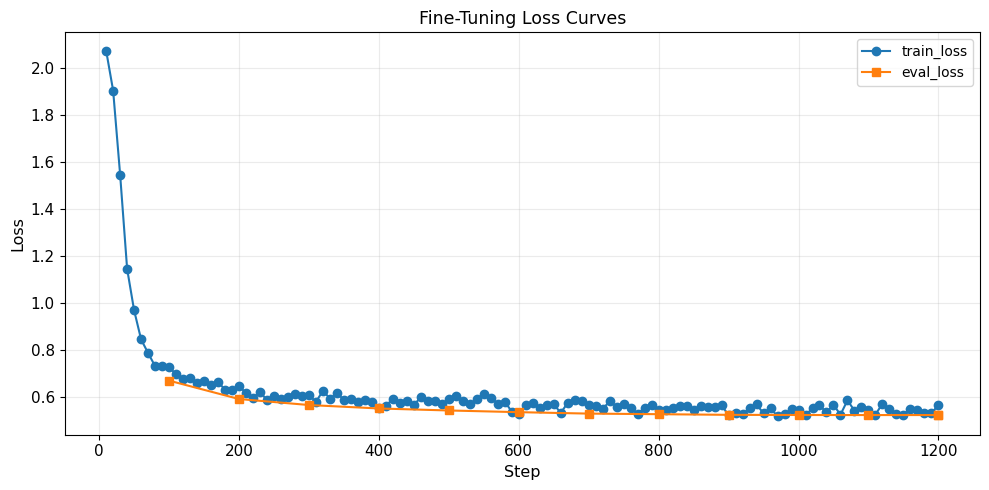

Saved training log : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_training_log_05.csv
Saved loss curve   : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_loss_curve_05.png


Official validation inference:   0%|          | 0/5613 [00:00<?, ?it/s]

Saved official validation predictions: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\model_predictions_for_eval.csv
  predicted_label probability_predicted_label reference_label  \
0         EXPIRED                     EXPIRED        SURVIVED   
1         EXPIRED                     EXPIRED        SURVIVED   
2        SURVIVED                    SURVIVED        SURVIVED   
3        SURVIVED                    SURVIVED        SURVIVED   
4        SURVIVED                    SURVIVED        SURVIVED   

   expired_probability  
0             0.524180  
1             0.557015  
2             0.344315  
3             0.424985  
4             0.309257  


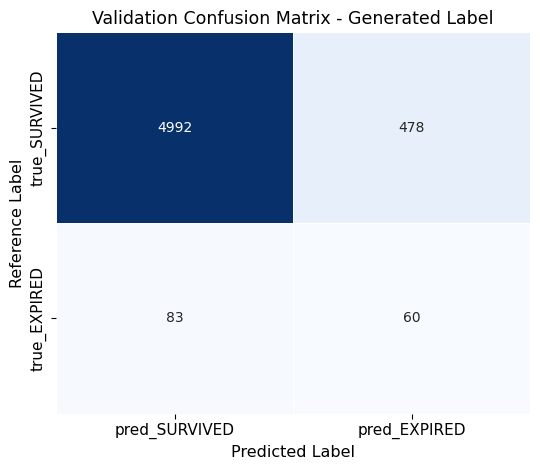

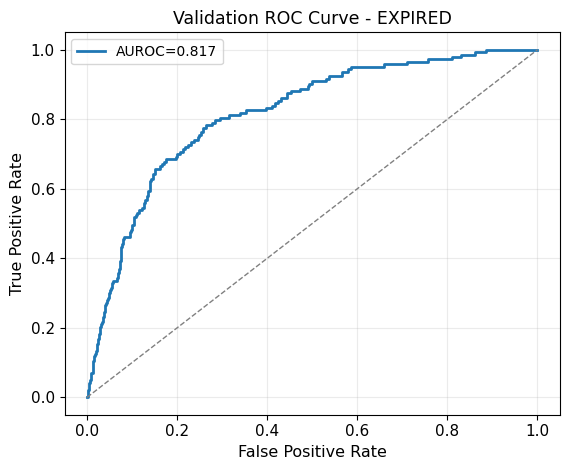

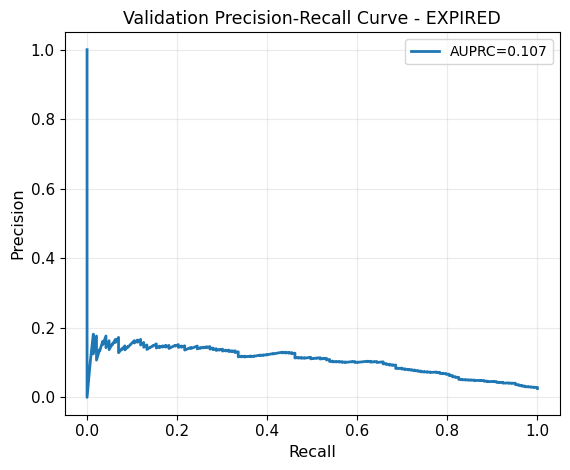

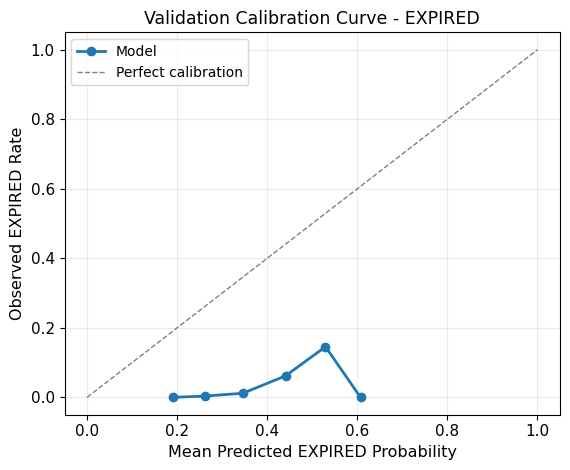


Best threshold by EXPIRED F1:


,threshold,precision_EXPIRED,recall_EXPIRED,f1_EXPIRED,balanced_accuracy,accuracy
0,0.46,0.12831,0.440559,0.198738,0.681157,0.909496



Top threshold candidates:


,threshold,precision_EXPIRED,recall_EXPIRED,f1_EXPIRED,balanced_accuracy,accuracy
45,0.46,0.128310,0.440559,0.198738,0.681157,0.909496
48,0.49,0.142857,0.272727,0.187500,0.614974,0.939783
47,0.48,0.132353,0.314685,0.186335,0.630377,0.929984
44,0.45,0.111601,0.531469,0.184466,0.710433,0.880278
42,0.43,0.102063,0.657343,0.176692,0.753077,0.843934
46,0.47,0.118812,0.335664,0.175503,0.635291,0.919651
49,0.50,0.143519,0.216783,0.172702,0.591481,0.947087
43,0.44,0.101504,0.566434,0.172157,0.717677,0.861215
41,0.42,0.089661,0.685315,0.158576,0.751707,0.814716
50,0.51,0.145570,0.160839,0.152824,0.568080,0.954570


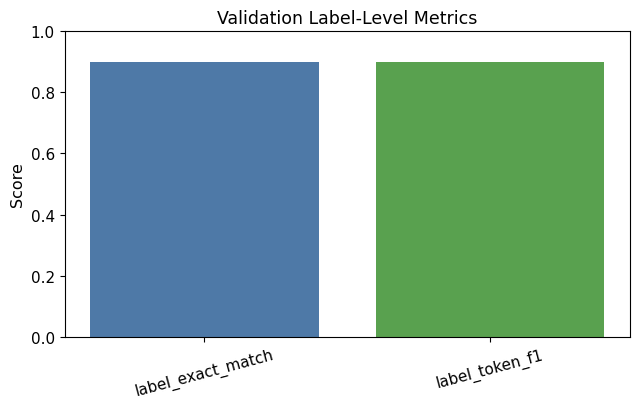

Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_eval_metrics_05.json
Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_probability_metrics_05.json


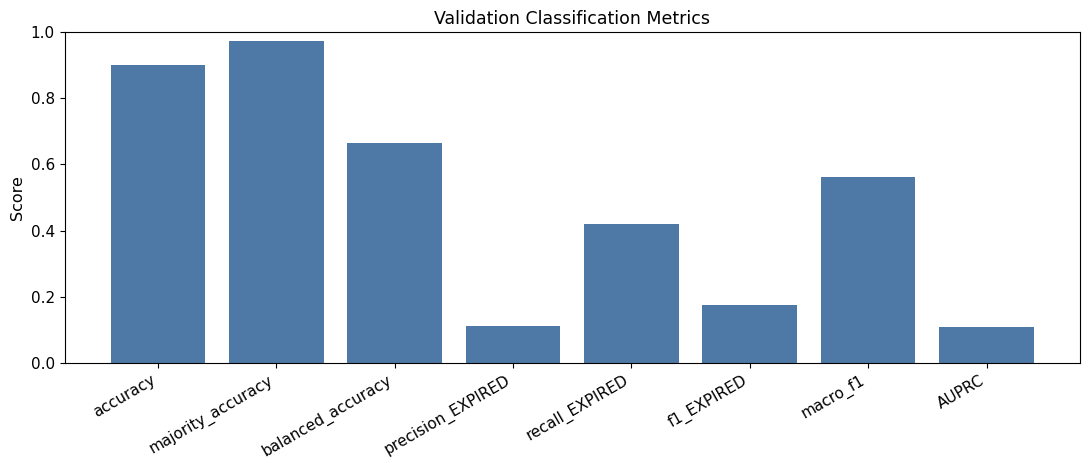


Official validation evaluation completed.
Saved predictions              : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\model_predictions_for_eval.csv
Saved metrics JSON             : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_eval_metrics_05.json
Saved probability metrics JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_probability_metrics_05.json
Saved classification report    : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_classification_report_05.csv
Saved confusion matrix CSV     : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_confusion_matrix_05.csv
Saved confusion matrix plot    : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_confusion_matrix_05

,task_variant,training_response_mode,model_id,validation_path,prediction_file,rows_total,rows_valid_reference,rows_valid_generated_classification,invalid_prediction_count,invalid_reference_count,...,weighted_f1,majority_baseline,AUROC,AUPRC,Brier_score,best_threshold_EXPIRED,best_threshold_metrics,label_exact_match,label_token_f1,accuracy_warning
0,retrospective,classification_only,BioMistral/BioMistral-7B,C:\Users\927997\OneDrive - hull.ac.uk\Explaina...,C:\Users\927997\OneDrive - hull.ac.uk\Explaina...,5613,5613,5613,0,0,...,0.927167,"{'majority_label': 'SURVIVED', 'majority_accur...",0.817258,0.106723,0.13189,0.46,"{'threshold': 0.46, 'precision_EXPIRED': 0.128...",0.900053,0.900053,Accuracy is not reliable as the primary metric...


,pred_SURVIVED,pred_EXPIRED
true_SURVIVED,4992,478
true_EXPIRED,83,60


In [14]:
# Step 8: Validation Evaluation on Notebook 04 Validation Split

with audit_step("step_08_official_validation_eval") as _s:
    print("Running official validation evaluation on Notebook 04 validation split...")

    if "model" not in globals() or "tokenizer" not in globals():
        raise RuntimeError("Model/tokenizer not available. Run Steps 3-7 first.")

    if "val_dataset_raw" not in globals() or len(val_dataset_raw) == 0:
        raise RuntimeError("val_dataset_raw is missing or empty. Run Step 2 first.")

    if "formatted_val_dataset" not in globals() or len(formatted_val_dataset) == 0:
        raise RuntimeError("formatted_val_dataset is missing or empty. Run Step 4 first.")

    from sklearn.metrics import (
        accuracy_score,
        balanced_accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
        classification_report,
        roc_auc_score,
        average_precision_score,
        brier_score_loss,
        roc_curve,
        precision_recall_curve,
    )

    model.eval()

    EVAL_MAX_ROWS = globals().get("EVAL_MAX_ROWS", None)
    val_eval_size = len(val_dataset_raw) if EVAL_MAX_ROWS is None else min(int(EVAL_MAX_ROWS), len(val_dataset_raw))
    val_indices = list(range(val_eval_size))

    label_order = [NEGATIVE_LABEL, POSITIVE_LABEL]
    max_length_for_eval = int(globals().get("MAX_LENGTH", 512))

    print(f"Validation rows to evaluate: {val_eval_size:,}")
    print(f"Validation source file      : {VAL_PATH}")

    # ---------------------------------------------------------------------
    # 8.1 Trainer eval_loss and training-log export
    # ---------------------------------------------------------------------

    trainer_eval_metrics = {}
    training_log_path = None
    loss_curve_path = None

    if "trainer" in globals() and trainer is not None:
        print("Computing Trainer evaluation metrics on formatted validation split...")
        trainer_eval_metrics = trainer.evaluate()
        trainer_eval_metrics = {
            k: float(v) if isinstance(v, (int, float, np.integer, np.floating)) else v
            for k, v in trainer_eval_metrics.items()
        }
        print(f"Trainer eval metrics: {trainer_eval_metrics}")

        if hasattr(trainer, "state") and hasattr(trainer.state, "log_history"):
            training_log_df = pd.DataFrame(trainer.state.log_history)

            training_log_path = QUALITY_DIR / "finetune_training_log_05.csv"
            training_log_df.to_csv(training_log_path, index=False)

            loss_curve_path = QUALITY_DIR / "finetune_loss_curve_05.png"

            plt.figure(figsize=(10, 5))

            if "step" in training_log_df.columns and "loss" in training_log_df.columns:
                train_loss_df = training_log_df.dropna(subset=["loss"])
                if len(train_loss_df) > 0:
                    plt.plot(train_loss_df["step"], train_loss_df["loss"], marker="o", linewidth=1.5, label="train_loss")

            if "step" in training_log_df.columns and "eval_loss" in training_log_df.columns:
                eval_loss_df = training_log_df.dropna(subset=["eval_loss"])
                if len(eval_loss_df) > 0:
                    plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], marker="s", linewidth=1.5, label="eval_loss")

            plt.title("Fine-Tuning Loss Curves")
            plt.xlabel("Step")
            plt.ylabel("Loss")
            plt.grid(alpha=0.25)
            plt.legend()
            plt.tight_layout()
            plt.savefig(loss_curve_path, dpi=220, bbox_inches="tight")
            plt.show()
            plt.close()

            print(f"Saved training log : {training_log_path}")
            print(f"Saved loss curve   : {loss_curve_path}")
    else:
        print("Trainer not found. Skipping trainer.evaluate() and training-log export.")

    # ---------------------------------------------------------------------
    # 8.2 Official validation inference
    # ---------------------------------------------------------------------

    def build_eval_prompt(input_text: str) -> tuple:
        """
        Build classification-only inference prompt and truncate input if needed.
        Reserve enough room for a short label continuation.
        """
        input_text = str(input_text).strip()
        instruction = mortality_classification_instruction()

        prefix = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n"
        )
        suffix = "\n\n### Response:\n"

        reserve_label = f"{POSITIVE_LABEL}{tokenizer.eos_token}"

        prefix_ids = tokenizer(prefix, add_special_tokens=False).input_ids
        input_ids = tokenizer(input_text, add_special_tokens=False).input_ids
        suffix_ids = tokenizer(suffix + reserve_label, add_special_tokens=False).input_ids

        input_budget = max(max_length_for_eval - len(prefix_ids) - len(suffix_ids), 0)
        was_truncated = len(input_ids) > input_budget

        if was_truncated:
            input_ids = input_ids[:input_budget]
            input_text = tokenizer.decode(input_ids, skip_special_tokens=True).strip()

        return prefix + input_text + suffix, was_truncated

    records = []

    for row_id in tqdm(val_indices, desc="Official validation inference"):
        row = val_dataset_raw[row_id]

        input_text = str(row.get(FIELD_INPUT, "")).strip()
        reference_text = str(row.get(FIELD_OUTPUT, "")).strip()
        reference_label = extract_label(reference_text)

        prompt, input_was_truncated = build_eval_prompt(input_text)

        prediction_text = run_inference(
            prompt,
            outcome_marker=None,
            max_new_tokens=8,
            do_sample=False,
        )
        predicted_label = postprocess_generation_to_label(prediction_text)

        prob_payload = label_probabilities(prompt, normalize_by_tokens=True)
        probability_predicted_label = prob_payload["predicted_label_by_probability"]

        records.append(
            {
                "row_id": int(row_id),
                "task_variant": TASK_VARIANT,
                "model_name": model_id,
                "prediction": prediction_text,
                "reference": reference_text,
                "ground_truth": reference_text,
                "predicted_label": predicted_label,
                "probability_predicted_label": probability_predicted_label,
                "reference_label": reference_label,
                "prediction_text": prediction_text,
                "reference_text": reference_text,
                "input_was_truncated": bool(input_was_truncated),
                "expired_log_likelihood": prob_payload["expired_log_likelihood"],
                "survived_log_likelihood": prob_payload["survived_log_likelihood"],
                "expired_mean_log_likelihood": prob_payload["expired_mean_log_likelihood"],
                "survived_mean_log_likelihood": prob_payload["survived_mean_log_likelihood"],
                "expired_probability": prob_payload["expired_probability"],
                "survived_probability": prob_payload["survived_probability"],
                "score_normalized_by_tokens": prob_payload["score_normalized_by_tokens"],
            }
        )

    df_predictions = pd.DataFrame(records)

    predictions_path = OUTPUTS_DIR / "model_predictions_for_eval.csv"
    df_predictions.to_csv(predictions_path, index=False)

    print(f"Saved official validation predictions: {predictions_path}")
    print(df_predictions[["predicted_label", "probability_predicted_label", "reference_label", "expired_probability"]].head())

    # ---------------------------------------------------------------------
    # 8.3 Generated-label classification metrics
    # ---------------------------------------------------------------------

    invalid_pred_count = int((df_predictions["predicted_label"] == "INVALID").sum())
    invalid_ref_count = int((df_predictions["reference_label"] == "INVALID").sum())

    valid_generated_df = df_predictions[
        df_predictions["reference_label"].isin(VALID_LABELS)
        & df_predictions["predicted_label"].isin(VALID_LABELS)
    ].copy()

    valid_reference_df = df_predictions[
        df_predictions["reference_label"].isin(VALID_LABELS)
    ].copy()

    if len(valid_reference_df) == 0:
        raise RuntimeError("No valid validation references available for metric computation.")

    if len(valid_generated_df) == 0:
        print("Warning: no valid generated labels. Generated-label metrics will be set to zero.")
        y_true_generated = []
        y_pred_generated = []
    else:
        y_true_generated = valid_generated_df["reference_label"].tolist()
        y_pred_generated = valid_generated_df["predicted_label"].tolist()

    majority_pred = [NEGATIVE_LABEL] * len(valid_reference_df)
    y_true_all = valid_reference_df["reference_label"].tolist()

    majority_metrics = {
        "majority_label": NEGATIVE_LABEL,
        "majority_accuracy": round(float(accuracy_score(y_true_all, majority_pred)), 6),
        "majority_balanced_accuracy": round(float(balanced_accuracy_score(y_true_all, majority_pred)), 6),
        "majority_macro_f1": round(float(f1_score(y_true_all, majority_pred, average="macro", zero_division=0)), 6),
        "majority_recall_EXPIRED": round(float(recall_score(y_true_all, majority_pred, pos_label=POSITIVE_LABEL, zero_division=0)), 6),
        "majority_f1_EXPIRED": round(float(f1_score(y_true_all, majority_pred, pos_label=POSITIVE_LABEL, zero_division=0)), 6),
    }

    if len(valid_generated_df) > 0:
        accuracy = accuracy_score(y_true_generated, y_pred_generated)
        balanced_accuracy = balanced_accuracy_score(y_true_generated, y_pred_generated)
        precision_expired = precision_score(y_true_generated, y_pred_generated, pos_label=POSITIVE_LABEL, zero_division=0)
        recall_expired = recall_score(y_true_generated, y_pred_generated, pos_label=POSITIVE_LABEL, zero_division=0)
        f1_expired = f1_score(y_true_generated, y_pred_generated, pos_label=POSITIVE_LABEL, zero_division=0)
        macro_f1 = f1_score(y_true_generated, y_pred_generated, average="macro", zero_division=0)
        weighted_f1 = f1_score(y_true_generated, y_pred_generated, average="weighted", zero_division=0)
        cm = confusion_matrix(y_true_generated, y_pred_generated, labels=label_order)
    else:
        accuracy = balanced_accuracy = precision_expired = recall_expired = f1_expired = macro_f1 = weighted_f1 = 0.0
        cm = np.zeros((2, 2), dtype=int)

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{x}" for x in label_order],
        columns=[f"pred_{x}" for x in label_order],
    )

    class_report_dict = classification_report(
        y_true_generated,
        y_pred_generated,
        labels=label_order,
        output_dict=True,
        zero_division=0,
    ) if len(valid_generated_df) > 0 else {}

    class_report_df = pd.DataFrame(class_report_dict).transpose() if class_report_dict else pd.DataFrame()

    classification_report_path = QUALITY_DIR / "finetune_classification_report_05.csv"
    confusion_matrix_csv_path = QUALITY_DIR / "finetune_confusion_matrix_05.csv"
    confusion_matrix_png_path = QUALITY_DIR / "finetune_confusion_matrix_05.png"

    class_report_df.to_csv(classification_report_path)
    cm_df.to_csv(confusion_matrix_csv_path)

    plt.figure(figsize=(5.5, 4.8))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=0.5)
    plt.title("Validation Confusion Matrix - Generated Label")
    plt.ylabel("Reference Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(confusion_matrix_png_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------------------------
    # 8.4 Probability metrics and threshold tuning
    # ---------------------------------------------------------------------

    y_true_expired = valid_reference_df["reference_label"].map(
        {NEGATIVE_LABEL: 0, POSITIVE_LABEL: 1}
    ).astype(int)

    y_score_expired = valid_reference_df["expired_probability"].astype(float)

    probability_metrics = {
        "auroc": None,
        "auprc": None,
        "brier_score": None,
        "probability_metrics_available": False,
        "reason": None,
    }

    threshold_df = pd.DataFrame()
    best_threshold = float(globals().get("DEFAULT_EXPIRED_THRESHOLD", 0.5))
    best_threshold_metrics = {}

    roc_curve_path = QUALITY_DIR / "finetune_roc_curve_05.png"
    pr_curve_path = QUALITY_DIR / "finetune_pr_curve_05.png"
    calibration_csv_path = QUALITY_DIR / "finetune_calibration_curve_05.csv"
    calibration_curve_path = QUALITY_DIR / "finetune_calibration_curve_05.png"
    threshold_tuning_path = QUALITY_DIR / "threshold_tuning_expired_05.csv"

    if y_true_expired.nunique() < 2:
        probability_metrics["reason"] = (
            "AUROC/AUPRC unavailable because validation labels contain only one class."
        )
        print(probability_metrics["reason"])

    else:
        auroc = roc_auc_score(y_true_expired, y_score_expired)
        auprc = average_precision_score(y_true_expired, y_score_expired)
        brier = brier_score_loss(y_true_expired, y_score_expired)

        probability_metrics.update(
            {
                "auroc": round(float(auroc), 6),
                "auprc": round(float(auprc), 6),
                "brier_score": round(float(brier), 6),
                "probability_metrics_available": True,
                "reason": None,
            }
        )

        threshold_rows = []
        for threshold in np.linspace(0.01, 0.99, 99):
            y_pred_threshold = (y_score_expired.to_numpy() >= threshold).astype(int)

            threshold_rows.append(
                {
                    "threshold": round(float(threshold), 4),
                    "precision_EXPIRED": precision_score(y_true_expired, y_pred_threshold, zero_division=0),
                    "recall_EXPIRED": recall_score(y_true_expired, y_pred_threshold, zero_division=0),
                    "f1_EXPIRED": f1_score(y_true_expired, y_pred_threshold, zero_division=0),
                    "balanced_accuracy": balanced_accuracy_score(y_true_expired, y_pred_threshold),
                    "accuracy": accuracy_score(y_true_expired, y_pred_threshold),
                }
            )

        threshold_df = pd.DataFrame(threshold_rows)

        best_threshold_row = threshold_df.sort_values(
            ["f1_EXPIRED", "balanced_accuracy", "recall_EXPIRED"],
            ascending=False,
        ).iloc[0]

        best_threshold = float(best_threshold_row["threshold"])
        best_threshold_metrics = {
            k: float(v) for k, v in best_threshold_row.to_dict().items()
        }

        threshold_df.to_csv(threshold_tuning_path, index=False)

        valid_reference_df["threshold_predicted_label"] = np.where(
            valid_reference_df["expired_probability"].astype(float) >= best_threshold,
            POSITIVE_LABEL,
            NEGATIVE_LABEL,
        )

        threshold_cm = confusion_matrix(
            valid_reference_df["reference_label"],
            valid_reference_df["threshold_predicted_label"],
            labels=label_order,
        )
        threshold_cm_df = pd.DataFrame(
            threshold_cm,
            index=[f"true_{x}" for x in label_order],
            columns=[f"pred_{x}" for x in label_order],
        )

        threshold_cm_path = QUALITY_DIR / "finetune_threshold_confusion_matrix_05.csv"
        threshold_cm_df.to_csv(threshold_cm_path)

        fpr, tpr, _ = roc_curve(y_true_expired, y_score_expired)
        precision_curve, recall_curve, _ = precision_recall_curve(y_true_expired, y_score_expired)

        plt.figure(figsize=(5.8, 4.8))
        plt.plot(fpr, tpr, linewidth=2, label=f"AUROC={auroc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Validation ROC Curve - EXPIRED")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(roc_curve_path, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close()

        plt.figure(figsize=(5.8, 4.8))
        plt.plot(recall_curve, precision_curve, linewidth=2, label=f"AUPRC={auprc:.3f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Validation Precision-Recall Curve - EXPIRED")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(pr_curve_path, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close()

        calibration_df = pd.DataFrame(
            {
                "y_true_expired": y_true_expired.values,
                "expired_probability": y_score_expired.values,
            }
        )
        calibration_df["prob_bin"] = pd.cut(
            calibration_df["expired_probability"],
            bins=np.linspace(0, 1, 11),
            include_lowest=True,
        )
        calibration_summary = (
            calibration_df.groupby("prob_bin", observed=False)
            .agg(
                mean_predicted_probability=("expired_probability", "mean"),
                observed_expired_rate=("y_true_expired", "mean"),
                rows=("y_true_expired", "size"),
            )
            .dropna()
            .reset_index()
        )
        calibration_summary.to_csv(calibration_csv_path, index=False)

        plt.figure(figsize=(5.8, 4.8))
        plt.plot(
            calibration_summary["mean_predicted_probability"],
            calibration_summary["observed_expired_rate"],
            marker="o",
            linewidth=2,
            label="Model",
        )
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Perfect calibration")
        plt.xlabel("Mean Predicted EXPIRED Probability")
        plt.ylabel("Observed EXPIRED Rate")
        plt.title("Validation Calibration Curve - EXPIRED")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(calibration_curve_path, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close()

        print("\nBest threshold by EXPIRED F1:")
        display(pd.DataFrame([best_threshold_metrics]))
        print("\nTop threshold candidates:")
        display(threshold_df.sort_values(["f1_EXPIRED", "balanced_accuracy"], ascending=False).head(15))

    # ---------------------------------------------------------------------
    # 8.5 Label-level text metrics
    # ---------------------------------------------------------------------

    df_predictions["reference_label_text"] = df_predictions["reference_label"]
    df_predictions["predicted_label_text"] = df_predictions["predicted_label"]

    df_predictions["label_exact_match"] = (
        df_predictions["predicted_label_text"] == df_predictions["reference_label_text"]
    ).astype(float)

    df_predictions["label_token_f1"] = df_predictions.apply(
        lambda r: text_token_f1(r["predicted_label_text"], r["reference_label_text"]),
        axis=1,
    )

    df_predictions.to_csv(predictions_path, index=False)

    textgen_board = pd.DataFrame(
        [
            {
                "model": model_id,
                "rows": int(len(df_predictions)),
                "label_exact_match": round(float(df_predictions["label_exact_match"].mean()), 6),
                "label_token_f1": round(float(df_predictions["label_token_f1"].mean()), 6),
            }
        ]
    )

    textgen_board_path = QUALITY_DIR / "finetune_label_metric_board.csv"
    textgen_board_fig_path = QUALITY_DIR / "finetune_label_metric_board.png"

    textgen_board.to_csv(textgen_board_path, index=False)

    plt.figure(figsize=(6.5, 4.2))
    text_metric_names = ["label_exact_match", "label_token_f1"]
    text_metric_values = [float(textgen_board.loc[0, m]) for m in text_metric_names]
    plt.bar(text_metric_names, text_metric_values, color=["#4E79A7", "#59A14F"])
    plt.ylim(0, 1)
    plt.title("Validation Label-Level Metrics")
    plt.ylabel("Score")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(textgen_board_fig_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------------------------
    # 8.6 Consolidated metrics export
    # ---------------------------------------------------------------------

    eval_metrics = {
        "task_variant": TASK_VARIANT,
        "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
        "model_id": model_id,
        "validation_path": str(VAL_PATH),
        "prediction_file": str(predictions_path),
        "rows_total": int(len(df_predictions)),
        "rows_valid_reference": int(len(valid_reference_df)),
        "rows_valid_generated_classification": int(len(valid_generated_df)),
        "invalid_prediction_count": invalid_pred_count,
        "invalid_reference_count": invalid_ref_count,

        "train_loss": None,
        "eval_loss": trainer_eval_metrics.get("eval_loss"),

        "accuracy": round(float(accuracy), 6),
        "balanced_accuracy": round(float(balanced_accuracy), 6),
        "precision_EXPIRED": round(float(precision_expired), 6),
        "recall_EXPIRED": round(float(recall_expired), 6),
        "f1_EXPIRED": round(float(f1_expired), 6),
        "macro_f1": round(float(macro_f1), 6),
        "weighted_f1": round(float(weighted_f1), 6),

        "majority_baseline": majority_metrics,

        "AUROC": probability_metrics["auroc"],
        "AUPRC": probability_metrics["auprc"],
        "Brier_score": probability_metrics["brier_score"],

        "best_threshold_EXPIRED": round(float(best_threshold), 6),
        "best_threshold_metrics": best_threshold_metrics,

        "label_exact_match": round(float(df_predictions["label_exact_match"].mean()), 6),
        "label_token_f1": round(float(df_predictions["label_token_f1"].mean()), 6),

        "accuracy_warning": (
            "Accuracy is not reliable as the primary metric under severe class imbalance. "
            "Use EXPIRED recall/F1, macro F1, balanced accuracy, AUPRC, and threshold analysis."
        ),
    }

    if "trainer" in globals() and trainer is not None and hasattr(trainer, "state"):
        log_history_df = pd.DataFrame(trainer.state.log_history)
        if "loss" in log_history_df.columns:
            train_losses = log_history_df["loss"].dropna()
            if len(train_losses) > 0:
                eval_metrics["train_loss"] = round(float(train_losses.iloc[-1]), 6)

    metrics_json_path = QUALITY_DIR / "finetune_eval_metrics_05.json"
    probability_metrics_json_path = QUALITY_DIR / "finetune_probability_metrics_05.json"
    metric_barplot_path = QUALITY_DIR / "finetune_metric_barplot_05.png"

    save_json(eval_metrics, metrics_json_path)
    save_json(probability_metrics, probability_metrics_json_path)

    metric_bar_df = pd.DataFrame(
        [
            {"metric": "accuracy", "value": eval_metrics["accuracy"]},
            {"metric": "majority_accuracy", "value": majority_metrics["majority_accuracy"]},
            {"metric": "balanced_accuracy", "value": eval_metrics["balanced_accuracy"]},
            {"metric": "precision_EXPIRED", "value": eval_metrics["precision_EXPIRED"]},
            {"metric": "recall_EXPIRED", "value": eval_metrics["recall_EXPIRED"]},
            {"metric": "f1_EXPIRED", "value": eval_metrics["f1_EXPIRED"]},
            {"metric": "macro_f1", "value": eval_metrics["macro_f1"]},
            {"metric": "AUPRC", "value": eval_metrics["AUPRC"] if eval_metrics["AUPRC"] is not None else 0.0},
        ]
    )

    plt.figure(figsize=(11, 4.8))
    plt.bar(metric_bar_df["metric"], metric_bar_df["value"], color="#4E79A7")
    plt.ylim(0, 1)
    plt.title("Validation Classification Metrics")
    plt.ylabel("Score")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(metric_barplot_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    print("\nOfficial validation evaluation completed.")
    print(f"Saved predictions              : {predictions_path}")
    print(f"Saved metrics JSON             : {metrics_json_path}")
    print(f"Saved probability metrics JSON : {probability_metrics_json_path}")
    print(f"Saved classification report    : {classification_report_path}")
    print(f"Saved confusion matrix CSV     : {confusion_matrix_csv_path}")
    print(f"Saved confusion matrix plot    : {confusion_matrix_png_path}")
    print(f"Saved threshold tuning CSV     : {threshold_tuning_path}")
    print(f"Saved metric barplot           : {metric_barplot_path}")
    print(f"Saved label metric board       : {textgen_board_path}")
    print(f"Saved label metric plot        : {textgen_board_fig_path}")

    display(pd.DataFrame([eval_metrics]))
    display(cm_df)

    finetuning_audit["eval_metrics"] = eval_metrics
    finetuning_audit["probability_metrics"] = probability_metrics
    finetuning_audit["majority_baseline"] = majority_metrics
    finetuning_audit["best_threshold_EXPIRED"] = eval_metrics["best_threshold_EXPIRED"]
    finetuning_audit["best_threshold_metrics"] = best_threshold_metrics

    _s["task_variant"] = TASK_VARIANT
    _s["validation_path"] = str(VAL_PATH)
    _s["rows_total"] = int(len(df_predictions))
    _s["rows_valid_reference"] = int(len(valid_reference_df))
    _s["rows_valid_generated_classification"] = int(len(valid_generated_df))
    _s["metrics_json"] = str(metrics_json_path)
    _s["predictions_csv"] = str(predictions_path)
    _s["accuracy"] = eval_metrics["accuracy"]
    _s["majority_accuracy"] = majority_metrics["majority_accuracy"]
    _s["balanced_accuracy"] = eval_metrics["balanced_accuracy"]
    _s["recall_EXPIRED"] = eval_metrics["recall_EXPIRED"]
    _s["f1_EXPIRED"] = eval_metrics["f1_EXPIRED"]
    _s["AUROC"] = eval_metrics["AUROC"]
    _s["AUPRC"] = eval_metrics["AUPRC"]
    _s["Brier_score"] = eval_metrics["Brier_score"]
    _s["best_threshold_EXPIRED"] = eval_metrics["best_threshold_EXPIRED"]


**Step 9: Llama3-Med Style Training-Readiness Diagnostics**

This audit-first step prepares Llama3-Med style readiness artifacts without launching additional training. It formats instruction examples into a chat-style template, summarizes split quality, and generates a compact training dashboard.

**Main Operations**  
◽ Reuse official train and validation splits from Notebook 04  
◽ Render Llama3-style chat-format preview examples  
◽ Check required instruction fields and response availability  
◽ Summarize prompt length, label distribution, and split composition  
◽ Generate readiness plots and dashboard tables  
◽ Export readiness payloads for future chat-style fine-tuning  

**Technical and Clinical Significance**  
This step checks whether the instruction dataset is ready for chat-template-based medical LLM training. It separates readiness validation from heavy model execution, making the dataset easier to inspect before future Llama3-Med style experiments.

**Expected Outcome**  
Llama3-Med readiness previews, profile tables, plots, and payload files are saved.

Preparing training-readiness diagnostics from official Notebook 04 splits...
Official train rows       : 44,910
Validation rows           : 5,613
SFT training rows used    : 58,382
Task variant              : retrospective
Training response mode    : classification_only
Train source              : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset_retrospective_04_train.jsonl
Val source                : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset_retrospective_04_val.jsonl

--- Llama-3 Style Classification Preview (diagnostic only) ---
<|start_header_id|>system<|end_header_id|>

You are a careful medical assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>

Predict the hospital mortality outcome using only the available emergency department presentation data. Return exactly one label: SURVIVED or EXPIRED.

Chief Complaint: Hyperglycemia
Triage Vitals - Temperat

,parameter,value
0,task_variant,retrospective
1,training_response_mode,classification_only
2,seed,42
3,model_id,BioMistral/BioMistral-7B
4,train_path,C:\Users\927997\OneDrive - hull.ac.uk\Explaina...
5,val_path,C:\Users\927997\OneDrive - hull.ac.uk\Explaina...
6,balance_training_data,True
7,expired_oversampling_ratio,0.33
8,official_train_rows,44910
9,sft_training_rows_used,58382


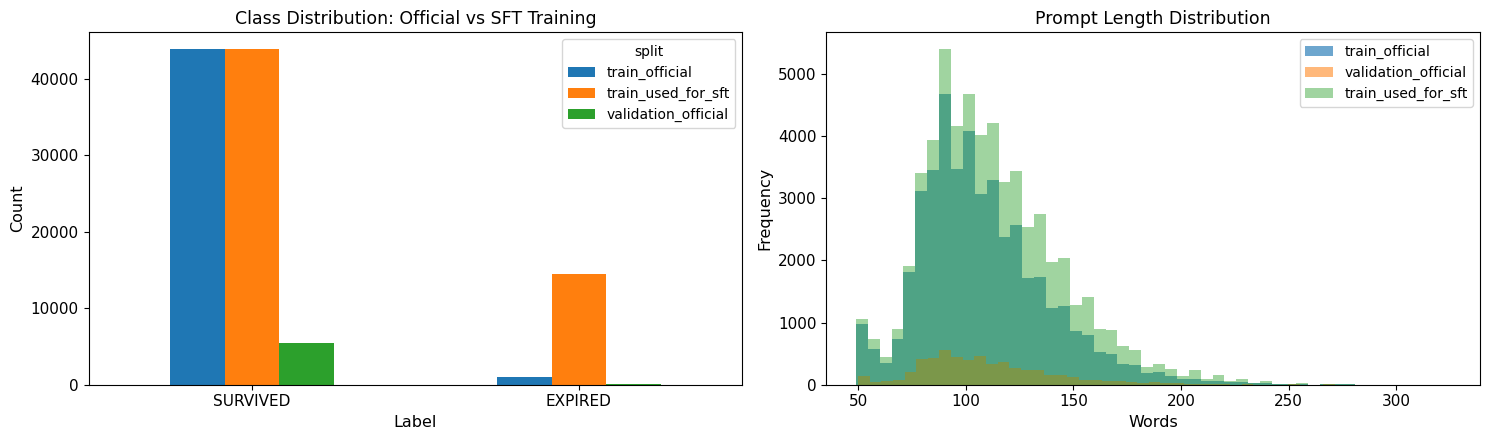

Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_llama3_preview.json
Saved profile CSV          : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_prompt_profile.csv
Saved training plan CSV    : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_training_plan.csv
Saved dashboard figure     : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_readiness_dashboard.png
Saved template preview JSON: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetune_llama3_preview.json


In [15]:
# Step 9: Llama3-Med Style Training-Readiness Diagnostics

with audit_step("step_09_readiness") as _s:
    assert "QUALITY_DIR" in globals() and "OUTPUTS_DIR" in globals(), \
        "Run Environment Setup cell first"

    print("Preparing training-readiness diagnostics from official Notebook 04 splits...")

    if "train_dataset_raw" not in globals() or len(train_dataset_raw) == 0:
        raise RuntimeError("train_dataset_raw is not available. Run Step 2 first.")
    if "val_dataset_raw" not in globals() or len(val_dataset_raw) == 0:
        raise RuntimeError("val_dataset_raw is not available. Run Step 2 first.")

    df_train_split = train_dataset_raw.to_pandas().copy()
    df_val_split = val_dataset_raw.to_pandas().copy()

    if len(df_train_split) == 0:
        raise RuntimeError("Training split is empty.")
    if len(df_val_split) == 0:
        raise RuntimeError("Validation split is empty.")

    df_train_split["split"] = "train_official"
    df_val_split["split"] = "validation_official"

    if "train_dataset_for_training" in globals() and len(train_dataset_for_training) > 0:
        df_training_used = train_dataset_for_training.to_pandas().copy()
        df_training_used["split"] = "train_used_for_sft"
    else:
        df_training_used = df_train_split.copy()
        df_training_used["split"] = "train_used_for_sft"

    df_full = pd.concat(
        [df_train_split, df_val_split, df_training_used],
        ignore_index=True,
    )

    for df_part in (df_train_split, df_val_split, df_training_used, df_full):
        for c in [FIELD_INSTRUCTION, FIELD_INPUT, FIELD_OUTPUT]:
            if c not in df_part.columns:
                df_part[c] = ""
            df_part[c] = df_part[c].fillna("").astype(str)

        if FIELD_LABEL not in df_part.columns:
            df_part[FIELD_LABEL] = df_part[FIELD_OUTPUT].map(extract_label)

        df_part[FIELD_LABEL] = df_part[FIELD_LABEL].fillna("INVALID").astype(str).str.upper()

        df_part["prompt_words"] = (
            df_part[FIELD_INSTRUCTION] + " " + df_part[FIELD_INPUT]
        ).str.split().str.len()
        df_part["response_words"] = df_part[FIELD_OUTPUT].str.split().str.len()

    print(f"Official train rows       : {len(df_train_split):,}")
    print(f"Validation rows           : {len(df_val_split):,}")
    print(f"SFT training rows used    : {len(df_training_used):,}")
    print(f"Task variant              : {TASK_VARIANT}")
    print(f"Training response mode    : {globals().get('TRAINING_RESPONSE_MODE', 'classification_only')}")
    print(f"Train source              : {TRAIN_PATH}")
    print(f"Val source                : {VAL_PATH}")

    def llama3_chat_format(system_msg: str, user_msg: str, assistant_msg: str = "") -> str:
        return (
            "<|start_header_id|>system<|end_header_id|>\n\n"
            + system_msg
            + "<|eot_id|>"
            + "<|start_header_id|>user<|end_header_id|>\n\n"
            + user_msg
            + "<|eot_id|>"
            + "<|start_header_id|>assistant<|end_header_id|>\n\n"
            + assistant_msg
            + "<|eot_id|>"
        )

    preview_row = df_training_used.iloc[0]
    preview_system = "You are a careful medical assistant."
    preview_user = (
        f"{mortality_classification_instruction()}\n\n"
        f"{str(preview_row[FIELD_INPUT]).strip()}"
    )
    preview_assistant = extract_label(preview_row.get(FIELD_LABEL, preview_row.get(FIELD_OUTPUT, "")))
    preview_text = llama3_chat_format(preview_system, preview_user, preview_assistant)

    print("\n--- Llama-3 Style Classification Preview (diagnostic only) ---")
    print(preview_text[:1200])

    per_device_train_batch_size = int(globals().get("PER_DEVICE_TRAIN_BATCH_SIZE", 4))
    gradient_accumulation_steps = int(globals().get("GRADIENT_ACCUMULATION_STEPS", 4))
    max_length = int(globals().get("MAX_LENGTH", 512))
    device_count = max(1, int(torch.cuda.device_count())) if "torch" in globals() else 1

    global_batch_size = device_count * per_device_train_batch_size * gradient_accumulation_steps
    effective_batch_size = per_device_train_batch_size * gradient_accumulation_steps
    steps_per_epoch_used = int(math.ceil(len(df_training_used) / max(effective_batch_size, 1)))

    training_config_audit = finetuning_audit.get("training_config", {})
    max_train_steps = training_config_audit.get(
        "max_train_steps",
        globals().get("MAX_TRAIN_STEPS_OVERRIDE", None),
    )

    df_plan = pd.DataFrame(
        [
            {"parameter": "task_variant", "value": TASK_VARIANT},
            {"parameter": "training_response_mode", "value": globals().get("TRAINING_RESPONSE_MODE", "classification_only")},
            {"parameter": "seed", "value": SEED},
            {"parameter": "model_id", "value": model_id},
            {"parameter": "train_path", "value": str(TRAIN_PATH)},
            {"parameter": "val_path", "value": str(VAL_PATH)},
            {"parameter": "balance_training_data", "value": globals().get("BALANCE_TRAINING_DATA", None)},
            {"parameter": "expired_oversampling_ratio", "value": globals().get("EXPIRED_OVERSAMPLING_RATIO", None)},
            {"parameter": "official_train_rows", "value": int(len(df_train_split))},
            {"parameter": "sft_training_rows_used", "value": int(len(df_training_used))},
            {"parameter": "val_rows", "value": int(len(df_val_split))},
            {"parameter": "device_count", "value": device_count},
            {"parameter": "per_device_train_batch_size", "value": per_device_train_batch_size},
            {"parameter": "gradient_accumulation_steps", "value": gradient_accumulation_steps},
            {"parameter": "effective_batch_size", "value": effective_batch_size},
            {"parameter": "global_batch_size", "value": global_batch_size},
            {"parameter": "steps_per_epoch_used", "value": steps_per_epoch_used},
            {"parameter": "max_train_steps", "value": max_train_steps},
            {"parameter": "max_length", "value": max_length},
        ]
    )

    display(df_plan)

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

    label_counts = (
        df_full.groupby(["split", FIELD_LABEL], dropna=False)
        .size()
        .reset_index(name="count")
    )

    pivot_counts = (
        label_counts.pivot(index=FIELD_LABEL, columns="split", values="count")
        .fillna(0)
        .reindex(list(VALID_LABELS) + ["INVALID"])
        .dropna(how="all")
    )

    pivot_counts.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Class Distribution: Official vs SFT Training")
    axes[0].set_xlabel("Label")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=0)

    axes[1].hist(
        df_train_split["prompt_words"],
        bins=50,
        alpha=0.65,
        label="train_official",
    )
    axes[1].hist(
        df_val_split["prompt_words"],
        bins=50,
        alpha=0.55,
        label="validation_official",
    )
    axes[1].hist(
        df_training_used["prompt_words"],
        bins=50,
        alpha=0.45,
        label="train_used_for_sft",
    )
    axes[1].set_title("Prompt Length Distribution")
    axes[1].set_xlabel("Words")
    axes[1].set_ylabel("Frequency")
    axes[1].legend()

    train_profile_csv = QUALITY_DIR / "finetune_prompt_profile.csv"
    train_plan_csv = QUALITY_DIR / "finetune_training_plan.csv"
    plot_path = QUALITY_DIR / "finetune_readiness_dashboard.png"
    preview_json = QUALITY_DIR / "finetune_llama3_preview.json"

    plt.tight_layout()
    plt.savefig(plot_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    profile_cols = [
        "split",
        "prompt_words",
        "response_words",
        FIELD_LABEL,
    ]
    df_full[profile_cols].to_csv(train_profile_csv, index=False)
    df_plan.to_csv(train_plan_csv, index=False)

    readiness_payload = {
        "task_variant": TASK_VARIANT,
        "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
        "seed": int(SEED),
        "model_id": model_id,
        "train_path": str(TRAIN_PATH),
        "val_path": str(VAL_PATH),
        "official_train_rows": int(len(df_train_split)),
        "sft_training_rows_used": int(len(df_training_used)),
        "val_rows": int(len(df_val_split)),
        "effective_batch_size": int(effective_batch_size),
        "global_batch_size": int(global_batch_size),
        "steps_per_epoch_used": int(steps_per_epoch_used),
        "max_train_steps": max_train_steps,
        "balance_training_audit": finetuning_audit.get("balance_training_audit"),
        "llama3_formatted_preview": preview_text,
        "note": (
            "This is a readiness diagnostic only. The active SFT run uses "
            "classification-only Alpaca-style formatted_train_dataset and "
            "formatted_val_dataset. Validation split remains unbalanced and official."
        ),
    }

    save_json(readiness_payload, preview_json)

    finetuning_audit["readiness_diagnostics"] = readiness_payload

    print(f"Saved profile CSV          : {train_profile_csv}")
    print(f"Saved training plan CSV    : {train_plan_csv}")
    print(f"Saved dashboard figure     : {plot_path}")
    print(f"Saved template preview JSON: {preview_json}")

    _s["task_variant"] = TASK_VARIANT
    _s["training_response_mode"] = globals().get("TRAINING_RESPONSE_MODE", "classification_only")
    _s["official_train_rows"] = int(len(df_train_split))
    _s["sft_training_rows_used"] = int(len(df_training_used))
    _s["val_rows"] = int(len(df_val_split))
    _s["effective_batch_size"] = int(effective_batch_size)
    _s["global_batch_size"] = int(global_batch_size)
    _s["steps_per_epoch_used"] = int(steps_per_epoch_used)
    _s["max_train_steps"] = max_train_steps
    _s["profile_csv"] = str(train_profile_csv)
    _s["training_plan_csv"] = str(train_plan_csv)
    _s["dashboard"] = str(plot_path)
    _s["preview_json"] = str(preview_json)


**Step 10: CLIP Alignment Layer for Multimodal Fine-Tuning Readiness**

This audit-first step links instruction records with CLIP image-embedding artifacts from Notebook 03 when available. It prepares a multimodal alignment bridge between clinical instruction examples and their corresponding radiology image representations.

**Main Operations**  
◽ Locate CLIP embedding index artifacts from Notebook 03  
◽ Resolve instruction records from the current fine-tuning dataset  
◽ Match instruction rows to CLIP metadata using shared identifiers  
◽ Add image-embedding references when linkage is available  
◽ Measure CLIP coverage and missing-linkage counts  
◽ Export CLIP alignment tables, previews, and audit payloads  

**Technical and Clinical Significance**  
This step does not feed CLIP embeddings into the current LLM trainer. Instead, it documents how many instruction records are ready for future image-text alignment or multimodal fine-tuning workflows.

**Expected Outcome**  
CLIP alignment readiness files are saved, showing which instruction examples can be linked to image-embedding artifacts.

In [16]:
# Step 10: CLIP Alignment Bridge for Future Multimodal Readiness
# Audit-only. This does not feed the SFT trainer.

with audit_step("step_10_clip") as _s:
    print("Starting CLIP alignment bridge...")

    assert "QUALITY_DIR" in globals() and "OUTPUTS_DIR" in globals(), \
        "Run Environment Setup cell first"

    clip_index_candidates = [
        OUTPUTS_DIR / "clip_image_embeddings_index_03.csv",
        OUTPUTS_DIR / "clip_image_embeddings_index.csv",
    ]
    clip_summary_candidates = [
        QUALITY_DIR / "clip_embedding_run_summary_03.json",
        QUALITY_DIR / "clip_embedding_run_summary.json",
    ]

    clip_index_path = next((p for p in clip_index_candidates if p.exists()), None)
    clip_summary_path = next((p for p in clip_summary_candidates if p.exists()), None)

    _s["audit_only"] = True
    _s["used_for_sft_training"] = False
    _s["skipped"] = clip_index_path is None

    if clip_index_path is None:
        print(
            "CLIP embedding index not found. "
            "Run Notebook 03 CLIP extraction later if multimodal alignment is needed."
        )
        _s["reason"] = "CLIP embedding index not found"

    else:
        print(f"Using CLIP index: {clip_index_path}")

        if "train_dataset_raw" not in globals() or "val_dataset_raw" not in globals():
            raise RuntimeError(
                "Official train/validation datasets are not available. Run Step 2 first."
            )

        df_train = train_dataset_raw.to_pandas().copy()
        df_val = val_dataset_raw.to_pandas().copy()

        df_train["split"] = "train_official"
        df_val["split"] = "validation_official"

        df_instr = pd.concat([df_train, df_val], ignore_index=True)
        source_name = f"{TRAIN_PATH.name} + {VAL_PATH.name}"

        if len(df_instr) == 0:
            print("Instruction source is empty. CLIP alignment skipped.")
            _s["skipped"] = True
            _s["reason"] = "Instruction source empty"

        else:
            print(f"Instruction source: {source_name} (rows={len(df_instr):,})")

            df_clip = pd.read_csv(clip_index_path)

            key_priority = ["dicom_id", "study_id", "stay_id", "subject_id"]
            join_key = next(
                (k for k in key_priority if k in df_instr.columns and k in df_clip.columns),
                None,
            )

            embedding_col_candidates = [
                "clip_embedding_row",
                "embedding_row",
                "row_id",
                "embedding_index",
            ]
            embedding_col = next(
                (c for c in embedding_col_candidates if c in df_clip.columns),
                None,
            )

            if join_key is not None:
                df_instr[join_key] = df_instr[join_key].astype(str)
                df_clip[join_key] = df_clip[join_key].astype(str)

                clip_cols = []
                for c in [join_key, embedding_col, "dicom_id", "study_id", "subject_id"]:
                    if c is not None and c in df_clip.columns and c not in clip_cols:
                        clip_cols.append(c)

                df_clip_join = df_clip[clip_cols].drop_duplicates()

                if embedding_col is not None and embedding_col != "clip_embedding_row":
                    df_clip_join = df_clip_join.rename(columns={embedding_col: "clip_embedding_row"})

                df_aligned = df_instr.merge(
                    df_clip_join,
                    on=join_key,
                    how="left",
                    suffixes=("", "_clip"),
                )
                join_mode = f"key:{join_key}"

            else:
                df_aligned = df_instr.copy()
                join_mode = "no_shared_key"

            if "clip_embedding_row" not in df_aligned.columns:
                df_aligned["clip_embedding_row"] = pd.NA

            df_aligned["clip_embedding_available"] = (
                df_aligned["clip_embedding_row"].notna().astype(int)
            )
            coverage = float(df_aligned["clip_embedding_available"].mean() * 100.0)

            def _clip_ref(x):
                if pd.isna(x):
                    return "[CLIP_EMBED_REF=MISSING]"
                return f"[CLIP_EMBED_REF={str(x)}]"

            if FIELD_INPUT in df_aligned.columns:
                df_aligned["input_with_clip_ref"] = (
                    df_aligned[FIELD_INPUT].fillna("").astype(str)
                    + "\n"
                    + df_aligned["clip_embedding_row"].apply(_clip_ref)
                )

            align_summary = pd.DataFrame(
                [
                    {"metric": "task_variant", "value": TASK_VARIANT},
                    {"metric": "training_response_mode", "value": globals().get("TRAINING_RESPONSE_MODE", "classification_only")},
                    {"metric": "instruction_source", "value": source_name},
                    {"metric": "instruction_rows", "value": int(len(df_aligned))},
                    {"metric": "train_rows", "value": int((df_aligned["split"] == "train_official").sum())},
                    {"metric": "validation_rows", "value": int((df_aligned["split"] == "validation_official").sum())},
                    {"metric": "clip_index_rows", "value": int(len(df_clip))},
                    {"metric": "join_mode", "value": join_mode},
                    {"metric": "embedding_column", "value": embedding_col},
                    {
                        "metric": "rows_with_clip_embedding",
                        "value": int(df_aligned["clip_embedding_available"].sum()),
                    },
                    {
                        "metric": "clip_alignment_coverage_pct",
                        "value": round(coverage, 4),
                    },
                ]
            )

            align_csv = QUALITY_DIR / "finetune_clip_alignment_audit_05.csv"
            preview_csv = QUALITY_DIR / "finetune_clip_alignment_preview_05.csv"
            clip_ready_jsonl = OUTPUTS_DIR / "instruction_dataset_clip_ready_05.jsonl"
            payload_path = QUALITY_DIR / "finetune_clip_alignment_payload_05.json"

            align_summary.to_csv(align_csv, index=False)

            preview_cols = [
                c for c in [
                    "split",
                    FIELD_INSTRUCTION,
                    FIELD_INPUT,
                    FIELD_OUTPUT,
                    FIELD_LABEL,
                    "clip_embedding_row",
                    "clip_embedding_available",
                    "input_with_clip_ref",
                ]
                if c in df_aligned.columns
            ]
            df_aligned[preview_cols].head(3000).to_csv(preview_csv, index=False)

            export_cols = [
                c for c in [
                    "split",
                    FIELD_INSTRUCTION,
                    FIELD_INPUT,
                    "input_with_clip_ref",
                    FIELD_OUTPUT,
                    FIELD_LABEL,
                    "clip_embedding_row",
                    "clip_embedding_available",
                ]
                if c in df_aligned.columns
            ]
            df_aligned[export_cols].to_json(
                clip_ready_jsonl,
                orient="records",
                lines=True,
                force_ascii=False,
            )

            payload = {
                "task_variant": TASK_VARIANT,
                "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
                "instruction_source": source_name,
                "train_path": str(TRAIN_PATH),
                "val_path": str(VAL_PATH),
                "clip_index_path": str(clip_index_path),
                "clip_summary_path": str(clip_summary_path) if clip_summary_path else None,
                "join_mode": join_mode,
                "embedding_column": embedding_col,
                "instruction_rows": int(len(df_aligned)),
                "train_rows": int((df_aligned["split"] == "train_official").sum()),
                "validation_rows": int((df_aligned["split"] == "validation_official").sum()),
                "rows_with_clip_embedding": int(df_aligned["clip_embedding_available"].sum()),
                "coverage_pct": round(coverage, 4),
                "clip_ready_jsonl": str(clip_ready_jsonl),
                "audit_only": True,
                "used_for_sft_training": False,
            }
            save_json(payload, payload_path)

            finetuning_audit["clip_alignment_payload"] = payload

            _s["skipped"] = False
            _s["task_variant"] = TASK_VARIANT
            _s["join_mode"] = join_mode
            _s["embedding_column"] = embedding_col
            _s["coverage_pct"] = round(coverage, 4)
            _s["instruction_rows"] = int(len(df_aligned))
            _s["clip_ready_jsonl"] = str(clip_ready_jsonl)
            _s["payload_path"] = str(payload_path)

            print(f"Saved CLIP alignment audit  : {align_csv}")
            print(f"Saved CLIP alignment preview: {preview_csv}")
            print(f"Saved CLIP-ready JSONL      : {clip_ready_jsonl}")
            print(f"Saved CLIP alignment payload: {payload_path}")


Starting CLIP alignment bridge...
CLIP embedding index not found. Run Notebook 03 CLIP extraction later if multimodal alignment is needed.


**Step 11: CPLLM-Inspired Tokenizer Vocabulary Expansion Audit**

This audit-first step evaluates whether clinical terms in the instruction corpus are fragmented by the tokenizer. It identifies high-frequency medical terms, measures their tokenization behavior, and prepares optional vocabulary-expansion artifacts without modifying the trained model by default.

**Main Operations**  
◽ Mine candidate clinical terms from the instruction dataset  
◽ Check how each term is tokenized by the current tokenizer  
◽ Identify terms with high subword fragmentation  
◽ Rank candidate terms for potential vocabulary expansion  
◽ Keep tokenizer expansion disabled by default after fine-tuning  
◽ Export vocabulary audit tables and optional expansion payloads  

**Technical and Clinical Significance**  
Medical terminology can be split into many subword tokens, which may reduce efficiency and interpretability. This audit identifies vocabulary gaps while avoiding unsafe tokenizer changes after model training has already been completed.

**Expected Outcome**  
A tokenizer-fragmentation audit and CPLLM-style vocabulary-expansion readiness files are saved.

In [17]:
# Step 11: CPLLM-Inspired Vocabulary Expansion Audit
# Audit-only. Do not apply tokenizer expansion after SFT training.

with audit_step("step_11_vocab") as _s:
    print("Starting Step 11: CPLLM-inspired vocabulary expansion audit...")

    assert "QUALITY_DIR" in globals() and "OUTPUTS_DIR" in globals(), \
        "Run Environment Setup cell first"

    RUN_CPLLM_VOCAB_APPLY = False

    MIN_TERM_FREQ = 4
    MAX_CANDIDATE_TERMS = 6000
    MAX_TOKENS_TO_ADD = 3000
    MIN_TERM_CHAR_LEN = 4
    MAX_TERM_CHAR_LEN = 80

    CPLLM_SEED_TERMS = {
        "tachycardia", "hypotension", "hypoxemia", "pneumothorax", "cardiomegaly",
        "pleural effusion", "pulmonary edema", "multifocal pneumonia", "septic shock",
        "acute respiratory distress syndrome", "ards", "creatinine", "hemoglobin",
        "troponin", "lactate", "norepinephrine", "vasopressor", "mechanical ventilation",
    }

    if "tokenizer" not in globals():
        raise RuntimeError("Tokenizer not found in memory. Run tokenizer initialization first.")

    if "train_dataset_raw" not in globals() or "val_dataset_raw" not in globals():
        raise RuntimeError("Official train/validation datasets are not available. Run Step 2 first.")

    df_train = train_dataset_raw.to_pandas().copy()
    df_val = val_dataset_raw.to_pandas().copy()

    df_train["split"] = "train_official"
    df_val["split"] = "validation_official"

    df_instr = pd.concat([df_train, df_val], ignore_index=True)
    source_name = f"{TRAIN_PATH.name} + {VAL_PATH.name}"

    if len(df_instr) == 0:
        raise RuntimeError("Instruction corpus is empty. Run dataset construction steps first.")

    print(f"Instruction source: {source_name} (rows={len(df_instr):,})")

    for col in [FIELD_INSTRUCTION, FIELD_INPUT, FIELD_OUTPUT]:
        if col not in df_instr.columns:
            df_instr[col] = ""
        df_instr[col] = df_instr[col].fillna("").astype(str)

    def _normalize_space(x: str) -> str:
        return re.sub(r"\s+", " ", str(x)).strip().lower()

    word_counter = Counter()
    phrase_counter = Counter()

    split_pattern = re.compile(r"[\n\r\t,;|]+")
    word_pattern = re.compile(r"[a-z][a-z0-9\-_/\.]{2,}", flags=re.IGNORECASE)

    corpus_texts = (
        df_instr[FIELD_INSTRUCTION]
        + " "
        + df_instr[FIELD_INPUT]
        + " "
        + df_instr[FIELD_OUTPUT]
    ).tolist()

    for text in corpus_texts:
        text = _normalize_space(text)

        tokens = word_pattern.findall(text)
        for tok in tokens:
            tok = tok.strip().lower()
            if MIN_TERM_CHAR_LEN <= len(tok) <= MAX_TERM_CHAR_LEN:
                word_counter[tok] += 1

        for seg in split_pattern.split(text):
            seg = _normalize_space(seg)
            if not seg:
                continue

            word_count = len(seg.split())
            if 2 <= word_count <= 6 and MIN_TERM_CHAR_LEN <= len(seg) <= MAX_TERM_CHAR_LEN:
                if re.search(
                    r"(syndrome|failure|shock|edema|effusion|pneumonia|respiratory|renal|cardiac|chest|pain)",
                    seg,
                ):
                    phrase_counter[seg] += 1

    term_counter = Counter()
    term_counter.update(word_counter)
    term_counter.update(phrase_counter)

    for term in CPLLM_SEED_TERMS:
        term_counter[_normalize_space(term)] += max(MIN_TERM_FREQ, 5)

    candidates = [
        (term, int(freq))
        for term, freq in term_counter.items()
        if freq >= MIN_TERM_FREQ and MIN_TERM_CHAR_LEN <= len(term) <= MAX_TERM_CHAR_LEN
    ]
    candidates = sorted(candidates, key=lambda x: (-x[1], x[0]))[:MAX_CANDIDATE_TERMS]

    if len(candidates) == 0:
        raise RuntimeError("No vocabulary candidates met the filtering thresholds.")

    candidate_df = pd.DataFrame(candidates, columns=["term", "frequency"])

    vocab = tokenizer.get_vocab() if hasattr(tokenizer, "get_vocab") else {}

    candidate_df["already_in_vocab"] = candidate_df["term"].map(lambda t: int(t in vocab))
    candidate_df["token_piece_count_before"] = candidate_df["term"].map(
        lambda t: len(tokenizer.tokenize(t))
    )
    candidate_df["fragmented_before"] = candidate_df["token_piece_count_before"].map(
        lambda n: int(n > 1)
    )

    tokens_to_add = (
        candidate_df.loc[candidate_df["already_in_vocab"] == 0, "term"]
        .tolist()[:MAX_TOKENS_TO_ADD]
    )

    summary_before = {
        "task_variant": TASK_VARIANT,
        "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
        "experiment_name": globals().get("EXPERIMENT_NAME", None),
        "source": source_name,
        "train_path": str(TRAIN_PATH),
        "val_path": str(VAL_PATH),
        "rows_total": int(len(df_instr)),
        "train_rows": int((df_instr["split"] == "train_official").sum()),
        "validation_rows": int((df_instr["split"] == "validation_official").sum()),
        "candidate_terms": int(len(candidate_df)),
        "already_in_vocab": int(candidate_df["already_in_vocab"].sum()),
        "proposed_new_tokens": int(len(tokens_to_add)),
        "fragmentation_rate_before_pct": round(
            float(candidate_df["fragmented_before"].mean() * 100.0),
            4,
        ),
        "avg_token_piece_count_before": round(
            float(candidate_df["token_piece_count_before"].mean()),
            4,
        ),
        "run_apply": bool(RUN_CPLLM_VOCAB_APPLY),
        "audit_only": True,
        "used_for_sft_training": False,
        "note": (
            "Vocabulary expansion is audited only in Notebook 05. Applying new tokens "
            "after SFT would change tokenizer/model dimensions and requires a separate "
            "controlled retraining run."
        ),
    }

    candidate_csv = QUALITY_DIR / "cpllm_vocab_candidate_terms_05.csv"
    audit_csv = QUALITY_DIR / "cpllm_tokenization_fragmentation_audit_05.csv"
    plan_json = QUALITY_DIR / "cpllm_vocab_expansion_plan_05.json"

    candidate_df.to_csv(candidate_csv, index=False)
    candidate_df[
        [
            "term",
            "frequency",
            "already_in_vocab",
            "token_piece_count_before",
            "fragmented_before",
        ]
    ].to_csv(audit_csv, index=False)

    save_json(summary_before, plan_json)

    finetuning_audit["vocab_expansion_audit"] = summary_before

    print(f"Saved CPLLM candidate terms     : {candidate_csv}")
    print(f"Saved fragmentation audit       : {audit_csv}")
    print(f"Saved vocab expansion plan      : {plan_json}")
    print(f"Proposed new tokens, capped     : {len(tokens_to_add):,}")
    print("Vocabulary expansion apply-mode : OFF")

    _s["task_variant"] = TASK_VARIANT
    _s["training_response_mode"] = globals().get("TRAINING_RESPONSE_MODE", "classification_only")
    _s["candidate_terms"] = int(len(candidate_df))
    _s["proposed_new_tokens"] = int(len(tokens_to_add))
    _s["fragmentation_rate_pct"] = round(
        float(candidate_df["fragmented_before"].mean() * 100),
        4,
    )
    _s["apply_executed"] = False
    _s["audit_only"] = True
    _s["used_for_sft_training"] = False
    _s["candidate_csv"] = str(candidate_csv)
    _s["audit_csv"] = str(audit_csv)
    _s["plan_json"] = str(plan_json)


Starting Step 11: CPLLM-inspired vocabulary expansion audit...
Instruction source: instruction_dataset_retrospective_04_train.jsonl + instruction_dataset_retrospective_04_val.jsonl (rows=50,523)
Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_vocab_expansion_plan_05.json
Saved CPLLM candidate terms     : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_vocab_candidate_terms_05.csv
Saved fragmentation audit       : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_tokenization_fragmentation_audit_05.csv
Saved vocab expansion plan      : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_vocab_expansion_plan_05.json
Proposed new tokens, capped     : 3,000
Vocabulary expansion apply-mode : OFF


**Step 12: MedTVT-R1 Stage-3 SFT/GRPO Readiness Audit**

This audit-first step checks whether the instruction dataset satisfies MedTVT-R1 style training and reward-format requirements. It evaluates modality-token use, answer formatting, token-length constraints, and readiness for future SFT or GRPO-style optimization.

**Main Operations**  
◽ Inspect instruction records for modality tokens such as `<ecg>`, `<cxr>`, and `<lab>`  
◽ Check Chain-of-Evidence style output formatting  
◽ Validate `<think>` and `<answer>` response structure when present  
◽ Estimate prompt and response length budgets  
◽ Compute format-compliance and answer-set readiness indicators  
◽ Export MedTVT-R1 readiness tables and payload files  

**Technical and Clinical Significance**  
This step prepares the dataset for future multimodal reasoning optimization without running additional training. Format and modality checks help prevent invalid records from entering later SFT or GRPO pipelines.

**Expected Outcome**  
MedTVT-R1 readiness audits are saved, documenting modality coverage, format compliance, and optimization-readiness indicators.

In [18]:
# Step 12: MedTVT-R1-Inspired Stage-3 SFT/GRPO Readiness Audit
# Audit-only. No MedTVT training is launched and this does not feed Notebook 05 SFT.

with audit_step("step_12_medtvt") as _s:
    print("Starting Step 12: MedTVT-R1 stage-3 readiness audit...")

    assert "QUALITY_DIR" in globals() and "OUTPUTS_DIR" in globals(), \
        "Run Environment Setup cell first"

    MAX_WORDS_MEDTVT = 600
    MODALITY_TOKENS = ["<ecg>", "<cxr>", "<lab>"]

    FORMAT_PATTERN = re.compile(
        r"<think>.*?</think>\s*<answer>.*?</answer>",
        flags=re.IGNORECASE | re.DOTALL,
    )
    ANSWER_PATTERN = re.compile(
        r"<answer>(.*?)</answer>",
        flags=re.IGNORECASE | re.DOTALL,
    )

    def _ensure_coe_tags(text: str) -> str:
        s = str(text).strip()
        if FORMAT_PATTERN.fullmatch(s):
            return s

        s = re.sub(r"\s+", " ", s).strip()
        if not s:
            s = "Insufficient evidence provided."

        return (
            "<think>Clinical reasoning synthesized from available evidence.</think>"
            f"<answer>{s}</answer>"
        )

    def _extract_answer_labels(text: str):
        m = ANSWER_PATTERN.search(str(text))
        if not m:
            return set()

        raw = m.group(1).strip()
        labels = [x.strip() for x in raw.split(";") if x.strip()]
        return set(labels)

    def _format_reward(text: str) -> float:
        return 1.0 if FORMAT_PATTERN.fullmatch(str(text).strip()) else 0.0

    def _jaccard_reward(pred_text: str, gt_text: str) -> float:
        pred = _extract_answer_labels(pred_text)
        gt = _extract_answer_labels(gt_text)
        union = len(pred | gt)

        if union == 0:
            return 0.0

        return float(len(pred & gt) / union)

    def _token_length(s: str) -> int:
        text = str(s)

        if "tokenizer" in globals():
            try:
                if hasattr(tokenizer, "encode"):
                    ids = tokenizer.encode(text, add_special_tokens=True)
                    return len(ids)
            except Exception:
                pass

        return len(text.split())

    def _count_split_rows(df: pd.DataFrame, split_name: str) -> int:
        if "split" not in df.columns:
            return 0

        split_values = df["split"].fillna("").astype(str).str.lower()
        return int(split_values.isin([split_name, f"{split_name}_official"]).sum())

    medtvt_ready_path = OUTPUTS_DIR / "instruction_dataset_medtvt_ready_04.jsonl"

    if medtvt_ready_path.exists():
        df_instr = pd.read_json(medtvt_ready_path, lines=True)
        source_name = str(medtvt_ready_path)
        source_kind = "medtvt_ready_04"
    else:
        if "train_dataset_raw" not in globals() or "val_dataset_raw" not in globals():
            raise RuntimeError(
                "Neither MedTVT-ready artifact nor official train/validation datasets are available."
            )

        df_train = train_dataset_raw.to_pandas().copy()
        df_val = val_dataset_raw.to_pandas().copy()

        df_train["split"] = "train"
        df_val["split"] = "validation"

        df_instr = pd.concat([df_train, df_val], ignore_index=True)
        source_name = f"{TRAIN_PATH.name} + {VAL_PATH.name}"
        source_kind = "official_train_val_fallback"

    if df_instr is None or len(df_instr) == 0:
        raise RuntimeError("Instruction dataset not found for MedTVT readiness audit in Notebook 05.")

    if "messages" in df_instr.columns:
        unpacked = []

        for _, row in df_instr.iterrows():
            messages = row.get("messages", [])
            user_msg = ""
            assistant_msg = ""

            if isinstance(messages, list):
                for msg in messages:
                    if isinstance(msg, dict):
                        role = str(msg.get("role", "")).lower()
                        content = str(msg.get("content", ""))

                        if role == "user" and not user_msg:
                            user_msg = content
                        elif role == "assistant" and not assistant_msg:
                            assistant_msg = content

                if not user_msg and len(messages) >= 1:
                    user_msg = str(messages[0].get("content", messages[0])) if isinstance(messages[0], dict) else str(messages[0])

                if not assistant_msg and len(messages) >= 2:
                    assistant_msg = str(messages[1].get("content", messages[1])) if isinstance(messages[1], dict) else str(messages[1])

            unpacked.append(
                {
                    "split": str(row.get("split", "unknown")),
                    FIELD_INSTRUCTION: "",
                    FIELD_INPUT: user_msg,
                    FIELD_OUTPUT: assistant_msg,
                }
            )

        df_instr = pd.DataFrame(unpacked)

    if "split" not in df_instr.columns:
        df_instr["split"] = "unknown"

    for col in [FIELD_INSTRUCTION, FIELD_INPUT, FIELD_OUTPUT]:
        if col not in df_instr.columns:
            df_instr[col] = ""
        df_instr[col] = df_instr[col].fillna("").astype(str)

    df_audit = df_instr[["split", FIELD_INSTRUCTION, FIELD_INPUT, FIELD_OUTPUT]].copy()

    df_audit["prompt"] = (
        df_audit[FIELD_INSTRUCTION].str.strip()
        + "\n"
        + df_audit[FIELD_INPUT].str.strip()
    ).str.strip()

    df_audit["ground_truth"] = df_audit[FIELD_OUTPUT].map(_ensure_coe_tags)
    df_audit["format_reward"] = df_audit["ground_truth"].map(_format_reward)

    for tok in MODALITY_TOKENS:
        name = f"has_{tok.strip('<>')}"
        df_audit[name] = (
            df_audit["prompt"]
            .str.lower()
            .str.contains(re.escape(tok), regex=True)
            .astype(int)
        )

    modality_cols = [f"has_{tok.strip('<>')}" for tok in MODALITY_TOKENS]

    df_audit["modality_token_coverage"] = (
        df_audit[modality_cols].sum(axis=1) / float(len(MODALITY_TOKENS))
    )

    df_audit["jaccard_oracle"] = [
        _jaccard_reward(gt, gt)
        for gt in df_audit["ground_truth"].tolist()
    ]

    df_audit["jaccard_raw_output"] = [
        _jaccard_reward(pred, gt)
        for pred, gt in zip(df_audit[FIELD_OUTPUT].tolist(), df_audit["ground_truth"].tolist())
    ]

    df_audit["token_len_prompt_plus_answer"] = [
        _token_length(f"{p} {a}")
        for p, a in zip(df_audit["prompt"].tolist(), df_audit["ground_truth"].tolist())
    ]

    df_audit["over_max_words_budget"] = (
        df_audit["token_len_prompt_plus_answer"] > MAX_WORDS_MEDTVT
    ).astype(int)

    audit_csv = QUALITY_DIR / "medtvt_grpo_readiness_audit_05.csv"
    preview_csv = QUALITY_DIR / "medtvt_grpo_readiness_preview_05.csv"
    summary_csv = QUALITY_DIR / "medtvt_grpo_readiness_summary_05.csv"
    payload_json = QUALITY_DIR / "medtvt_grpo_readiness_payload_05.json"
    blueprint_json = QUALITY_DIR / "medtvt_stage3_training_blueprint_05.json"
    preview_jsonl = OUTPUTS_DIR / "medtvt_stage3_train_preview_05.jsonl"

    df_audit.to_csv(audit_csv, index=False)
    df_audit.head(3000).to_csv(preview_csv, index=False)

    train_rows = _count_split_rows(df_audit, "train")
    validation_rows = _count_split_rows(df_audit, "validation")

    summary_df = pd.DataFrame(
        [
            {"metric": "task_variant", "value": TASK_VARIANT},
            {"metric": "training_response_mode", "value": globals().get("TRAINING_RESPONSE_MODE", "classification_only")},
            {"metric": "source", "value": source_name},
            {"metric": "source_kind", "value": source_kind},
            {"metric": "rows", "value": int(len(df_audit))},
            {"metric": "train_rows", "value": train_rows},
            {"metric": "validation_rows", "value": validation_rows},
            {
                "metric": "format_reward_pass_pct",
                "value": round(float(df_audit["format_reward"].mean() * 100.0), 4),
            },
            {
                "metric": "modality_full_coverage_pct",
                "value": round(float((df_audit["modality_token_coverage"] == 1.0).mean() * 100.0), 4),
            },
            {
                "metric": "avg_modality_coverage_pct",
                "value": round(float(df_audit["modality_token_coverage"].mean() * 100.0), 4),
            },
            {
                "metric": "avg_jaccard_raw_output",
                "value": round(float(df_audit["jaccard_raw_output"].mean()), 6),
            },
            {
                "metric": "over_budget_pct",
                "value": round(float(df_audit["over_max_words_budget"].mean() * 100.0), 4),
            },
            {"metric": "max_words_budget", "value": int(MAX_WORDS_MEDTVT)},
        ]
    )
    summary_df.to_csv(summary_csv, index=False)

    payload = {
        "task_variant": TASK_VARIANT,
        "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
        "experiment_name": globals().get("EXPERIMENT_NAME", None),
        "source": source_name,
        "source_kind": source_kind,
        "train_path": str(TRAIN_PATH),
        "val_path": str(VAL_PATH),
        "rows": int(len(df_audit)),
        "train_rows": train_rows,
        "validation_rows": validation_rows,
        "format_reward_pass_pct": round(float(df_audit["format_reward"].mean() * 100.0), 4),
        "avg_jaccard_raw_output": round(float(df_audit["jaccard_raw_output"].mean()), 6),
        "modality_full_coverage_pct": round(
            float((df_audit["modality_token_coverage"] == 1.0).mean() * 100.0),
            4,
        ),
        "over_budget_pct": round(float(df_audit["over_max_words_budget"].mean() * 100.0), 4),
        "max_words_budget": int(MAX_WORDS_MEDTVT),
        "audit_only": True,
        "used_for_sft_training": False,
        "note": (
            "This MedTVT/GRPO readiness audit is not connected to the active "
            "classification-only Notebook 05 SFT trainer."
        ),
    }
    save_json(payload, payload_json)

    blueprint = {
        "workflow": ["PT", "SFT", "RFT"],
        "target_stage": 3,
        "llama_type": "llama3",
        "add_special_token": True,
        "allowed_special_tokens": MODALITY_TOKENS,
        "max_words": int(MAX_WORDS_MEDTVT),
        "reward_functions": ["Jaccard", "format"],
        "audit_only": True,
        "used_for_notebook05_sft": False,
        "notes": "Blueprint only. No MedTVT training is started in this notebook step.",
    }
    save_json(blueprint, blueprint_json)

    preview_records = []
    for _, row in df_audit.head(5000).iterrows():
        preview_records.append(
            {
                "messages": [
                    {"role": "user", "content": row["prompt"]},
                    {"role": "assistant", "content": row["ground_truth"]},
                ],
                "meta": {
                    "split": str(row.get("split", "unknown")),
                    "task_variant": TASK_VARIANT,
                    "audit_only": True,
                },
            }
        )

    pd.DataFrame(preview_records).to_json(
        preview_jsonl,
        orient="records",
        lines=True,
        force_ascii=False,
    )

    finetuning_audit["medtvt_readiness_payload"] = payload

    print(f"Saved MedTVT readiness audit       : {audit_csv}")
    print(f"Saved MedTVT readiness preview     : {preview_csv}")
    print(f"Saved MedTVT readiness summary     : {summary_csv}")
    print(f"Saved MedTVT readiness payload     : {payload_json}")
    print(f"Saved MedTVT stage-3 blueprint     : {blueprint_json}")
    print(f"Saved MedTVT train preview JSONL   : {preview_jsonl}")

    _s["task_variant"] = TASK_VARIANT
    _s["training_response_mode"] = globals().get("TRAINING_RESPONSE_MODE", "classification_only")
    _s["source"] = source_name
    _s["source_kind"] = source_kind
    _s["rows"] = int(len(df_audit))
    _s["train_rows"] = train_rows
    _s["validation_rows"] = validation_rows
    _s["format_reward_pass_pct"] = round(float(df_audit["format_reward"].mean() * 100), 4)
    _s["over_budget_pct"] = round(float(df_audit["over_max_words_budget"].mean() * 100), 4)
    _s["audit_only"] = True
    _s["used_for_sft_training"] = False
    _s["audit_csv"] = str(audit_csv)
    _s["payload_json"] = str(payload_json)


Starting Step 12: MedTVT-R1 stage-3 readiness audit...
Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_grpo_readiness_payload_05.json
Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_stage3_training_blueprint_05.json
Saved MedTVT readiness audit       : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_grpo_readiness_audit_05.csv
Saved MedTVT readiness preview     : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_grpo_readiness_preview_05.csv
Saved MedTVT readiness summary     : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_grpo_readiness_summary_05.csv
Saved MedTVT readiness payload     : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_grpo_r

**Step 13: PointDetectCount Multi-Task Fine-Tuning Readiness Board**

This audit-first step evaluates whether the current instruction dataset can support multiple structured task types, including binary classification, entity-style finding extraction, and counting-oriented tasks.

**Main Operations**  
◽ Inspect instruction and output fields for task-type indicators  
◽ Detect classification, entity-extraction, and counting-style records  
◽ Parse JSON-like outputs when available  
◽ Check schema validity and structured-output consistency  
◽ Summarize task coverage and missing-contract cases  
◽ Export readiness tables, visual summaries, and payload files  

**Technical and Clinical Significance**  
PointDetectCount-style workflows require clear task contracts and structured outputs. This step prevents downstream experiments from assuming that the dataset supports detection or counting tasks when those contracts are incomplete or only weakly represented.

**Expected Outcome**  
A multi-task readiness board is saved, showing classification, entity, and counting task coverage across the instruction dataset.

In [19]:
# Step 13: PointDetectCount Multi-Task Fine-Tuning Readiness Board
# Audit-only. This does not feed Notebook 05 SFT.

with audit_step("step_13_pointdetect") as _s:
    print("Starting Step 13: PointDetectCount finetuning readiness board...")

    assert "QUALITY_DIR" in globals() and "OUTPUTS_DIR" in globals(), \
        "Run Environment Setup cell first"

    json_block_pattern = re.compile(
        r"```(?:json|JSON)?\s*(.*?)\s*```",
        flags=re.DOTALL,
    )

    def _extract_json_candidate(text: str):
        raw = str(text).strip()
        if not raw:
            return None, 0

        match = json_block_pattern.search(raw)
        json_str = match.group(1).strip() if match else raw

        try:
            parsed_obj = json.loads(json_str)
            return parsed_obj, 1
        except json.JSONDecodeError:
            return None, 0

    def _infer_task(text: str) -> str:
        x = str(text).lower()
        has_bbox = ("bbox_2d" in x) or ("bounding box" in x) or ("bounding boxes" in x)
        has_point = ("point_2d" in x) or ("point to" in x) or ("pointing" in x)
        has_count = ("counts" in x) or ("count" in x)

        if has_count and has_point:
            return "cnt_and_point"
        if has_count and has_bbox:
            return "count_and_box"
        if has_bbox:
            return "bounding"
        if has_count:
            return "counting"
        return "pointing"

    def _schema_pass(task: str, obj) -> int:
        if obj is None:
            return 0

        if task == "pointing":
            return int(
                isinstance(obj, list)
                and all(isinstance(x, dict) and "point_2d" in x for x in obj)
            )

        if task == "bounding":
            return int(
                isinstance(obj, list)
                and all(isinstance(x, dict) and "bbox_2d" in x for x in obj)
            )

        if task == "counting":
            return int(isinstance(obj, dict) and ("counts" in obj or "count" in obj))

        if task == "cnt_and_point":
            return int(
                isinstance(obj, dict)
                and ("counts" in obj or "count" in obj)
                and "point_2d" in obj
            )

        if task == "count_and_box":
            return int(
                isinstance(obj, dict)
                and ("counts" in obj or "count" in obj)
                and "bbox_2d" in obj
            )

        return 0

    def _unpack_messages_row(row):
        msgs = row.get("messages", [])
        user_msg = ""
        assistant_msg = ""

        if isinstance(msgs, list):
            for msg in msgs:
                if isinstance(msg, dict):
                    role = str(msg.get("role", "")).lower()
                    content = str(msg.get("content", ""))

                    if role == "user" and not user_msg:
                        user_msg = content
                    elif role == "assistant" and not assistant_msg:
                        assistant_msg = content

            if not user_msg and len(msgs) >= 1:
                user_msg = str(msgs[0].get("content", msgs[0])) if isinstance(msgs[0], dict) else str(msgs[0])

            if not assistant_msg and len(msgs) >= 2:
                assistant_msg = str(msgs[1].get("content", msgs[1])) if isinstance(msgs[1], dict) else str(msgs[1])

        return {
            "split": str(row.get("split", "unknown")),
            FIELD_INPUT: user_msg,
            FIELD_OUTPUT: assistant_msg,
        }

    def _count_split_rows(df: pd.DataFrame, split_name: str) -> int:
        if "split" not in df.columns:
            return 0

        split_values = df["split"].fillna("").astype(str).str.lower()
        return int(split_values.isin([split_name, f"{split_name}_official"]).sum())

    pointdetect_path = OUTPUTS_DIR / "instruction_dataset_pointdetect_ready_04.jsonl"

    if pointdetect_path.exists():
        df_instr = pd.read_json(pointdetect_path, lines=True)
        source_name = str(pointdetect_path)
        source_kind = "pointdetect_ready_04"
    else:
        if "train_dataset_raw" not in globals() or "val_dataset_raw" not in globals():
            raise RuntimeError(
                "Neither PointDetect-ready artifact nor official train/validation datasets are available."
            )

        df_train = train_dataset_raw.to_pandas().copy()
        df_val = val_dataset_raw.to_pandas().copy()

        df_train["split"] = "train"
        df_val["split"] = "validation"

        df_instr = pd.concat([df_train, df_val], ignore_index=True)
        source_name = f"{TRAIN_PATH.name} + {VAL_PATH.name}"
        source_kind = "official_train_val_fallback"

    if df_instr is None or len(df_instr) == 0:
        raise RuntimeError("Instruction dataset not found for PointDetect readiness board in Notebook 05.")

    if "messages" in df_instr.columns:
        work_df = pd.DataFrame(
            [_unpack_messages_row(row) for _, row in df_instr.iterrows()]
        )
    else:
        if "split" not in df_instr.columns:
            df_instr["split"] = "unknown"

        if FIELD_INPUT not in df_instr.columns:
            df_instr[FIELD_INPUT] = ""
        if FIELD_OUTPUT not in df_instr.columns:
            df_instr[FIELD_OUTPUT] = ""

        work_df = pd.DataFrame(
            {
                "split": df_instr["split"].fillna("unknown").astype(str),
                FIELD_INPUT: df_instr[FIELD_INPUT].fillna("").astype(str),
                FIELD_OUTPUT: df_instr[FIELD_OUTPUT].fillna("").astype(str),
            }
        )

    if "split" not in work_df.columns:
        work_df["split"] = "unknown"

    work_df[FIELD_INPUT] = work_df[FIELD_INPUT].fillna("").astype(str)
    work_df[FIELD_OUTPUT] = work_df[FIELD_OUTPUT].fillna("").astype(str)

    work_df["task"] = (
        work_df[FIELD_INPUT].fillna("")
        + " "
        + work_df[FIELD_OUTPUT].fillna("")
    ).map(_infer_task)

    parsed_list = work_df[FIELD_OUTPUT].map(_extract_json_candidate).tolist()

    work_df["json_parseable"] = [int(x[1]) for x in parsed_list]
    work_df["schema_pass"] = [
        _schema_pass(task, parsed[0])
        for task, parsed in zip(work_df["task"].tolist(), parsed_list)
    ]
    work_df["assistant_fenced_json"] = (
        work_df[FIELD_OUTPUT]
        .fillna("")
        .astype(str)
        .str.contains(r"```(?:json|JSON)", regex=True)
        .astype(int)
    )

    train_rows = _count_split_rows(work_df, "train")
    validation_rows = _count_split_rows(work_df, "validation")

    summary_rows = [
        {"metric": "task_variant", "value": TASK_VARIANT},
        {"metric": "training_response_mode", "value": globals().get("TRAINING_RESPONSE_MODE", "classification_only")},
        {"metric": "source", "value": source_name},
        {"metric": "source_kind", "value": source_kind},
        {"metric": "rows", "value": int(len(work_df))},
        {"metric": "train_rows", "value": train_rows},
        {"metric": "validation_rows", "value": validation_rows},
        {
            "metric": "json_parseable_pct",
            "value": round(float(work_df["json_parseable"].mean() * 100.0), 4),
        },
        {
            "metric": "schema_pass_pct",
            "value": round(float(work_df["schema_pass"].mean() * 100.0), 4),
        },
        {
            "metric": "assistant_fenced_json_pct",
            "value": round(float(work_df["assistant_fenced_json"].mean() * 100.0), 4),
        },
    ]

    for task_name in ["pointing", "bounding", "counting", "cnt_and_point", "count_and_box"]:
        summary_rows.append(
            {
                "metric": f"task_{task_name}_rows",
                "value": int((work_df["task"] == task_name).sum()),
            }
        )

    summary_df = pd.DataFrame(summary_rows)

    task_counts = {str(k): int(v) for k, v in work_df["task"].value_counts().to_dict().items()}

    weights = {}
    for task_name, count in task_counts.items():
        weights[task_name] = round(float(1.0 / max(count, 1)), 8)

    weight_sum = sum(weights.values()) if weights else 1.0
    if weight_sum > 0:
        weights = {k: round(v / weight_sum, 8) for k, v in weights.items()}

    blueprint = {
        "strategy": "task-balanced-multitask-sampling",
        "task_variant": TASK_VARIANT,
        "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
        "experiment_name": globals().get("EXPERIMENT_NAME", None),
        "source": source_name,
        "source_kind": source_kind,
        "rows": int(len(work_df)),
        "train_rows": train_rows,
        "validation_rows": validation_rows,
        "task_counts": task_counts,
        "sampling_weights": weights,
        "json_contract_required": True,
        "fenced_json_required": True,
        "audit_only": True,
        "used_for_notebook05_sft": False,
        "note": (
            "PointDetectCount readiness is not connected to the active "
            "classification-only mortality SFT run."
        ),
    }

    audit_path = QUALITY_DIR / "pointdetect_finetune_readiness_audit_05.csv"
    summary_path = QUALITY_DIR / "pointdetect_finetune_readiness_summary_05.csv"
    blueprint_path = QUALITY_DIR / "pointdetect_finetune_blueprint_05.json"
    preview_path = OUTPUTS_DIR / "pointdetect_finetune_preview_05.jsonl"
    payload_path = QUALITY_DIR / "pointdetect_finetune_payload_05.json"

    work_df.to_csv(audit_path, index=False)
    summary_df.to_csv(summary_path, index=False)
    save_json(blueprint, blueprint_path)

    preview_records = []
    for _, row in work_df.head(5000).iterrows():
        preview_records.append(
            {
                "messages": [
                    {"role": "user", "content": str(row.get(FIELD_INPUT, ""))},
                    {"role": "assistant", "content": str(row.get(FIELD_OUTPUT, ""))},
                ],
                "task": str(row.get("task", "pointing")),
                "meta": {
                    "split": str(row.get("split", "unknown")),
                    "task_variant": TASK_VARIANT,
                    "audit_only": True,
                },
            }
        )

    pd.DataFrame(preview_records).to_json(
        preview_path,
        orient="records",
        lines=True,
        force_ascii=False,
    )

    payload = {
        "task_variant": TASK_VARIANT,
        "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
        "source": source_name,
        "source_kind": source_kind,
        "rows": int(len(work_df)),
        "train_rows": train_rows,
        "validation_rows": validation_rows,
        "json_parseable_pct": round(float(work_df["json_parseable"].mean() * 100.0), 4),
        "schema_pass_pct": round(float(work_df["schema_pass"].mean() * 100.0), 4),
        "blueprint": str(blueprint_path),
        "preview": str(preview_path),
        "audit_only": True,
        "used_for_notebook05_sft": False,
    }
    save_json(payload, payload_path)

    finetuning_audit["pointdetect_readiness_payload"] = payload

    print(f"Saved PointDetect finetune readiness audit: {audit_path}")
    print(f"Saved PointDetect finetune summary        : {summary_path}")
    print(f"Saved PointDetect finetune blueprint      : {blueprint_path}")
    print(f"Saved PointDetect finetune preview        : {preview_path}")
    print(f"Saved PointDetect finetune payload        : {payload_path}")

    _s["task_variant"] = TASK_VARIANT
    _s["training_response_mode"] = globals().get("TRAINING_RESPONSE_MODE", "classification_only")
    _s["source"] = source_name
    _s["source_kind"] = source_kind
    _s["rows"] = int(len(work_df))
    _s["train_rows"] = train_rows
    _s["validation_rows"] = validation_rows
    _s["json_parseable_pct"] = round(float(work_df["json_parseable"].mean() * 100.0), 4)
    _s["schema_pass_pct"] = round(float(work_df["schema_pass"].mean() * 100.0), 4)
    _s["audit_only"] = True
    _s["used_for_sft_training"] = False
    _s["audit_path"] = str(audit_path)
    _s["payload_path"] = str(payload_path)


Starting Step 13: PointDetectCount finetuning readiness board...
Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_finetune_blueprint_05.json
Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_finetune_payload_05.json
Saved PointDetect finetune readiness audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_finetune_readiness_audit_05.csv
Saved PointDetect finetune summary        : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_finetune_readiness_summary_05.csv
Saved PointDetect finetune blueprint      : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_finetune_blueprint_05.json
Saved PointDetect finetune preview        : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Med

**Step 14: xHAIM Evaluation-Pack Fine-Tuning Readiness Board**

This audit-first step checks whether the fine-tuning dataset and related Notebook 04 artifacts are ready for xHAIM-style evaluation. It focuses on explanation quality, modality alignment, prediction availability, and evaluation-pack completeness.

**Main Operations**  
◽ Locate xHAIM explanation and prediction artifacts from Notebook 04  
◽ Inspect instruction records for evaluation-relevant fields  
◽ Check availability of labels, predictions, explanations, and modality references  
◽ Audit explanation structure and citation-style evidence markers  
◽ Summarize readiness for clinical NLP, multimodal, and explainability evaluation  
◽ Export xHAIM readiness tables and payload files  

**Technical and Clinical Significance**  
This step prepares the project for explanation-focused evaluation without running a full evaluation suite inside the notebook. It documents whether required prediction, explanation, and evidence-linkage artifacts are available for later xHAIM-style benchmarking.

**Expected Outcome**  
xHAIM evaluation-readiness artifacts are saved, including coverage summaries and evaluation-pack payloads.

In [20]:
# Step 14: xHAIM Evaluation-Pack Fine-Tuning Readiness Board
# Audit-only. This does not feed Notebook 05 SFT.

with audit_step("step_14_xhaim") as _s:
    print("Starting Step 14: xHAIM finetune evaluation-pack readiness board...")

    assert "QUALITY_DIR" in globals() and "OUTPUTS_DIR" in globals(), \
        "Run Environment Setup cell first"

    exp_candidates = [
        OUTPUTS_DIR / "xhaim_explanations_ready_04.csv",
    ]
    pred_candidates = [
        OUTPUTS_DIR / "xhaim_predictions_ready_04.csv",
    ]

    def _json_safe_value(x):
        if pd.isna(x):
            return None
        if isinstance(x, (np.integer,)):
            return int(x)
        if isinstance(x, (np.floating,)):
            return float(x)
        return x

    exp_frames = []
    for p in exp_candidates:
        if p.exists():
            try:
                t = pd.read_csv(p)
                t["artifact_source"] = p.name
                exp_frames.append(t)
            except Exception as exc:
                print(f"Warning: failed to read {p}: {exc}")

    _s["audit_only"] = True
    _s["used_for_notebook05_sft"] = False

    if not exp_frames:
        print("No xHAIM explanation artifacts found. Step skipped.")
        _s["skipped"] = True
        _s["reason"] = "xHAIM explanation artifact not found"

    else:
        exp_df = pd.concat(exp_frames, ignore_index=True)

        required_exp_cols = ["PatientMRN", "Prompt", "GeneratedText"]
        for c in required_exp_cols:
            if c not in exp_df.columns:
                exp_df[c] = ""

        exp_df["PatientMRN"] = exp_df["PatientMRN"].fillna("").astype(str)
        exp_df["Prompt"] = exp_df["Prompt"].fillna("").astype(str)
        exp_df["GeneratedText"] = exp_df["GeneratedText"].fillna("").astype(str)

        pred_frames = []
        for p in pred_candidates:
            if p.exists():
                try:
                    t = pd.read_csv(p)
                    t["artifact_source"] = p.name
                    pred_frames.append(t)
                except Exception as exc:
                    print(f"Warning: failed to read {p}: {exc}")

        if pred_frames:
            pred_df = pd.concat(pred_frames, ignore_index=True)

            if "identifier" not in pred_df.columns:
                if "PatientMRN" in pred_df.columns:
                    pred_df["identifier"] = pred_df["PatientMRN"].fillna("").astype(str)
                else:
                    pred_df["identifier"] = ""

            pred_df["identifier"] = pred_df["identifier"].fillna("").astype(str)

            for c in ["prediction", "probability", "label"]:
                if c not in pred_df.columns:
                    pred_df[c] = pd.NA

            pred_df = (
                pred_df[["identifier", "prediction", "probability", "label"]]
                .drop_duplicates(subset=["identifier"], keep="first")
            )
        else:
            pred_df = pd.DataFrame(
                columns=["identifier", "prediction", "probability", "label"]
            )

        work = exp_df.merge(
            pred_df,
            how="left",
            left_on="PatientMRN",
            right_on="identifier",
        )

        for c in ["prediction", "probability", "label"]:
            if c not in work.columns:
                work[c] = pd.NA

        work["prediction_coverage"] = work["prediction"].notna().astype(int)

        work["prompt_has_patient_documents"] = (
            work["Prompt"]
            .str.contains("PATIENT DOCUMENTS", case=False, regex=False)
            .astype(int)
        )
        work["prompt_has_prediction_details"] = (
            work["Prompt"]
            .str.contains("PREDICTION DETAILS", case=False, regex=False)
            .astype(int)
        )
        work["prompt_has_citation_index"] = (
            work["Prompt"]
            .str.contains(r"\[\d+\]", regex=True)
            .astype(int)
        )
        work["explanation_has_citation_index"] = (
            work["GeneratedText"]
            .str.contains(r"\[\d+\]", regex=True)
            .astype(int)
        )
        work["explanation_standard_opening"] = (
            work["GeneratedText"]
            .str.startswith("The model predicted a ")
            .astype(int)
        )
        work["prompt_doc_count"] = work["Prompt"].str.count(r"\[\d+\]")

        def _stable_bucket(patient_id: str) -> int:
            h = hashlib.md5(str(patient_id).encode("utf-8")).hexdigest()
            return int(h[:8], 16) % 100

        work["split_bucket"] = work["PatientMRN"].map(_stable_bucket)
        work["split"] = "train"
        work.loc[(work["split_bucket"] >= 80) & (work["split_bucket"] < 90), "split"] = "validation"
        work.loc[work["split_bucket"] >= 90, "split"] = "test"

        pack_records = []
        for _, row in work.iterrows():
            user_text = str(row.get("Prompt", "")).strip()
            assistant_text = str(row.get("GeneratedText", "")).strip()

            if not user_text:
                continue

            if not assistant_text:
                assistant_text = "The model prediction explanation was unavailable."

            pack_records.append(
                {
                    "id": str(row.get("PatientMRN", "")),
                    "messages": [
                        {"role": "user", "content": user_text},
                        {"role": "assistant", "content": assistant_text},
                    ],
                    "meta": {
                        "source": str(row.get("artifact_source", "unknown")),
                        "split": str(row.get("split", "train")),
                        "prediction": _json_safe_value(row.get("prediction", None)),
                        "probability": _json_safe_value(row.get("probability", None)),
                        "label": _json_safe_value(row.get("label", None)),
                        "task_variant": TASK_VARIANT,
                        "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
                        "audit_only": True,
                    },
                }
            )

        audit_path = QUALITY_DIR / "xhaim_finetune_readiness_audit_05.csv"
        summary_path = QUALITY_DIR / "xhaim_finetune_readiness_summary_05.csv"
        split_path = QUALITY_DIR / "xhaim_finetune_split_map_05.csv"
        pack_path = OUTPUTS_DIR / "xhaim_finetune_eval_pack_05.jsonl"
        payload_path = QUALITY_DIR / "xhaim_finetune_payload_05.json"

        work.to_csv(audit_path, index=False)
        work[
            ["PatientMRN", "artifact_source", "split", "split_bucket"]
        ].drop_duplicates().to_csv(split_path, index=False)

        summary_rows = [
            {"metric": "task_variant", "value": TASK_VARIANT},
            {"metric": "training_response_mode", "value": globals().get("TRAINING_RESPONSE_MODE", "classification_only")},
            {"metric": "source", "value": "xhaim_explanations_ready_04.csv"},
            {"metric": "rows", "value": int(len(work))},
            {"metric": "unique_patients", "value": int(work["PatientMRN"].nunique())},
            {
                "metric": "prompt_patient_documents_pct",
                "value": round(float(work["prompt_has_patient_documents"].mean() * 100.0), 4),
            },
            {
                "metric": "prompt_prediction_details_pct",
                "value": round(float(work["prompt_has_prediction_details"].mean() * 100.0), 4),
            },
            {
                "metric": "prompt_citation_index_pct",
                "value": round(float(work["prompt_has_citation_index"].mean() * 100.0), 4),
            },
            {
                "metric": "explanation_citation_index_pct",
                "value": round(float(work["explanation_has_citation_index"].mean() * 100.0), 4),
            },
            {
                "metric": "explanation_standard_opening_pct",
                "value": round(float(work["explanation_standard_opening"].mean() * 100.0), 4),
            },
            {
                "metric": "prediction_coverage_pct",
                "value": round(float(work["prediction_coverage"].mean() * 100.0), 4),
            },
            {
                "metric": "mean_prompt_doc_count",
                "value": round(float(work["prompt_doc_count"].mean()), 4),
            },
            {"metric": "train_rows", "value": int((work["split"] == "train").sum())},
            {"metric": "validation_rows", "value": int((work["split"] == "validation").sum())},
            {"metric": "test_rows", "value": int((work["split"] == "test").sum())},
            {"metric": "pack_records", "value": int(len(pack_records))},
        ]

        summary_df = pd.DataFrame(summary_rows)
        summary_df.to_csv(summary_path, index=False)

        pd.DataFrame(pack_records).to_json(
            pack_path,
            orient="records",
            lines=True,
            force_ascii=False,
        )

        payload = {
            "task_variant": TASK_VARIANT,
            "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
            "experiment_name": globals().get("EXPERIMENT_NAME", None),
            "rows": int(len(work)),
            "unique_patients": int(work["PatientMRN"].nunique()),
            "pack_records": int(len(pack_records)),
            "prediction_coverage_pct": round(float(work["prediction_coverage"].mean() * 100.0), 4),
            "audit_file": str(audit_path),
            "summary_file": str(summary_path),
            "split_file": str(split_path),
            "pack_file": str(pack_path),
            "audit_only": True,
            "used_for_notebook05_sft": False,
            "note": (
                "xHAIM split is local to the xHAIM evaluation pack and is not used "
                "for Notebook 05 supervised fine-tuning."
            ),
        }
        save_json(payload, payload_path)

        finetuning_audit["xhaim_readiness_payload"] = payload

        print(f"Saved xHAIM finetune readiness audit  : {audit_path}")
        print(f"Saved xHAIM finetune readiness summary: {summary_path}")
        print(f"Saved xHAIM finetune split map        : {split_path}")
        print(f"Saved xHAIM finetune eval pack        : {pack_path}")
        print(f"Saved xHAIM finetune payload          : {payload_path}")

        _s["skipped"] = False
        _s["task_variant"] = TASK_VARIANT
        _s["training_response_mode"] = globals().get("TRAINING_RESPONSE_MODE", "classification_only")
        _s["rows"] = int(len(work))
        _s["unique_patients"] = int(work["PatientMRN"].nunique())
        _s["pack_records"] = int(len(pack_records))
        _s["prediction_coverage_pct"] = round(float(work["prediction_coverage"].mean() * 100.0), 4)
        _s["audit_only"] = True
        _s["used_for_notebook05_sft"] = False
        _s["audit_path"] = str(audit_path)
        _s["payload_path"] = str(payload_path)


Starting Step 14: xHAIM finetune evaluation-pack readiness board...
Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xhaim_finetune_payload_05.json
Saved xHAIM finetune readiness audit  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xhaim_finetune_readiness_audit_05.csv
Saved xHAIM finetune readiness summary: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xhaim_finetune_readiness_summary_05.csv
Saved xHAIM finetune split map        : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xhaim_finetune_split_map_05.csv
Saved xHAIM finetune eval pack        : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\xhaim_finetune_eval_pack_05.jsonl
Saved xHAIM finetune payload          : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\dataset

**Step 15: MedBLIP Caption Fine-Tuning Readiness Board**

This audit-first step validates the MedBLIP-style caption instruction artifacts generated in Notebook 04. It checks caption completeness, image-reference availability, split governance, and readiness for future medical image-caption fine-tuning.

**Main Operations**  
◽ Load the MedBLIP caption instruction pack from Notebook 04  
◽ Validate required image, prompt, and caption fields  
◽ Check non-empty assistant caption outputs  
◽ Audit image-path or image-ID availability  
◽ Build deterministic split mappings for caption fine-tuning  
◽ Summarize caption length and quality indicators  
◽ Export MedBLIP readiness tables and payload files  

**Technical and Clinical Significance**  
Medical image-caption training requires reliable image-caption pairs. This step verifies that caption records are structurally complete and traceable before any future multimodal captioning model is trained.

**Expected Outcome**  
MedBLIP caption fine-tuning readiness files are saved, including split maps, caption-quality summaries, and contract-audit outputs.

In [21]:
# Step 15: MedBLIP Caption Fine-Tuning Readiness Board
# Audit-only. This does not feed Notebook 05 SFT.

with audit_step("step_15_medblip") as _s:
    print("Starting Step 15: MedBLIP caption finetuning readiness board...")

    assert "QUALITY_DIR" in globals() and "OUTPUTS_DIR" in globals(), \
        "Run Environment Setup cell first"

    jsonl_path = OUTPUTS_DIR / "medimg_instruction_pack_04.jsonl"

    _s["audit_only"] = True
    _s["used_for_notebook05_sft"] = False

    if not jsonl_path.exists():
        print(f"Required file not found: {jsonl_path}")
        print("Run Notebook 04 MedBLIP/medical-image instruction export first. Step skipped.")

        _s["skipped"] = True
        _s["reason"] = "medimg_instruction_pack_04.jsonl not found"
        _s["required_path"] = str(jsonl_path)

    else:
        records = []

        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line_id, line in enumerate(f):
                line = line.strip()
                if not line:
                    continue

                try:
                    record = json.loads(line)
                    record["_line_id"] = int(line_id)
                    records.append(record)
                except Exception:
                    continue

        if not records:
            print("No valid records found in MedBLIP instruction JSONL. Step skipped.")

            _s["skipped"] = True
            _s["reason"] = "No valid JSONL records"
            _s["required_path"] = str(jsonl_path)

        else:
            def _stable_split(identifier: str) -> tuple:
                key = str(identifier) if str(identifier).strip() else "missing_identifier"
                bucket = int(hashlib.md5(key.encode("utf-8")).hexdigest()[:8], 16) % 100
                split = "train" if bucket < 80 else ("validation" if bucket < 90 else "test")
                return split, bucket

            def _extract_messages(record: dict) -> tuple:
                msgs = record.get("messages", [])
                if not isinstance(msgs, list):
                    msgs = []

                user_txt = ""
                assistant_txt = ""

                for msg in msgs:
                    if isinstance(msg, dict):
                        role = str(msg.get("role", "")).lower()
                        content = str(msg.get("content", ""))

                        if role == "user" and not user_txt:
                            user_txt = content
                        elif role == "assistant" and not assistant_txt:
                            assistant_txt = content

                if not user_txt and len(msgs) >= 1:
                    user_txt = str(msgs[0].get("content", msgs[0])) if isinstance(msgs[0], dict) else str(msgs[0])

                if not assistant_txt and len(msgs) >= 2:
                    assistant_txt = str(msgs[1].get("content", msgs[1])) if isinstance(msgs[1], dict) else str(msgs[1])

                return msgs, user_txt, assistant_txt

            rows = []

            for r in records:
                image_id = str(
                    r.get("image_id")
                    or r.get("dicom_id")
                    or r.get("study_id")
                    or r.get("_line_id", "")
                )

                msgs, user_txt, assistant_txt = _extract_messages(r)
                split, bucket = _stable_split(image_id)

                rows.append(
                    {
                        "image_id": image_id,
                        "split": split,
                        "split_bucket": int(bucket),
                        "messages_count": int(len(msgs)),
                        "user_chars": int(len(user_txt)),
                        "assistant_chars": int(len(assistant_txt)),
                        "assistant_nonempty": int(len(assistant_txt.strip()) > 0),
                        "user_has_image_token": int("<image>" in user_txt.lower()),
                    }
                )

            audit_df = pd.DataFrame(rows)

            split_map = audit_df[["image_id", "split", "split_bucket"]].copy()
            split_counts = {str(k): int(v) for k, v in split_map["split"].value_counts().to_dict().items()}

            summary_df = pd.DataFrame(
                [
                    {"metric": "task_variant", "value": TASK_VARIANT},
                    {"metric": "training_response_mode", "value": globals().get("TRAINING_RESPONSE_MODE", "classification_only")},
                    {"metric": "source", "value": str(jsonl_path)},
                    {"metric": "rows_total", "value": int(len(audit_df))},
                    {"metric": "assistant_nonempty_rows", "value": int(audit_df["assistant_nonempty"].sum())},
                    {
                        "metric": "assistant_nonempty_pct",
                        "value": round(float(audit_df["assistant_nonempty"].mean() * 100.0), 4),
                    },
                    {
                        "metric": "user_image_token_pct",
                        "value": round(float(audit_df["user_has_image_token"].mean() * 100.0), 4),
                    },
                    {"metric": "messages_count_mean", "value": round(float(audit_df["messages_count"].mean()), 4)},
                    {"metric": "avg_user_chars", "value": round(float(audit_df["user_chars"].mean()), 4)},
                    {"metric": "avg_assistant_chars", "value": round(float(audit_df["assistant_chars"].mean()), 4)},
                    {"metric": "train_rows", "value": int((audit_df["split"] == "train").sum())},
                    {"metric": "validation_rows", "value": int((audit_df["split"] == "validation").sum())},
                    {"metric": "test_rows", "value": int((audit_df["split"] == "test").sum())},
                ]
            )

            preview_jsonl = OUTPUTS_DIR / "medimg_finetune_preview_05.jsonl"
            audit_path = QUALITY_DIR / "medimg_finetune_readiness_audit_05.csv"
            summary_path = QUALITY_DIR / "medimg_finetune_readiness_summary_05.csv"
            split_path = QUALITY_DIR / "medimg_finetune_split_map_05.csv"
            payload_path = QUALITY_DIR / "medimg_finetune_payload_05.json"

            with open(preview_jsonl, "w", encoding="utf-8") as f:
                for r in records[: min(500, len(records))]:
                    r_export = {k: v for k, v in r.items() if k != "_line_id"}
                    f.write(json.dumps(r_export, ensure_ascii=False) + "\n")

            audit_df.to_csv(audit_path, index=False)
            summary_df.to_csv(summary_path, index=False)
            split_map.to_csv(split_path, index=False)

            payload = {
                "task_variant": TASK_VARIANT,
                "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
                "experiment_name": globals().get("EXPERIMENT_NAME", None),
                "source": str(jsonl_path),
                "rows_total": int(len(audit_df)),
                "split_counts": split_counts,
                "assistant_nonempty_pct": round(float(audit_df["assistant_nonempty"].mean() * 100.0), 4),
                "user_image_token_pct": round(float(audit_df["user_has_image_token"].mean() * 100.0), 4),
                "preview_jsonl": str(preview_jsonl),
                "audit_file": str(audit_path),
                "summary_file": str(summary_path),
                "split_map_file": str(split_path),
                "audit_only": True,
                "used_for_notebook05_sft": False,
                "note": (
                    "MedBLIP split is local to the image-caption readiness pack and is not used "
                    "for Notebook 05 supervised fine-tuning."
                ),
            }
            save_json(payload, payload_path)

            finetuning_audit["medblip_readiness_payload"] = payload

            print(f"Saved MedBLIP readiness audit  : {audit_path}")
            print(f"Saved MedBLIP readiness summary: {summary_path}")
            print(f"Saved MedBLIP split map        : {split_path}")
            print(f"Saved MedBLIP preview          : {preview_jsonl}")
            print(f"Saved MedBLIP payload          : {payload_path}")

            _s["skipped"] = False
            _s["task_variant"] = TASK_VARIANT
            _s["training_response_mode"] = globals().get("TRAINING_RESPONSE_MODE", "classification_only")
            _s["rows_total"] = int(len(audit_df))
            _s["split_counts"] = split_counts
            _s["audit_only"] = True
            _s["used_for_notebook05_sft"] = False
            _s["audit_path"] = str(audit_path)
            _s["payload_path"] = str(payload_path)


Starting Step 15: MedBLIP caption finetuning readiness board...
Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medimg_finetune_payload_05.json
Saved MedBLIP readiness audit  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medimg_finetune_readiness_audit_05.csv
Saved MedBLIP readiness summary: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medimg_finetune_readiness_summary_05.csv
Saved MedBLIP split map        : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medimg_finetune_split_map_05.csv
Saved MedBLIP preview          : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medimg_finetune_preview_05.jsonl
Saved MedBLIP payload          : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medimg_finetune_pa

**Step 16: MedTok Fine-Tuning Readiness and Split Governance**

This audit-first step validates the MedTok-style instruction dataset created in Notebook 04. It checks medical-code sequence availability, token mapping coverage, split governance, and readiness for future code-aware fine-tuning experiments.

**Main Operations**  
◽ Load the MedTok instruction dataset from Notebook 04  
◽ Validate the presence of query, response, and medical-code fields  
◽ Audit extracted ICD/code sequence lengths and null-code cases  
◽ Check vocabulary-index mapping coverage when available  
◽ Create or validate deterministic split assignments  
◽ Export MedTok split maps, statistics, and readiness payloads  

**Technical and Clinical Significance**  
Code-aware medical language modeling depends on consistent mapping between clinical text and structured medical-code representations. This step documents whether the MedTok dataset is complete enough for future tokenization-aware or code-reasoning fine-tuning.

**Expected Outcome**  
MedTok readiness and split-governance artifacts are saved for later code-aware training workflows.

In [22]:
# Step 16: MedTok Fine-Tuning Readiness and Split Governance
# Audit-only. This does not feed Notebook 05 SFT.

with audit_step("step_16_medtok") as _s:
    print("Starting Step 16: MedTok finetuning readiness and split governance...")

    assert "QUALITY_DIR" in globals() and "OUTPUTS_DIR" in globals(), \
        "Run Environment Setup cell first"

    dataset_path = OUTPUTS_DIR / "medtok_instruction_dataset_04.json"

    _s["audit_only"] = True
    _s["used_for_notebook05_sft"] = False

    if not dataset_path.exists():
        print(f"Required file not found: {dataset_path}")
        print("Run Notebook 04 MedTok export first. Step skipped.")

        _s["skipped"] = True
        _s["reason"] = "medtok_instruction_dataset_04.json not found"
        _s["required_path"] = str(dataset_path)

    else:
        with open(dataset_path, "r", encoding="utf-8") as f:
            raw_data = json.load(f)

        rows = []

        if isinstance(raw_data, dict):
            medtok_items = raw_data.items()

        elif isinstance(raw_data, list):
            medtok_items = [
                (
                    item.get("query_id", item.get("id", f"row_{i}")),
                    item,
                )
                for i, item in enumerate(raw_data)
                if isinstance(item, dict)
            ]

        else:
            raise TypeError(
                "Unsupported MedTok dataset format. "
                f"Expected dict or list, got {type(raw_data).__name__}."
            )

        for qid, entry in medtok_items:
            if not isinstance(entry, dict):
                continue

            qid = str(qid)
            ans = entry.get("answer", "")
            query = str(entry.get("query", ""))

            codes = entry.get("codes", [])
            if not isinstance(codes, list):
                codes = []

            bucket = int(hashlib.md5(qid.encode("utf-8")).hexdigest()[:8], 16) % 100
            split = "train" if bucket < 80 else ("validation" if bucket < 90 else "test")

            rows.append(
                {
                    "query_id": qid,
                    "codes_count": int(len(codes)),
                    "query_chars": int(len(query)),
                    "answer_chars": int(len(str(ans))),
                    "prompt_has_patient_documents": int("patient documents" in query.lower()),
                    "split": split,
                    "split_bucket": int(bucket),
                }
            )

        if len(rows) == 0:
            print("[Step 16] Warning: no records processed. Dataset may be empty.")

            _s["skipped"] = True
            _s["reason"] = "No records processed"
            _s["required_path"] = str(dataset_path)

        else:
            audit_df = pd.DataFrame(rows)
            split_df = audit_df[["query_id", "split", "split_bucket"]].copy()

            split_counts = {
                str(k): int(v)
                for k, v in audit_df["split"].value_counts().to_dict().items()
            }

            summary_df = pd.DataFrame(
                [
                    {"metric": "task_variant", "value": TASK_VARIANT},
                    {"metric": "training_response_mode", "value": globals().get("TRAINING_RESPONSE_MODE", "classification_only")},
                    {"metric": "source", "value": str(dataset_path)},
                    {"metric": "records_total", "value": int(len(audit_df))},
                    {"metric": "avg_codes_per_query", "value": round(float(audit_df["codes_count"].mean()), 4)},
                    {"metric": "queries_with_codes", "value": int((audit_df["codes_count"] > 0).sum())},
                    {"metric": "queries_with_codes_pct", "value": safe_pct(audit_df["codes_count"] > 0)},
                    {"metric": "avg_query_chars", "value": round(float(audit_df["query_chars"].mean()), 4)},
                    {"metric": "avg_answer_chars", "value": round(float(audit_df["answer_chars"].mean()), 4)},
                    {
                        "metric": "patient_doc_mentions_pct",
                        "value": safe_pct(audit_df["prompt_has_patient_documents"] > 0),
                    },
                    {"metric": "train_rows", "value": int((audit_df["split"] == "train").sum())},
                    {"metric": "validation_rows", "value": int((audit_df["split"] == "validation").sum())},
                    {"metric": "test_rows", "value": int((audit_df["split"] == "test").sum())},
                ]
            )

            audit_path = QUALITY_DIR / "medtok_finetune_readiness_audit_05.csv"
            summary_path = QUALITY_DIR / "medtok_finetune_summary_05.csv"
            split_path = QUALITY_DIR / "medtok_finetune_split_map_05.csv"
            preview_path = OUTPUTS_DIR / "medtok_finetune_preview_05.jsonl"
            payload_path = QUALITY_DIR / "medtok_finetune_payload_05.json"

            audit_df.to_csv(audit_path, index=False)
            summary_df.to_csv(summary_path, index=False)
            split_df.to_csv(split_path, index=False)

            pd.DataFrame(rows[:500]).to_json(
                preview_path,
                orient="records",
                lines=True,
                force_ascii=False,
            )

            payload = {
                "task_variant": TASK_VARIANT,
                "training_response_mode": globals().get("TRAINING_RESPONSE_MODE", "classification_only"),
                "experiment_name": globals().get("EXPERIMENT_NAME", None),
                "source": str(dataset_path),
                "records_total": int(len(audit_df)),
                "split_counts": split_counts,
                "audit_file": str(audit_path),
                "summary_file": str(summary_path),
                "split_map_file": str(split_path),
                "preview_jsonl": str(preview_path),
                "audit_only": True,
                "used_for_notebook05_sft": False,
                "note": (
                    "MedTok split is local to the MedTok readiness pack and is not used "
                    "for Notebook 05 supervised fine-tuning."
                ),
            }
            save_json(payload, payload_path)

            finetuning_audit["medtok_readiness_payload"] = payload

            print(f"Saved MedTok readiness audit  : {audit_path}")
            print(f"Saved MedTok summary          : {summary_path}")
            print(f"Saved MedTok split map        : {split_path}")
            print(f"Saved MedTok preview          : {preview_path}")
            print(f"Saved MedTok payload          : {payload_path}")

            _s["skipped"] = False
            _s["task_variant"] = TASK_VARIANT
            _s["training_response_mode"] = globals().get("TRAINING_RESPONSE_MODE", "classification_only")
            _s["records"] = int(len(audit_df))
            _s["split_counts"] = split_counts
            _s["audit_only"] = True
            _s["used_for_notebook05_sft"] = False
            _s["audit_path"] = str(audit_path)
            _s["payload_path"] = str(payload_path)


Starting Step 16: MedTok finetuning readiness and split governance...
Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtok_finetune_payload_05.json
Saved MedTok readiness audit  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtok_finetune_readiness_audit_05.csv
Saved MedTok summary          : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtok_finetune_summary_05.csv
Saved MedTok split map        : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtok_finetune_split_map_05.csv
Saved MedTok preview          : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medtok_finetune_preview_05.jsonl
Saved MedTok payload          : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtok_finetune_payload_05.

**Final Step: Consolidated Fine-Tuning Audit Export**

This final step writes a complete audit report for the Notebook 05 fine-tuning workflow. It consolidates dataset paths, model configuration, LoRA settings, training outputs, validation predictions, readiness-board artifacts, and final execution status into a single JSON file.

**Main Operations**  
◽ Collect completed step-level audit records  
◽ Record adapter, tokenizer, metrics, prediction, and quality-control artifact paths  
◽ Summarize training configuration and validation-output availability  
◽ Include readiness outputs from Llama3-Med, CLIP, CPLLM, MedTVT, PointDetectCount, xHAIM, MedBLIP, and MedTok stages  
◽ Save the consolidated audit file for reproducibility  

**Technical and Clinical Significance**  
The final audit report makes the fine-tuning run reviewable and reproducible. It provides a single reference point for checking what model was trained, which data was used, what artifacts were produced, and which downstream readiness layers were completed.

**Expected Outcome**  
The final fine-tuning audit JSON file is saved, completing the Notebook 05 training and readiness pipeline.

In [23]:
# Final Pipeline Audit - write once, covers all completed steps.

finetuning_audit["timestamp_end"] = datetime.now(timezone.utc).isoformat()
finetuning_audit["task_variant"] = TASK_VARIANT
finetuning_audit["training_response_mode"] = globals().get("TRAINING_RESPONSE_MODE", "classification_only")
finetuning_audit["experiment_name"] = globals().get("EXPERIMENT_NAME", None)
finetuning_audit["model_id"] = model_id
finetuning_audit["train_path"] = str(TRAIN_PATH)
finetuning_audit["val_path"] = str(VAL_PATH)
finetuning_audit["adapter_path"] = str(ADAPTER_OUTPUT_DIR)
finetuning_audit["adapter_version"] = globals().get("ADAPTER_VERSION", None)

finetuning_audit["primary_metric_recommendation"] = [
    "recall_EXPIRED",
    "f1_EXPIRED",
    "macro_f1",
    "balanced_accuracy",
    "AUPRC",
    "threshold_tuned_f1_EXPIRED",
]

finetuning_audit["accuracy_warning"] = (
    "Validation accuracy is not reliable as the primary metric because the validation "
    "split is dominated by SURVIVED cases. Compare against the majority baseline and "
    "prioritize EXPIRED recall/F1, macro F1, balanced accuracy, AUPRC, and threshold tuning."
)

finetuning_audit["primary_outputs"] = {
    "adapter_dir": str(ADAPTER_OUTPUT_DIR),
    "adapter_manifest_json": str(ADAPTER_OUTPUT_DIR / "adapter_manifest_05.json"),
    "predictions_csv": str(OUTPUTS_DIR / "model_predictions_for_eval.csv"),
    "eval_metrics_json": str(QUALITY_DIR / "finetune_eval_metrics_05.json"),
    "probability_metrics_json": str(QUALITY_DIR / "finetune_probability_metrics_05.json"),
    "threshold_tuning_csv": str(QUALITY_DIR / "threshold_tuning_expired_05.csv"),
    "classification_report_csv": str(QUALITY_DIR / "finetune_classification_report_05.csv"),
    "confusion_matrix_csv": str(QUALITY_DIR / "finetune_confusion_matrix_05.csv"),
    "training_log_csv": str(QUALITY_DIR / "finetune_training_log_05.csv"),
    "pipeline_audit_json": str(QUALITY_DIR / "finetuning_pipeline_audit_05.json"),
}

if "eval_metrics" in globals():
    finetuning_audit["final_eval_metrics"] = eval_metrics

if "probability_metrics" in globals():
    finetuning_audit["final_probability_metrics"] = probability_metrics

if "majority_metrics" in globals():
    finetuning_audit["majority_baseline"] = majority_metrics

if "best_threshold_metrics" in globals():
    finetuning_audit["best_threshold_metrics"] = best_threshold_metrics

finetuning_audit["steps_completed"] = sorted(finetuning_audit.get("steps", {}).keys())
finetuning_audit["steps_count"] = len(finetuning_audit.get("steps", {}))

_terminal_statuses = {"ok", "success", "skipped", "retired"}
_failed_steps = []
_skipped_steps = []

for step_name, step_payload in finetuning_audit.get("steps", {}).items():
    if not isinstance(step_payload, dict):
        continue

    status = str(step_payload.get("status", "unknown")).lower()
    skipped = bool(step_payload.get("skipped", False))

    if skipped:
        _skipped_steps.append(step_name)
        continue

    if status not in _terminal_statuses:
        _failed_steps.append(step_name)

finetuning_audit["skipped_steps"] = sorted(_skipped_steps)
finetuning_audit["failed_steps"] = sorted(_failed_steps)
finetuning_audit["all_ok"] = len(_failed_steps) == 0

audit_path = QUALITY_DIR / "finetuning_pipeline_audit_05.json"
save_json(finetuning_audit, audit_path)

_rows = []
for k, v in sorted(finetuning_audit.get("steps", {}).items()):
    if not isinstance(v, dict):
        continue

    skipped = bool(v.get("skipped", False))
    display_status = "skipped" if skipped else v.get("status", "unknown")

    _rows.append(
        {
            "step": k,
            "status": display_status,
            "duration_s": v.get("duration_s", "NA"),
            "timestamp": v.get("timestamp", "NA"),
            "reason": v.get("reason", ""),
        }
    )

audit_summary_df = pd.DataFrame(_rows)
display(audit_summary_df)

print(f"\nTask variant           : {finetuning_audit['task_variant']}")
print(f"Training response mode : {finetuning_audit['training_response_mode']}")
print(f"Experiment name        : {finetuning_audit['experiment_name']}")
print(f"Model ID               : {finetuning_audit['model_id']}")
print(f"Train path             : {finetuning_audit['train_path']}")
print(f"Val path               : {finetuning_audit['val_path']}")
print(f"Adapter path           : {finetuning_audit['adapter_path']}")
print(f"All required steps OK  : {finetuning_audit['all_ok']}")
print(f"Failed steps           : {finetuning_audit['failed_steps']}")
print(f"Skipped audit steps    : {finetuning_audit['skipped_steps']}")
print(f"Steps count            : {finetuning_audit['steps_count']}")

if "final_eval_metrics" in finetuning_audit:
    _m = finetuning_audit["final_eval_metrics"]
    print("\nKey validation metrics:")
    print(f"  Accuracy              : {_m.get('accuracy')}")
    print(f"  Balanced accuracy     : {_m.get('balanced_accuracy')}")
    print(f"  EXPIRED recall        : {_m.get('recall_EXPIRED')}")
    print(f"  EXPIRED F1            : {_m.get('f1_EXPIRED')}")
    print(f"  Macro F1              : {_m.get('macro_f1')}")
    print(f"  AUPRC                 : {_m.get('AUPRC')}")
    print(f"  Best EXPIRED threshold: {_m.get('best_threshold_EXPIRED')}")

print(f"\nAudit saved: {audit_path}")


Saved JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\finetuning_pipeline_audit_05.json


,step,status,duration_s,timestamp,reason
0,step_02_dataset,ok,2.52,2026-05-14T12:51:33.897240+00:00,
1,step_03_model_init,ok,12.31,2026-05-14T12:51:36.431042+00:00,
2,step_03a_balanced_training_dataset,ok,1.53,2026-05-14T12:51:48.779715+00:00,
3,step_04_formatting,ok,21.38,2026-05-14T12:51:50.327678+00:00,
4,step_05_lora,ok,0.63,2026-05-14T12:52:11.723005+00:00,
5,step_06_sft_train,ok,15082.95,2026-05-14T12:52:12.363756+00:00,
6,step_07_save_adapters,ok,0.41,2026-05-14T17:03:35.326668+00:00,
7,step_08_official_validation_eval,ok,6289.83,2026-05-14T17:03:35.774510+00:00,
8,step_09_readiness,ok,3.88,2026-05-14T18:48:25.637899+00:00,
9,step_10_clip,skipped,0.00,2026-05-14T18:48:29.532943+00:00,CLIP embedding index not found



Task variant           : retrospective
Training response mode : classification_only
Experiment name        : retrospective_classification_only_balanced
Model ID               : BioMistral/BioMistral-7B
Train path             : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset_retrospective_04_train.jsonl
Val path               : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset_retrospective_04_val.jsonl
Adapter path           : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medical_llm_adapters\v1
All required steps OK  : True
Failed steps           : []
Skipped audit steps    : ['step_10_clip']
Steps count            : 16

Key validation metrics:
  Accuracy              : 0.900053
  Balanced accuracy     : 0.666097
  EXPIRED recall        : 0.41958
  EXPIRED F1            : 0.176211
  Macro F1              : 0.561505
  AUPRC       